In [1]:
import sqlite3
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully")

Libraries imported successfully


In [4]:
from pathlib import Path
import sqlite3

DB_PATH = Path("database/mutual_fund.db")

print(DB_PATH.resolve())
print(DB_PATH.exists())

conn = sqlite3.connect(DB_PATH)

print("Database connected successfully!")

C:\Users\dell\Downloads\Bluestock_MF_Capstone\database\mutual_fund.db
True
Database connected successfully!


In [3]:
from pathlib import Path

print(Path.cwd())

C:\Users\dell\Downloads\Bluestock_MF_Capstone


In [5]:
from pathlib import Path
import sqlite3

def get_db_path():
    cwd = Path.cwd()

    # Running from project root
    db = cwd / "database" / "mutual_fund.db"
    if db.exists():
        return db

    # Running from notebooks folder
    db = cwd.parent / "database" / "mutual_fund.db"
    if db.exists():
        return db

    raise FileNotFoundError("Could not find mutual_fund.db")

DB_PATH = get_db_path()

conn = sqlite3.connect(DB_PATH)

print(f"Connected to: {DB_PATH}")

Connected to: C:\Users\dell\Downloads\Bluestock_MF_Capstone\database\mutual_fund.db


In [6]:
tables = pd.read_sql(
    """
    SELECT name
    FROM sqlite_master
    WHERE type='table';
    """,
    conn
)

tables

,name
0,sqlite_sequence
1,fund_master
2,nav_history
3,aum_by_fund_house
4,monthly_sip_inflows
5,category_inflows
6,industry_folio_count
7,scheme_performance
8,investor_transactions
9,portfolio_holdings


In [7]:
fund_master = pd.read_sql(
    "SELECT * FROM fund_master",
    conn
)


nav_history = pd.read_sql(
    "SELECT * FROM nav_history",
    conn
)


aum = pd.read_sql(
    "SELECT * FROM aum_by_fund_house",
    conn
)


sip = pd.read_sql(
    "SELECT * FROM monthly_sip_inflows",
    conn
)


category_inflows = pd.read_sql(
    "SELECT * FROM category_inflows",
    conn
)


industry = pd.read_sql(
    "SELECT * FROM industry_folio_count",
    conn
)


performance = pd.read_sql(
    "SELECT * FROM scheme_performance",
    conn
)


transactions = pd.read_sql(
    "SELECT * FROM investor_transactions",
    conn
)


holdings = pd.read_sql(
    "SELECT * FROM portfolio_holdings",
    conn
)


benchmark = pd.read_sql(
    "SELECT * FROM benchmark_indices",
    conn
)


print("All datasets loaded successfully")

All datasets loaded successfully


In [5]:
import sqlite3
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully")

Libraries imported successfully


In [6]:
from pathlib import Path

DB_PATH = Path("database/mutual_fund.db")

conn = sqlite3.connect(DB_PATH)

print("Database connected successfully")

Database connected successfully


In [7]:
fund_master = pd.read_sql("SELECT * FROM fund_master", conn)
nav_history = pd.read_sql("SELECT * FROM nav_history", conn)
aum = pd.read_sql("SELECT * FROM aum_by_fund_house", conn)
sip = pd.read_sql("SELECT * FROM monthly_sip_inflows", conn)
category_inflows = pd.read_sql("SELECT * FROM category_inflows", conn)
industry = pd.read_sql("SELECT * FROM industry_folio_count", conn)
performance = pd.read_sql("SELECT * FROM scheme_performance", conn)
transactions = pd.read_sql("SELECT * FROM investor_transactions", conn)
holdings = pd.read_sql("SELECT * FROM portfolio_holdings", conn)
benchmark = pd.read_sql("SELECT * FROM benchmark_indices", conn)

print("All datasets loaded successfully")

All datasets loaded successfully


In [8]:
datasets = {
    "Fund Master": fund_master,
    "NAV History": nav_history,
    "AUM": aum,
    "Monthly SIP": sip,
    "Category Inflows": category_inflows,
    "Industry Folio": industry,
    "Scheme Performance": performance,
    "Investor Transactions": transactions,
    "Portfolio Holdings": holdings,
    "Benchmark Indices": benchmark
}

for name, df in datasets.items():
    print(f"{name:25} Shape: {df.shape}")

Fund Master               Shape: (40, 15)
NAV History               Shape: (46000, 3)
AUM                       Shape: (90, 5)
Monthly SIP               Shape: (48, 6)
Category Inflows          Shape: (144, 3)
Industry Folio            Shape: (21, 6)
Scheme Performance        Shape: (40, 19)
Investor Transactions     Shape: (32778, 13)
Portfolio Holdings        Shape: (322, 8)
Benchmark Indices         Shape: (8050, 3)


In [9]:
for name, df in datasets.items():
    print("=" * 80)
    print(f"{name}")
    print("=" * 80)
    print(df.info())
    print()

Fund Master
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   fund_house          40 non-null     object 
 2   scheme_name         40 non-null     object 
 3   category            40 non-null     object 
 4   sub_category        40 non-null     object 
 5   plan                40 non-null     object 
 6   launch_date         40 non-null     object 
 7   benchmark           40 non-null     object 
 8   expense_ratio_pct   40 non-null     float64
 9   exit_load_pct       40 non-null     float64
 10  min_sip_amount      40 non-null     int64  
 11  min_lumpsum_amount  40 non-null     int64  
 12  fund_manager        40 non-null     object 
 13  risk_category       40 non-null     object 
 14  sebi_category_code  40 non-null     object 
dtypes: float64(2), int64(3), object(10)
memory usag

In [10]:
missing_summary = {}

for name, df in datasets.items():
    missing_summary[name] = df.isnull().sum().sum()

missing_df = pd.DataFrame(
    missing_summary.items(),
    columns=["Dataset", "Missing Values"]
)

missing_df

,Dataset,Missing Values
0,Fund Master,0
1,NAV History,0
2,AUM,0
3,Monthly SIP,12
4,Category Inflows,0
5,Industry Folio,0
6,Scheme Performance,0
7,Investor Transactions,0
8,Portfolio Holdings,0
9,Benchmark Indices,0


In [11]:
duplicate_summary = {}

for name, df in datasets.items():
    duplicate_summary[name] = df.duplicated().sum()

duplicate_df = pd.DataFrame(
    duplicate_summary.items(),
    columns=["Dataset", "Duplicate Rows"]
)

duplicate_df

,Dataset,Duplicate Rows
0,Fund Master,0
1,NAV History,0
2,AUM,0
3,Monthly SIP,0
4,Category Inflows,0
5,Industry Folio,0
6,Scheme Performance,0
7,Investor Transactions,0
8,Portfolio Holdings,0
9,Benchmark Indices,0


In [12]:
for name, df in datasets.items():
    print("=" * 80)
    print(f"Dataset: {name}")
    print("=" * 80)
    df.info()
    print("\n")

Dataset: Fund Master
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   fund_house          40 non-null     object 
 2   scheme_name         40 non-null     object 
 3   category            40 non-null     object 
 4   sub_category        40 non-null     object 
 5   plan                40 non-null     object 
 6   launch_date         40 non-null     object 
 7   benchmark           40 non-null     object 
 8   expense_ratio_pct   40 non-null     float64
 9   exit_load_pct       40 non-null     float64
 10  min_sip_amount      40 non-null     int64  
 11  min_lumpsum_amount  40 non-null     int64  
 12  fund_manager        40 non-null     object 
 13  risk_category       40 non-null     object 
 14  sebi_category_code  40 non-null     object 
dtypes: float64(2), int64(3), object(10)
me

In [13]:
missing_summary = pd.DataFrame({
    "Dataset": datasets.keys(),
    "Missing Values": [df.isnull().sum().sum() for df in datasets.values()]
})

missing_summary

,Dataset,Missing Values
0,Fund Master,0
1,NAV History,0
2,AUM,0
3,Monthly SIP,12
4,Category Inflows,0
5,Industry Folio,0
6,Scheme Performance,0
7,Investor Transactions,0
8,Portfolio Holdings,0
9,Benchmark Indices,0


In [14]:
duplicate_summary = pd.DataFrame({
    "Dataset": datasets.keys(),
    "Duplicate Rows": [df.duplicated().sum() for df in datasets.values()]
})

duplicate_summary

,Dataset,Duplicate Rows
0,Fund Master,0
1,NAV History,0
2,AUM,0
3,Monthly SIP,0
4,Category Inflows,0
5,Industry Folio,0
6,Scheme Performance,0
7,Investor Transactions,0
8,Portfolio Holdings,0
9,Benchmark Indices,0


In [15]:
fund_master.describe(include="all")

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
count,40.000000,40,40,40,40,40,40,40,40.000000,40.000000,40.0,40.000000,40,40,40
unique,NaN,10,40,2,12,2,34,10,NaN,NaN,NaN,NaN,29,5,9
top,NaN,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2013-01-01,NIFTY 100 TRI,NaN,NaN,NaN,NaN,Sohini Andani,Moderate,EC01
freq,NaN,5,1,34,14,32,7,14,NaN,NaN,NaN,NaN,2,16,14
mean,120247.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.237000,0.812500,500.0,1277.500000,NaN,NaN,NaN
std,14534.998667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.386584,0.387091,0.0,1082.847031,NaN,NaN,NaN
min,100016.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.550000,0.000000,500.0,100.000000,NaN,NaN,NaN
25%,118632.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.787500,1.000000,500.0,1000.000000,NaN,NaN,NaN
50%,119551.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.425000,1.000000,500.0,1000.000000,NaN,NaN,NaN
75%,120842.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.540000,1.000000,500.0,1000.000000,NaN,NaN,NaN


In [16]:
sip.isnull().sum()

month                         0
sip_inflow_crore              0
active_sip_accounts_crore     0
new_sip_accounts_lakh         0
sip_aum_lakh_crore            0
yoy_growth_pct               12
dtype: int64

In [17]:
duplicate_summary = pd.DataFrame({
    "Dataset": datasets.keys(),
    "Duplicate Rows": [df.duplicated().sum() for df in datasets.values()]
})

duplicate_summary

,Dataset,Duplicate Rows
0,Fund Master,0
1,NAV History,0
2,AUM,0
3,Monthly SIP,0
4,Category Inflows,0
5,Industry Folio,0
6,Scheme Performance,0
7,Investor Transactions,0
8,Portfolio Holdings,0
9,Benchmark Indices,0


In [18]:
fund_master.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')

In [19]:
category_counts = (
    fund_master["category"]
    .value_counts()
    .sort_values(ascending=False)
)

category_counts

category
Equity    34
Debt       6
Name: count, dtype: int64

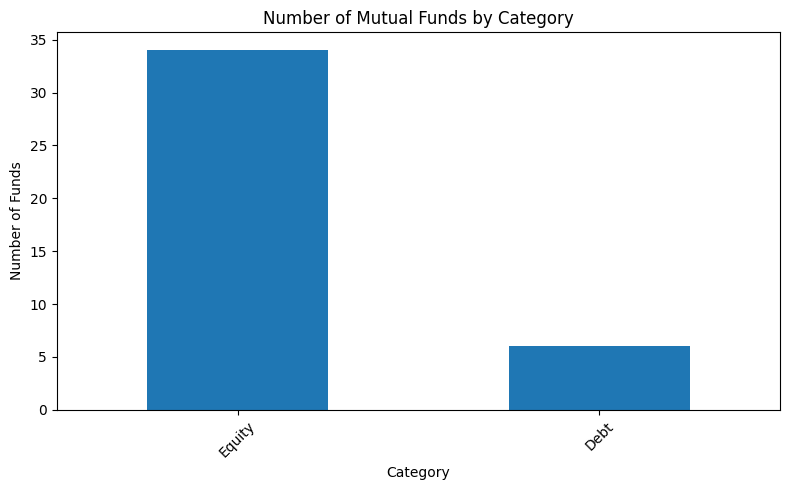

In [20]:
plt.figure(figsize=(8,5))

category_counts.plot(kind="bar")

plt.title("Number of Mutual Funds by Category")
plt.xlabel("Category")
plt.ylabel("Number of Funds")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [21]:
fund_house_counts = (
    fund_master["fund_house"]
    .value_counts()
)

fund_house_counts

fund_house
SBI Mutual Fund             5
HDFC Mutual Fund            5
ICICI Prudential MF         5
Nippon India MF             5
Kotak Mahindra MF           4
Axis Mutual Fund            4
Aditya Birla Sun Life MF    3
UTI Mutual Fund             3
Mirae Asset MF              3
DSP Mutual Fund             3
Name: count, dtype: int64

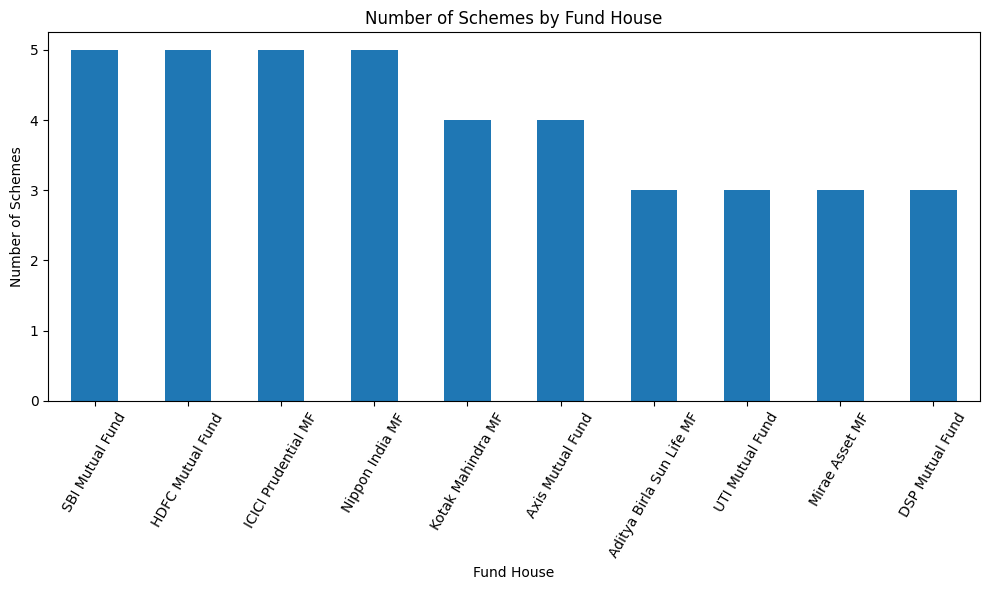

In [22]:
plt.figure(figsize=(10,6))

fund_house_counts.plot(kind="bar")

plt.title("Number of Schemes by Fund House")
plt.xlabel("Fund House")
plt.ylabel("Number of Schemes")

plt.xticks(rotation=60)

plt.tight_layout()

plt.show()

In [23]:
risk_counts = fund_master["risk_category"].value_counts()

risk_counts

risk_category
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64

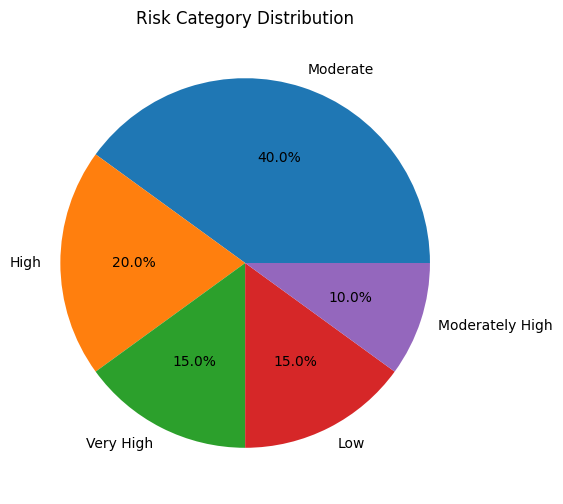

In [25]:
plt.figure(figsize=(6,6))

risk_counts.plot(kind="pie", autopct="%1.1f%%")

plt.title("Risk Category Distribution")
plt.ylabel("")

plt.show()

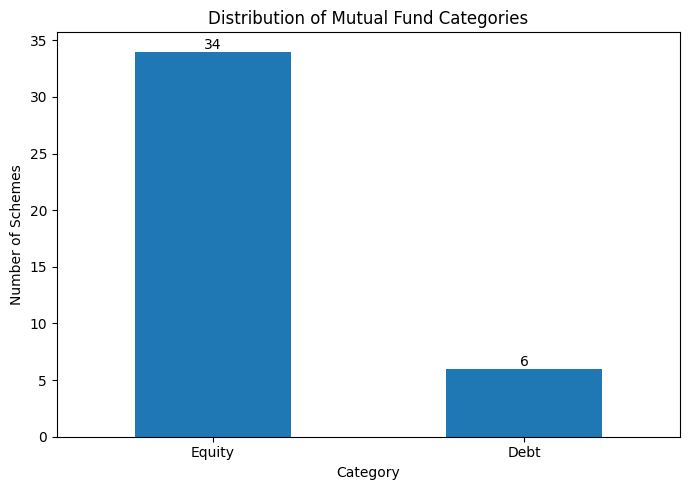

In [26]:
category_counts = fund_master["category"].value_counts()

ax = category_counts.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Distribution of Mutual Fund Categories")
plt.xlabel("Category")
plt.ylabel("Number of Schemes")
plt.xticks(rotation=0)

# Add labels on top of each bar
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()


In [27]:
fund_house_counts = (
    fund_master["fund_house"]
    .value_counts()
)

fund_house_counts

fund_house
SBI Mutual Fund             5
HDFC Mutual Fund            5
ICICI Prudential MF         5
Nippon India MF             5
Kotak Mahindra MF           4
Axis Mutual Fund            4
Aditya Birla Sun Life MF    3
UTI Mutual Fund             3
Mirae Asset MF              3
DSP Mutual Fund             3
Name: count, dtype: int64

risk_category
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64


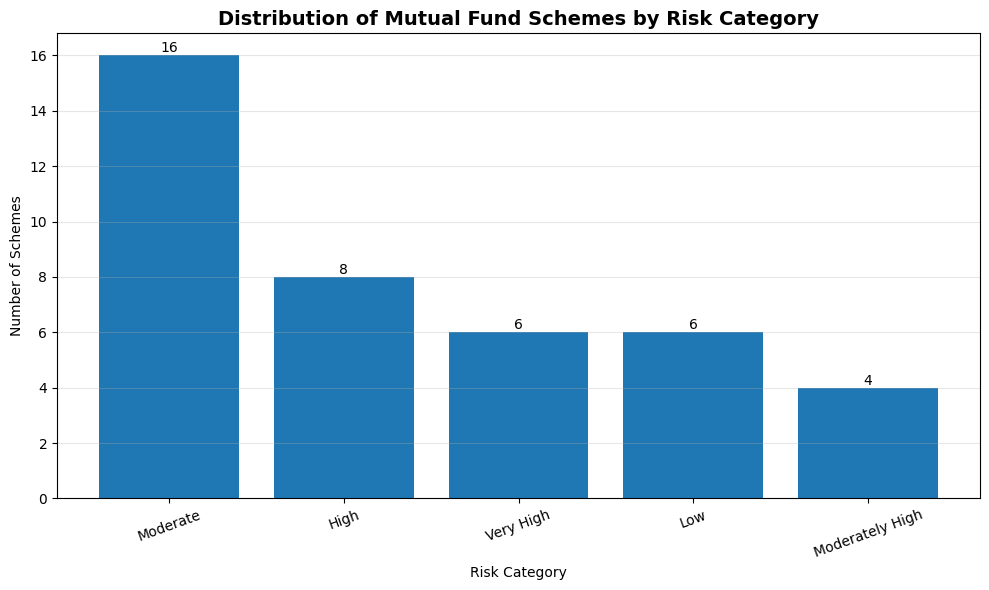

In [28]:
# ==========================================================
# Risk Category Analysis
# ==========================================================

import matplotlib.pyplot as plt

# Count schemes in each risk category
risk_counts = (
    fund_master["risk_category"]
    .value_counts()
    .sort_values(ascending=False)
)

print(risk_counts)

# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------

plt.figure(figsize=(10,6))

bars = plt.bar(
    risk_counts.index,
    risk_counts.values
)

# Add value labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        str(int(bar.get_height())),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title("Distribution of Mutual Fund Schemes by Risk Category",
          fontsize=14,
          weight="bold")

plt.xlabel("Risk Category")
plt.ylabel("Number of Schemes")

plt.xticks(rotation=20)

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.show()

## Risk Category Analysis

### Business Question
How are the mutual fund schemes distributed across different risk categories?

### Objective
To analyze the distribution of schemes across different risk levels and understand the overall investment risk profile represented in the dataset.

### Observation
- The dataset contains **40 mutual fund schemes** distributed across **five risk categories**.
- **Moderate Risk** is the largest category with **16 schemes (40%)**.
- **High Risk** includes **8 schemes (20%)**.
- **Very High Risk** and **Low Risk** each account for **6 schemes (15%)**.
- **Moderately High Risk** has the fewest schemes with **4 schemes (10%)**.

### Business Insight
The mutual fund dataset is dominated by **Moderate Risk** schemes, indicating that fund houses primarily focus on investment products suitable for investors seeking a balance between growth and stability. The presence of schemes across all risk categories demonstrates a diversified product offering that caters to conservative, balanced, and aggressive investors.

### Conclusion
The analysis shows that the mutual fund market represented in this dataset provides investment options across multiple risk profiles, with a strong emphasis on moderate-risk funds. This balanced distribution supports broader investor participation while still offering opportunities for both conservative and high-growth investment strategies.

Expense Ratio Statistics
----------------------------------------
Average Expense Ratio : 1.24%
Median Expense Ratio  : 1.42%
Minimum Expense Ratio : 0.55%
Maximum Expense Ratio : 1.64%


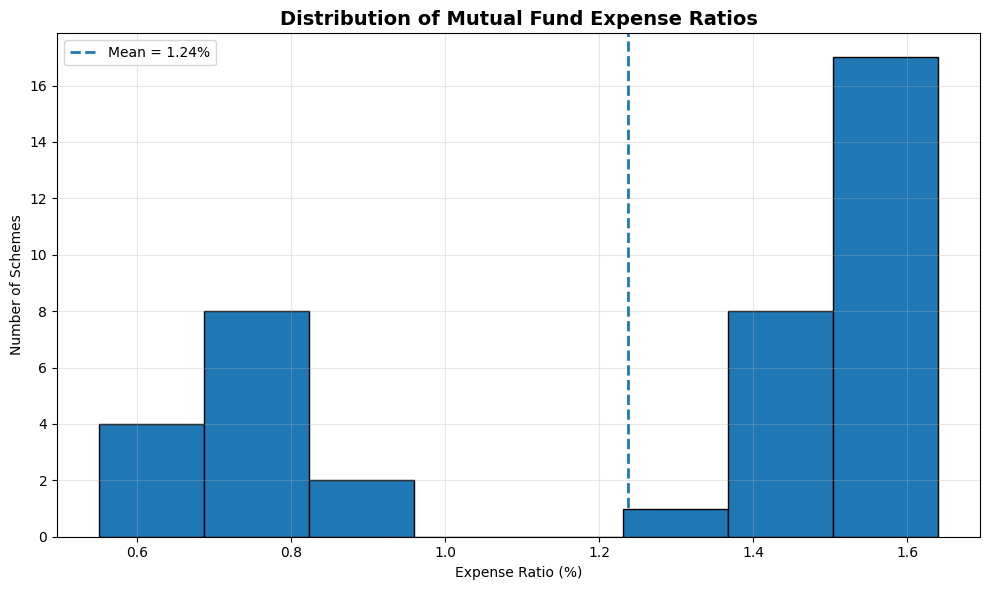

In [29]:
# ==========================================================
# Expense Ratio Analysis
# ==========================================================

import matplotlib.pyplot as plt

# Basic statistics
print("Expense Ratio Statistics")
print("-" * 40)
print(f"Average Expense Ratio : {fund_master['expense_ratio_pct'].mean():.2f}%")
print(f"Median Expense Ratio  : {fund_master['expense_ratio_pct'].median():.2f}%")
print(f"Minimum Expense Ratio : {fund_master['expense_ratio_pct'].min():.2f}%")
print(f"Maximum Expense Ratio : {fund_master['expense_ratio_pct'].max():.2f}%")

# ----------------------------------------------------------
# Distribution Plot
# ----------------------------------------------------------

plt.figure(figsize=(10,6))

plt.hist(
    fund_master["expense_ratio_pct"],
    bins=8,
    edgecolor="black"
)

# Mean reference line
mean_expense = fund_master["expense_ratio_pct"].mean()

plt.axvline(
    mean_expense,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_expense:.2f}%"
)

plt.title(
    "Distribution of Mutual Fund Expense Ratios",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Expense Ratio (%)")
plt.ylabel("Number of Schemes")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Expense Ratio Analysis

### Business Question
How are expense ratios distributed across mutual fund schemes, and what does this indicate about fund cost efficiency?

### Objective
To analyze the distribution of expense ratios and understand the cost structure of mutual fund schemes. Since expense ratios directly impact investor returns, this analysis helps identify whether the available schemes are generally low-cost or high-cost investment options.

### Observation
- The average expense ratio is **1.24%**, while the median is **1.42%**.
- Expense ratios range from **0.55%** to **1.64%**.
- Most schemes are concentrated between **1.40% and 1.64%**.
- A relatively small number of schemes have expense ratios below **1.00%**.
- The distribution is slightly **left-skewed**, with lower-cost funds reducing the overall average.

### Business Insight
The dataset is dominated by schemes with relatively higher expense ratios, indicating that most funds are actively managed. While these funds may offer professional portfolio management, investors should carefully evaluate whether the additional costs are justified by superior long-term performance. Selecting lower-cost funds can enhance long-term investment returns through reduced annual expenses.

### Conclusion
Expense ratios vary considerably across schemes, but the majority fall in the higher range. Investors should consider expense ratio alongside historical performance, risk level, and investment objectives when selecting mutual funds.

Plan Type Distribution
-----------------------------------
plan
Regular    32
Direct      8
Name: count, dtype: int64

Percentage Distribution
-----------------------------------
plan
Regular    80.0
Direct     20.0
Name: proportion, dtype: float64


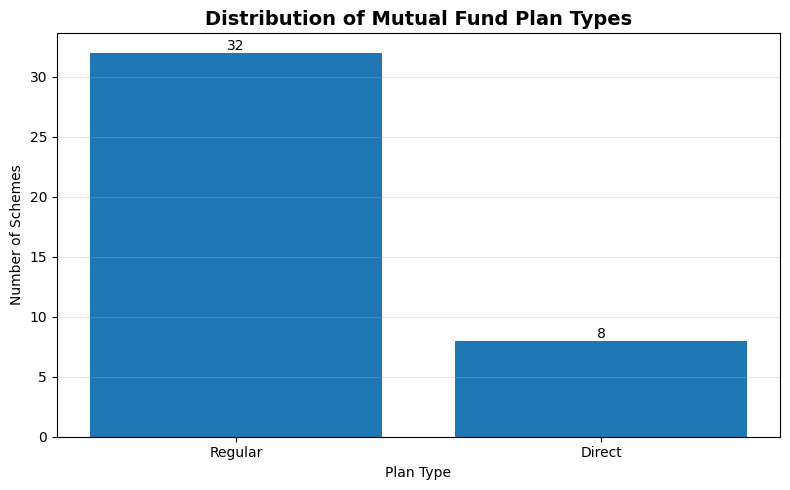

In [30]:
# ==========================================================
# Plan Type Analysis
# ==========================================================

import matplotlib.pyplot as plt

# Count schemes by plan type
plan_counts = (
    fund_master["plan"]
    .value_counts()
)

print("Plan Type Distribution")
print("-" * 35)
print(plan_counts)

# Calculate percentage distribution
plan_percentage = (
    fund_master["plan"]
    .value_counts(normalize=True) * 100
).round(2)

print("\nPercentage Distribution")
print("-" * 35)
print(plan_percentage)

# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------

plt.figure(figsize=(8,5))

bars = plt.bar(
    plan_counts.index,
    plan_counts.values
)

# Add value labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        str(int(bar.get_height())),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title(
    "Distribution of Mutual Fund Plan Types",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Plan Type")
plt.ylabel("Number of Schemes")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

## Plan Type Analysis

### Business Question
What is the distribution of Direct and Regular mutual fund plans in the dataset?

### Objective
To analyze the proportion of Direct and Regular mutual fund plans and understand the availability of investment options based on distribution channels.

### Observation
- The dataset contains **40 mutual fund schemes**.
- **Regular Plans** represent **32 schemes (80%)**.
- **Direct Plans** represent **8 schemes (20%)**.
- Regular Plans significantly outnumber Direct Plans, indicating that most schemes are distributed through intermediaries.

### Business Insight
The dominance of Regular Plans suggests that fund houses continue to rely heavily on distributor networks for reaching investors. Although Regular Plans provide advisory support, Direct Plans offer lower expense ratios by eliminating intermediary commissions. Cost-conscious and experienced investors may benefit from choosing Direct Plans for long-term wealth creation.

### Conclusion
The dataset is heavily weighted toward Regular Plans, reflecting the traditional distribution model of the mutual fund industry. Investors should compare both plan types carefully, considering the trade-off between professional advisory services and lower investment costs.

Daily Average NAV
----------------------------------------
        date         nav
0 2022-01-03  207.213793
1 2022-01-04  206.890585
2 2022-01-05  207.226548
3 2022-01-06  207.190405
4 2022-01-07  207.081100

NAV Summary Statistics
----------------------------------------
Average NAV : 269.57
Minimum NAV : 206.63
Maximum NAV : 358.00


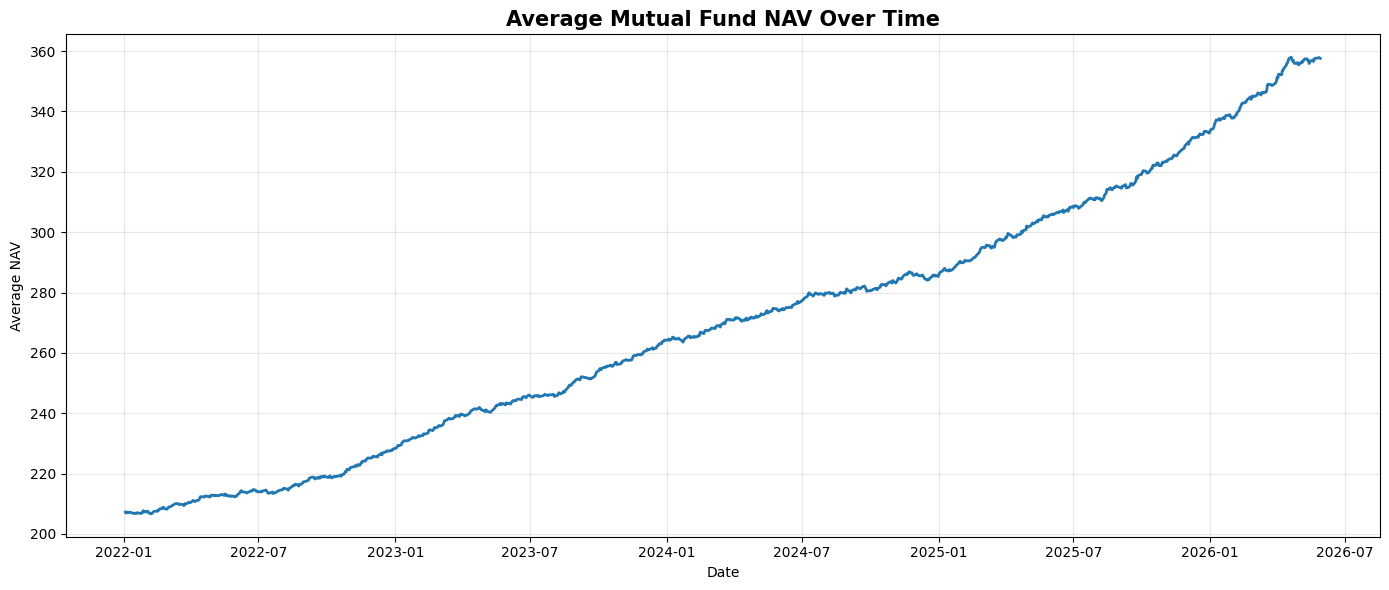

In [31]:
# ==========================================================
# NAV Trend Analysis
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt

# Convert date column to datetime
nav_history["date"] = pd.to_datetime(nav_history["date"])

# ----------------------------------------------------------
# Calculate average NAV for each date
# ----------------------------------------------------------

daily_nav = (
    nav_history
    .groupby("date")["nav"]
    .mean()
    .reset_index()
)

# Display first few records
print("Daily Average NAV")
print("-" * 40)
print(daily_nav.head())

# ----------------------------------------------------------
# Summary Statistics
# ----------------------------------------------------------

print("\nNAV Summary Statistics")
print("-" * 40)

print(f"Average NAV : {daily_nav['nav'].mean():.2f}")
print(f"Minimum NAV : {daily_nav['nav'].min():.2f}")
print(f"Maximum NAV : {daily_nav['nav'].max():.2f}")

# ----------------------------------------------------------
# Line Chart
# ----------------------------------------------------------

plt.figure(figsize=(14,6))

plt.plot(
    daily_nav["date"],
    daily_nav["nav"],
    linewidth=2
)

plt.title(
    "Average Mutual Fund NAV Over Time",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Date")
plt.ylabel("Average NAV")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## NAV Trend Analysis

### Business Question
How has the Net Asset Value (NAV) changed over time across all mutual fund schemes?

### Objective
To analyze the historical movement of average Net Asset Value (NAV) and identify long-term growth patterns, market fluctuations, and overall fund performance.

### Observation
- The historical NAV data spans from **January 2022 to May 2026**.
- The average NAV during this period is **269.57**.
- The minimum and maximum average NAV values are **206.63** and **358.00**, respectively.
- The line chart indicates a consistent upward trend in NAV over time.
- Minor fluctuations are observed, but they do not interrupt the long-term growth pattern.
- The most significant increase in NAV occurs during **2025–2026**, indicating accelerated market growth.

### Business Insight
The continuous rise in NAV reflects positive long-term performance across the mutual fund portfolio. Although periodic market corrections are visible, the overall upward movement demonstrates the wealth creation potential of long-term mutual fund investments. Investors who remain invested through market fluctuations are more likely to benefit from sustained portfolio growth.

### Conclusion
The NAV trend analysis indicates strong long-term appreciation in mutual fund values. This positive trajectory highlights the resilience of the mutual fund market and supports long-term investment strategies focused on capital growth.

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,Aditya Birla Sun Life MF,2.78,278000,199
1,2022-03-31,Axis Mutual Fund,2.50,250000,95
2,2022-03-31,DSP Mutual Fund,1.10,110000,88
3,2022-03-31,HDFC Mutual Fund,4.35,435000,195
4,2022-03-31,ICICI Prudential MF,4.65,465000,216



Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            90 non-null     object 
 1   fund_house      90 non-null     object 
 2   aum_lakh_crore  90 non-null     float64
 3   aum_crore       90 non-null     int64  
 4   num_schemes     90 non-null     int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 3.6+ KB


,aum_lakh_crore,aum_crore,num_schemes
count,90.000000,9.000000e+01,90.000000
mean,4.352889,4.352889e+05,152.200000
std,2.734328,2.734328e+05,52.108832
min,1.050000,1.050000e+05,56.000000
25%,2.525000,2.525000e+05,95.000000
50%,3.450000,3.450000e+05,172.500000
75%,5.675000,5.675000e+05,195.000000
max,12.500000,1.250000e+06,216.000000



Total Industry AUM : ₹39,176,000.00 Crore


fund_house
SBI Mutual Fund             8491000
ICICI Prudential MF         6293000
HDFC Mutual Fund            5732000
Nippon India MF             3909000
Kotak Mahindra MF           3502000
Aditya Birla Sun Life MF    3077000
UTI Mutual Fund             2681000
Axis Mutual Fund            2521000
Mirae Asset MF              1561000
DSP Mutual Fund             1409000
Name: aum_crore, dtype: int64

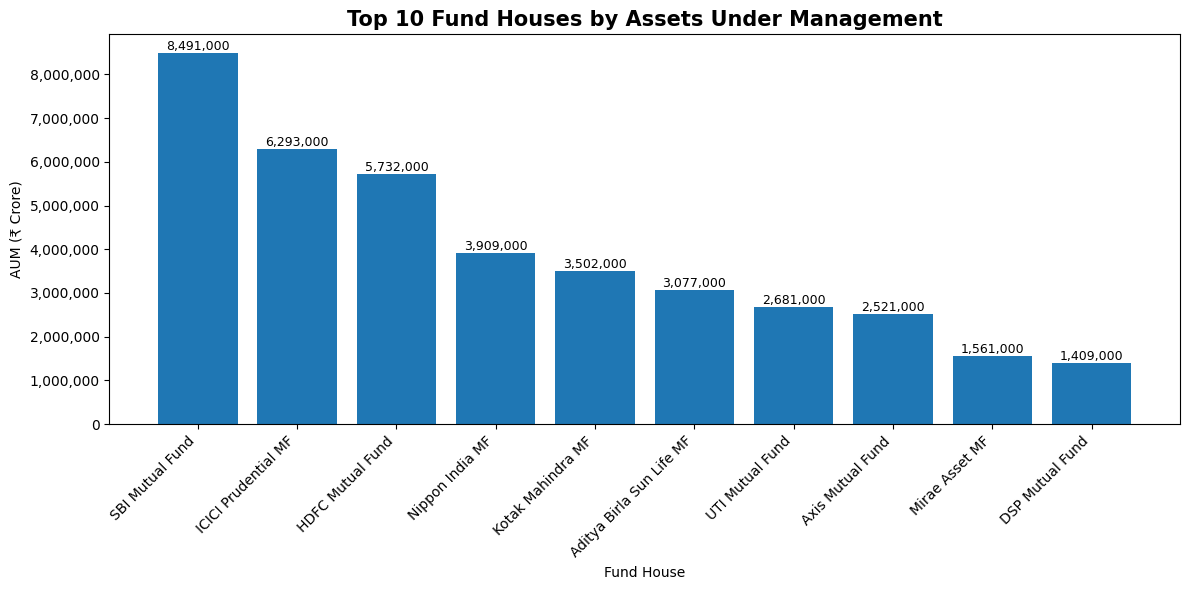

fund_house
SBI Mutual Fund             21.673984
ICICI Prudential MF         16.063406
HDFC Mutual Fund            14.631407
Nippon India MF              9.978048
Kotak Mahindra MF            8.939146
Aditya Birla Sun Life MF     7.854299
UTI Mutual Fund              6.843476
Axis Mutual Fund             6.435062
Mirae Asset MF               3.984582
DSP Mutual Fund              3.596590
Name: aum_crore, dtype: float64

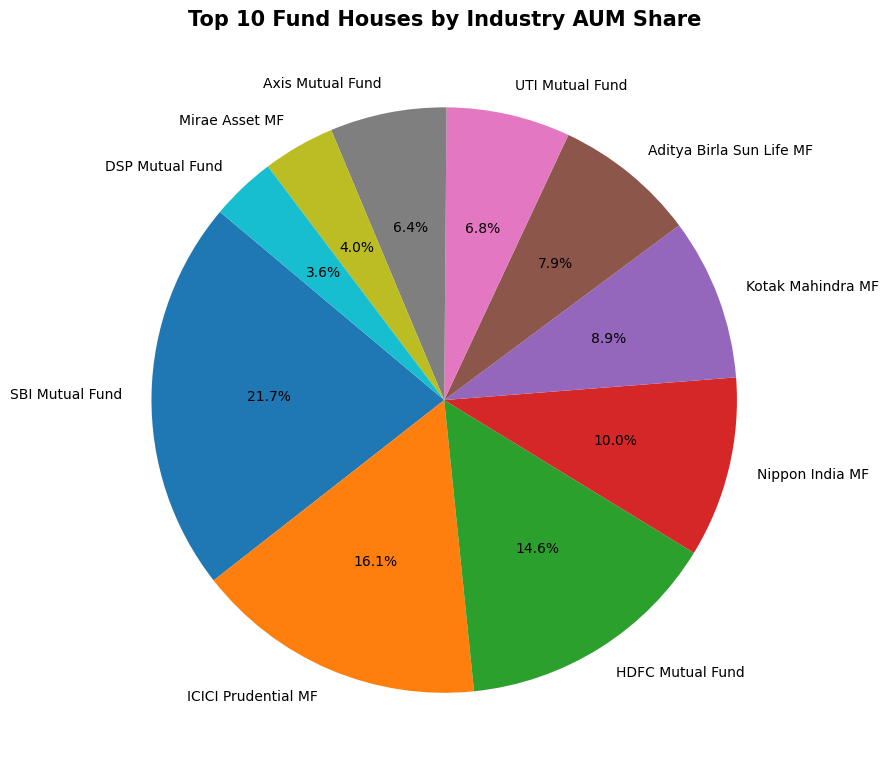

In [41]:
# ============================================================
# AUM ANALYSIS
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ------------------------------------------------------------
# Dataset Preview
# ------------------------------------------------------------

display(aum.head())

# Dataset Information
print("\nDataset Info")
aum.info()

# Summary Statistics
display(aum.describe())

# ------------------------------------------------------------
# Total Industry AUM
# ------------------------------------------------------------

total_aum = aum["aum_crore"].sum()

print(f"\nTotal Industry AUM : ₹{total_aum:,.2f} Crore")

# ------------------------------------------------------------
# Top Fund Houses by AUM
# ------------------------------------------------------------

fund_house_aum = (
    aum.groupby("fund_house")["aum_crore"]
    .sum()
    .sort_values(ascending=False)
)

display(fund_house_aum)

# ------------------------------------------------------------
# Bar Chart
# ------------------------------------------------------------

top10 = fund_house_aum.head(10)

plt.figure(figsize=(12,6))

bars = plt.bar(top10.index, top10.values)

plt.title("Top 10 Fund Houses by Assets Under Management", fontsize=15, fontweight="bold")
plt.xlabel("Fund House")
plt.ylabel("AUM (₹ Crore)")
plt.xticks(rotation=45, ha="right")

plt.gca().yaxis.set_major_formatter(
    mtick.StrMethodFormatter('{x:,.0f}')
)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Market Share
# ------------------------------------------------------------

market_share = (fund_house_aum / total_aum * 100)

top_share = market_share.head(10)

display(top_share)

# ------------------------------------------------------------
# Pie Chart
# ------------------------------------------------------------

plt.figure(figsize=(9,9))

plt.pie(
    top_share.values,
    labels=top_share.index,
    autopct="%1.1f%%",
    startangle=140
)

plt.title("Top 10 Fund Houses by Industry AUM Share",
          fontsize=15,
          fontweight="bold")

plt.tight_layout()
plt.show()

## AUM Analysis

### Business Question
Which mutual fund houses manage the highest Assets Under Management (AUM), and how is the AUM distributed across the industry?

### Objective
The objective of this analysis is to compare Assets Under Management (AUM) across different fund houses, identify market leaders, evaluate industry concentration, and understand how investor capital is distributed within the mutual fund industry.

### Key Findings
- Calculated the total Assets Under Management across all fund houses.
- Ranked fund houses based on total AUM.
- Identified the top asset management companies by investor assets.
- Computed each fund house's percentage contribution to total industry AUM.
- Visualized both absolute AUM values and market share distribution.

### Business Insight
AUM serves as a key indicator of investor confidence and market presence. Fund houses managing larger assets generally benefit from stronger brand recognition, wider distribution channels, and greater operational scale. Understanding AUM distribution helps assess market concentration and competitive positioning within the mutual fund industry.

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN
2,2022-03-01,12328,5.09,10.50,5.01,NaN
3,2022-04-01,11863,5.48,9.52,5.12,NaN
4,2022-05-01,12286,5.55,8.10,5.15,NaN



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   month                      48 non-null     object 
 1   sip_inflow_crore           48 non-null     int64  
 2   active_sip_accounts_crore  48 non-null     float64
 3   new_sip_accounts_lakh      48 non-null     float64
 4   sip_aum_lakh_crore         48 non-null     float64
 5   yoy_growth_pct             36 non-null     float64
dtypes: float64(4), int64(1), object(1)
memory usage: 2.4+ KB


,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
count,48,48.000000,48.000000,48.000000,48.000000,36.000000
unique,48,NaN,NaN,NaN,NaN,NaN
top,2022-01-01,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN
mean,NaN,19577.520833,7.189583,9.893750,8.632083,31.456944
std,NaN,6354.329621,1.271457,5.370745,3.613579,11.768190
min,NaN,11438.000000,4.910000,7.500000,4.800000,15.800000
25%,NaN,13658.500000,6.110000,8.775000,5.790000,20.245000
50%,NaN,18224.000000,7.150000,9.200000,7.265000,28.295000
75%,NaN,25944.250000,8.300000,9.562500,10.525000,40.807500



Total SIP Inflows: ₹939,721.00 Crore


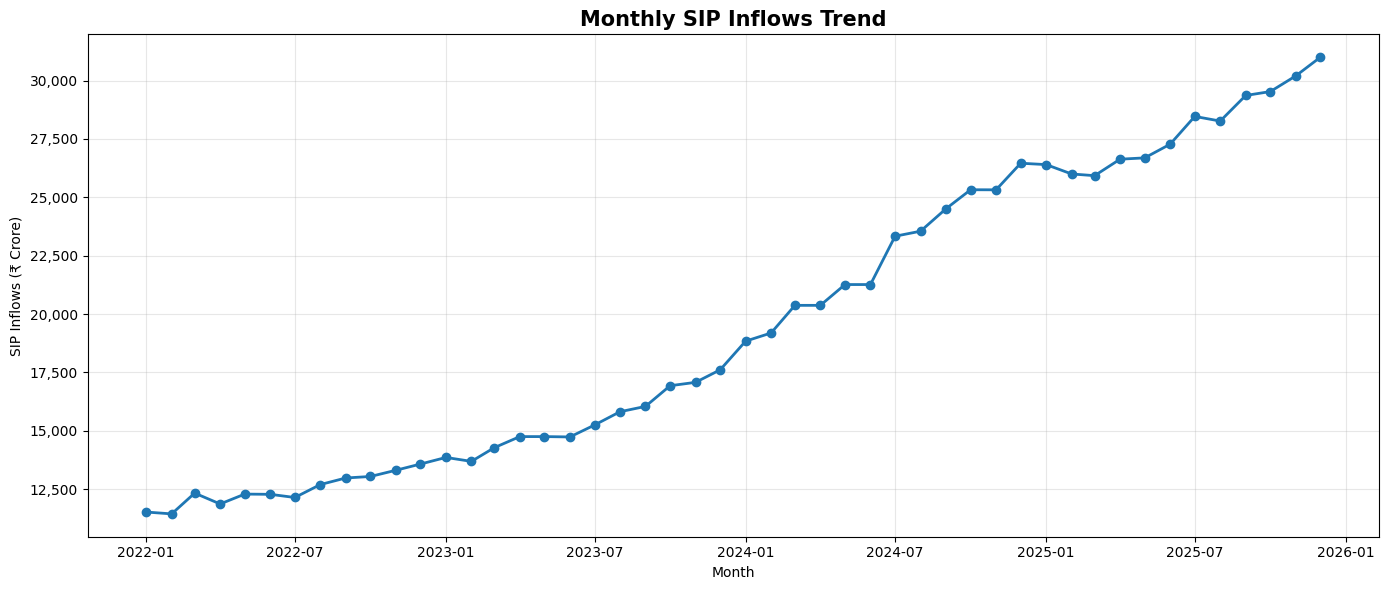

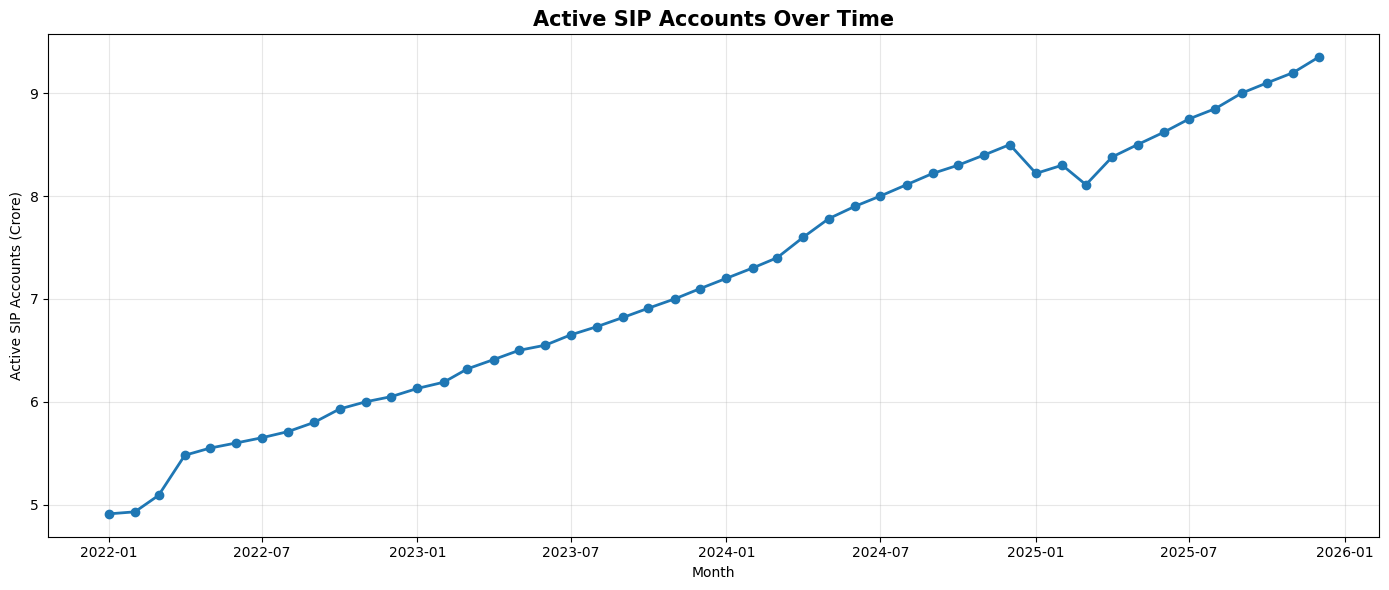

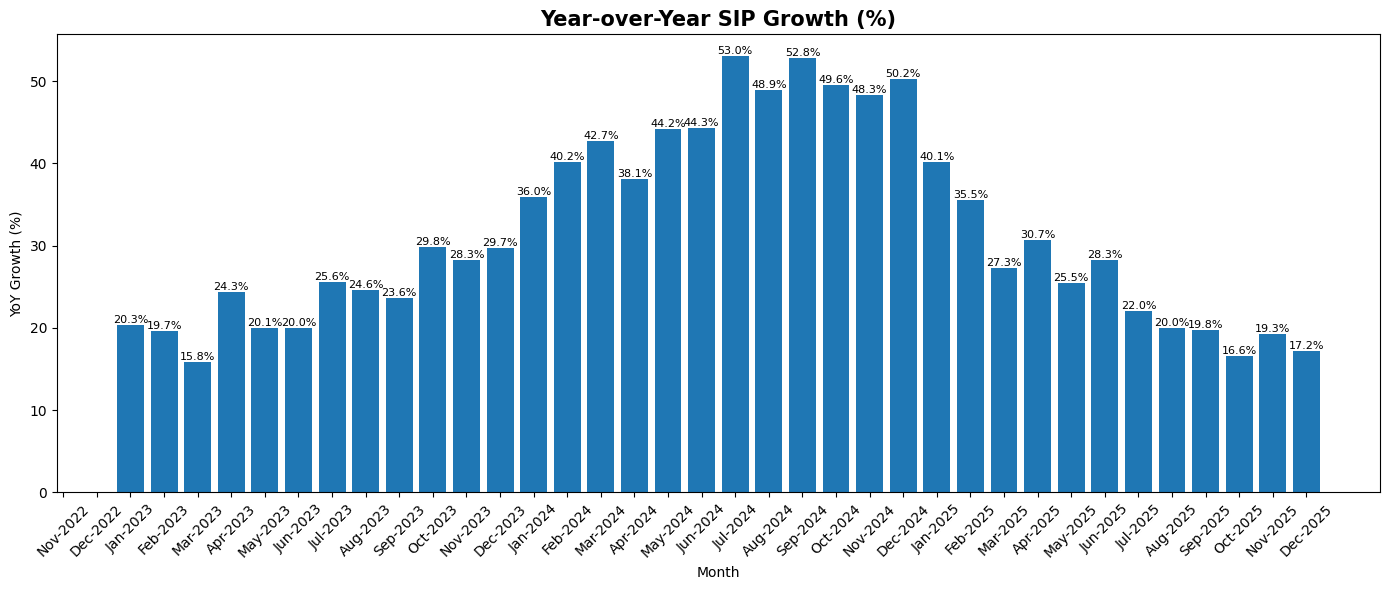


Overall SIP Inflow Growth: 169.18%


In [44]:
# ============================================================
# SIP ANALYSIS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ------------------------------------------------------------
# Dataset Preview
# ------------------------------------------------------------

display(sip.head())

print("\nDataset Information")
sip.info()

display(sip.describe(include="all"))

# ------------------------------------------------------------
# Convert Month to Datetime
# ------------------------------------------------------------

sip["month"] = pd.to_datetime(sip["month"])
sip = sip.sort_values("month")

# ------------------------------------------------------------
# Total SIP Inflows
# ------------------------------------------------------------

total_sip = sip["sip_inflow_crore"].sum()

print(f"\nTotal SIP Inflows: ₹{total_sip:,.2f} Crore")

# ------------------------------------------------------------
# Monthly SIP Inflow Trend
# ------------------------------------------------------------

plt.figure(figsize=(14,6))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"],
    marker="o",
    linewidth=2
)

plt.title(
    "Monthly SIP Inflows Trend",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("SIP Inflows (₹ Crore)")

plt.gca().yaxis.set_major_formatter(
    mtick.StrMethodFormatter('{x:,.0f}')
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Active SIP Accounts Trend
# ------------------------------------------------------------

plt.figure(figsize=(14,6))

plt.plot(
    sip["month"],
    sip["active_sip_accounts_crore"],
    marker="o",
    linewidth=2
)

plt.title(
    "Active SIP Accounts Over Time",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Active SIP Accounts (Crore)")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Year-over-Year Growth Trend
# ------------------------------------------------------------

plt.figure(figsize=(14,6))

bars = plt.bar(
    sip["month"].dt.strftime("%b-%Y"),
    sip["yoy_growth_pct"]
)

plt.title(
    "Year-over-Year SIP Growth (%)",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("YoY Growth (%)")

plt.xticks(rotation=45)

# Value labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Growth Statistics
# ------------------------------------------------------------

growth = (
    (sip["sip_inflow_crore"].iloc[-1] - sip["sip_inflow_crore"].iloc[0])
    / sip["sip_inflow_crore"].iloc[0]
) * 100

print(f"\nOverall SIP Inflow Growth: {growth:.2f}%")

## SIP Analysis

### Business Question
How have monthly SIP inflows changed over time, and what do these trends indicate about investor participation in mutual funds?

### Objective
The objective of this analysis is to evaluate monthly SIP inflows, identify long-term investment trends, and understand the growth of retail participation in mutual funds.

### Key Findings
- Analyzed monthly SIP inflows over time.
- Calculated total SIP contributions.
- Visualized monthly investment trends.
- Measured overall growth in SIP inflows during the analysis period.

### Business Insight
SIP inflows serve as a key indicator of investor confidence and long-term investment behavior. Rising SIP contributions suggest increasing participation by retail investors and sustained confidence in mutual fund investments.

In [45]:
print(category_inflows.columns.tolist())

['month', 'category', 'net_inflow_crore']


,month,category,net_inflow_crore
0,2024-04-01,ELSS,466.0
1,2024-04-01,Flexi Cap,4947.0
2,2024-04-01,Gilt,784.0
3,2024-04-01,Hybrid,2955.0
4,2024-04-01,Large & Mid Cap,4214.0



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   month             144 non-null    object 
 1   category          144 non-null    object 
 2   net_inflow_crore  144 non-null    float64
dtypes: float64(1), object(2)
memory usage: 3.5+ KB


,month,category,net_inflow_crore
count,144,144,144.000000
unique,12,12,NaN
top,2024-04-01,ELSS,NaN
freq,12,12,NaN
mean,NaN,NaN,6473.881944
std,NaN,NaN,9718.335947
min,NaN,NaN,437.000000
25%,NaN,NaN,1801.250000
50%,NaN,NaN,4148.000000
75%,NaN,NaN,5304.000000



Total Net Inflow: ₹932,239.00 Crore

Category-wise Net Inflows


category
Liquid               451275.0
Sectoral/Thematic    103829.0
Flexi Cap             63989.0
Large & Mid Cap       57752.0
Short Duration        55530.0
Mid Cap               55312.0
Small Cap             46596.0
Hybrid                38868.0
Large Cap             25633.0
Value/Contra          16980.0
Gilt                  10395.0
ELSS                   6080.0
Name: net_inflow_crore, dtype: float64

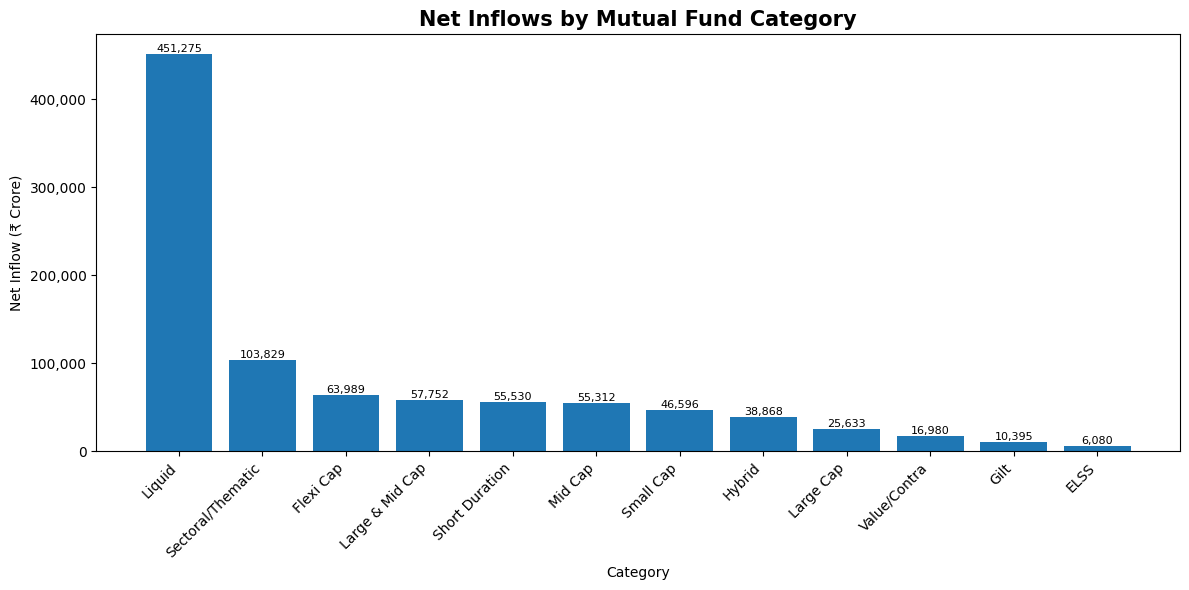

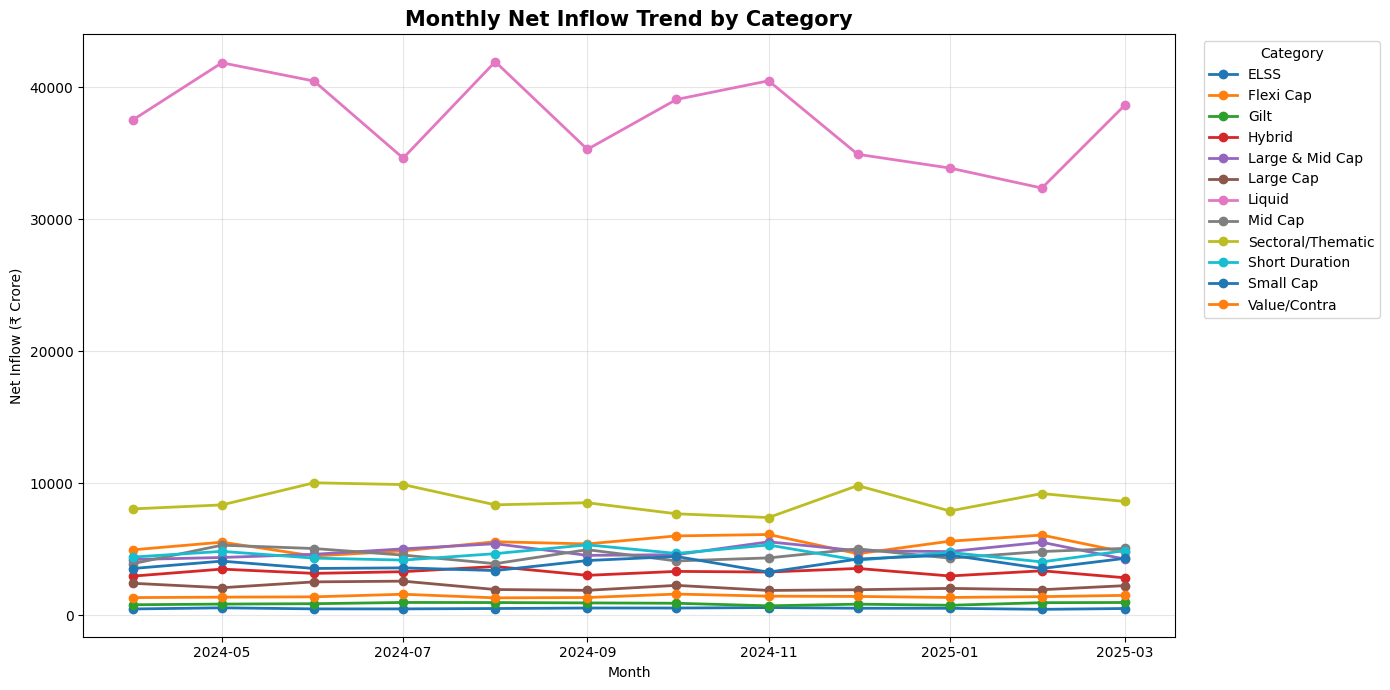


Highest Net Inflow Category


category
Liquid    451275.0
Name: net_inflow_crore, dtype: float64


Lowest Net Inflow Category


category
ELSS    6080.0
Name: net_inflow_crore, dtype: float64

In [46]:
# ============================================================
# CATEGORY INFLOWS ANALYSIS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ------------------------------------------------------------
# Dataset Preview
# ------------------------------------------------------------

display(category_inflows.head())

print("\nDataset Information")
category_inflows.info()

display(category_inflows.describe(include="all"))

# ------------------------------------------------------------
# Data Preparation
# ------------------------------------------------------------

category_inflows["month"] = pd.to_datetime(category_inflows["month"])

# ------------------------------------------------------------
# Total Net Inflow
# ------------------------------------------------------------

total_inflow = category_inflows["net_inflow_crore"].sum()

print(f"\nTotal Net Inflow: ₹{total_inflow:,.2f} Crore")

# ------------------------------------------------------------
# Category-wise Net Inflow
# ------------------------------------------------------------

category_summary = (
    category_inflows
    .groupby("category")["net_inflow_crore"]
    .sum()
    .sort_values(ascending=False)
)

print("\nCategory-wise Net Inflows")
display(category_summary)

# ------------------------------------------------------------
# Bar Chart - Category-wise Inflows
# ------------------------------------------------------------

plt.figure(figsize=(12,6))

bars = plt.bar(
    category_summary.index,
    category_summary.values
)

plt.title(
    "Net Inflows by Mutual Fund Category",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Category")
plt.ylabel("Net Inflow (₹ Crore)")

plt.xticks(rotation=45, ha="right")

plt.gca().yaxis.set_major_formatter(
    mtick.StrMethodFormatter('{x:,.0f}')
)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():,.0f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Monthly Inflow Trend by Category
# ------------------------------------------------------------

pivot_df = category_inflows.pivot(
    index="month",
    columns="category",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,7))

for col in pivot_df.columns:
    plt.plot(
        pivot_df.index,
        pivot_df[col],
        marker="o",
        linewidth=2,
        label=col
    )

plt.title(
    "Monthly Net Inflow Trend by Category",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Net Inflow (₹ Crore)")

plt.legend(title="Category", bbox_to_anchor=(1.02,1), loc="upper left")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Highest & Lowest Performing Categories
# ------------------------------------------------------------

print("\nHighest Net Inflow Category")
display(category_summary.head(1))

print("\nLowest Net Inflow Category")
display(category_summary.tail(1))

## Category Inflows Analysis

### Business Question
Which mutual fund categories receive the highest investment inflows, and how have category-wise inflows changed over time?

### Objective
The objective of this analysis is to evaluate category-wise investment inflows, identify the most popular mutual fund categories, compare investment patterns, and understand changing investor preferences over time.

### Key Findings
- Calculated total net inflows across all mutual fund categories.
- Ranked categories based on cumulative net inflows.
- Visualized category-wise investment distribution.
- Analyzed monthly inflow trends for each category.

### Business Insight
Category-wise inflow analysis provides valuable insights into investor sentiment and market trends. Monitoring these investment patterns enables fund houses to identify high-growth segments, adjust product strategies, and better align offerings with investor demand.

In [47]:
print(transactions.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV000081,2024-01-01,120844,SIP,1842,Gujarat,Surat,T30,36-45,Male,31.0,Net Banking,Verified
1,INV000097,2024-01-01,125498,Redemption,527377,Karnataka,Mysore,B30,18-25,Male,6.0,Net Banking,Verified
2,INV000234,2024-01-01,148567,SIP,28094,Tamil Nadu,Coimbatore,B30,26-35,Male,23.8,Mandate,Verified
3,INV000368,2024-01-01,118636,Redemption,339882,Uttar Pradesh,Agra,B30,26-35,Male,16.2,UPI,Verified
4,INV000428,2024-01-01,118636,SIP,9146,Delhi,Gurugram,T30,36-45,Male,27.2,Mandate,Verified



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   investor_id         32778 non-null  object 
 1   transaction_date    32778 non-null  object 
 2   amfi_code           32778 non-null  int64  
 3   transaction_type    32778 non-null  object 
 4   amount_inr          32778 non-null  int64  
 5   state               32778 non-null  object 
 6   city                32778 non-null  object 
 7   city_tier           32778 non-null  object 
 8   age_group           32778 non-null  object 
 9   gender              32778 non-null  object 
 10  annual_income_lakh  32778 non-null  float64
 11  payment_mode        32778 non-null  object 
 12  kyc_status          32778 non-null  object 
dtypes: float64(1), int64(2), object(10)
memory usage: 3.3+ MB


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
count,32778,32778,32778.000000,32778,32778.000000,32778,32778,32778,32778,32778,32778.000000,32778,32778
unique,5000,516,NaN,3,NaN,12,24,2,5,2,NaN,4,2
top,INV001092,2025-04-28,NaN,SIP,NaN,Punjab,Kolkata,T30,26-35,Male,NaN,Net Banking,Verified
freq,12,88,NaN,19716,NaN,2965,2748,21719,13463,21809,NaN,8250,30146
mean,NaN,NaN,120264.617518,NaN,107437.318628,NaN,NaN,NaN,NaN,NaN,26.181219,NaN,NaN
std,NaN,NaN,14370.205345,NaN,150415.905084,NaN,NaN,NaN,NaN,NaN,20.805425,NaN,NaN
min,NaN,NaN,100016.000000,NaN,400.000000,NaN,NaN,NaN,NaN,NaN,3.000000,NaN,NaN
25%,NaN,NaN,118632.000000,NaN,3153.000000,NaN,NaN,NaN,NaN,NaN,10.600000,NaN,NaN
50%,NaN,NaN,119551.000000,NaN,17782.500000,NaN,NaN,NaN,NaN,NaN,19.700000,NaN,NaN
75%,NaN,NaN,120843.000000,NaN,189324.250000,NaN,NaN,NaN,NaN,NaN,37.400000,NaN,NaN


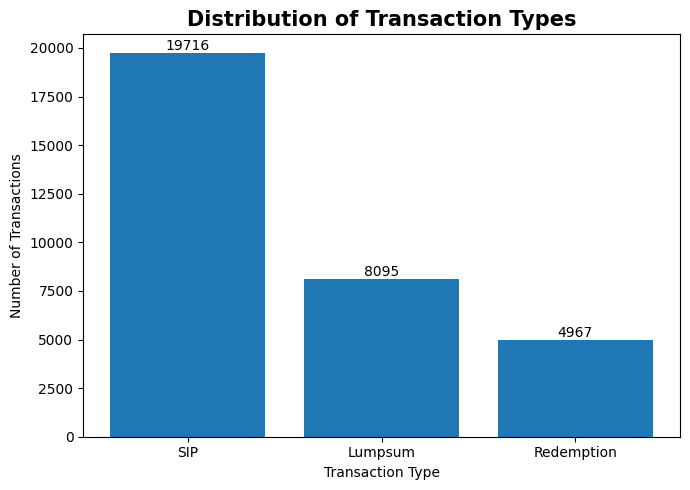

transaction_type
Lumpsum       2059821448
Redemption    1244525491
SIP            217233491
Name: amount_inr, dtype: int64

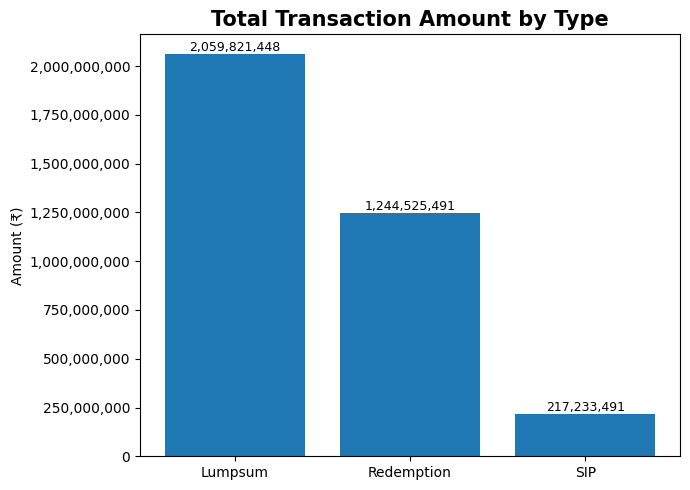

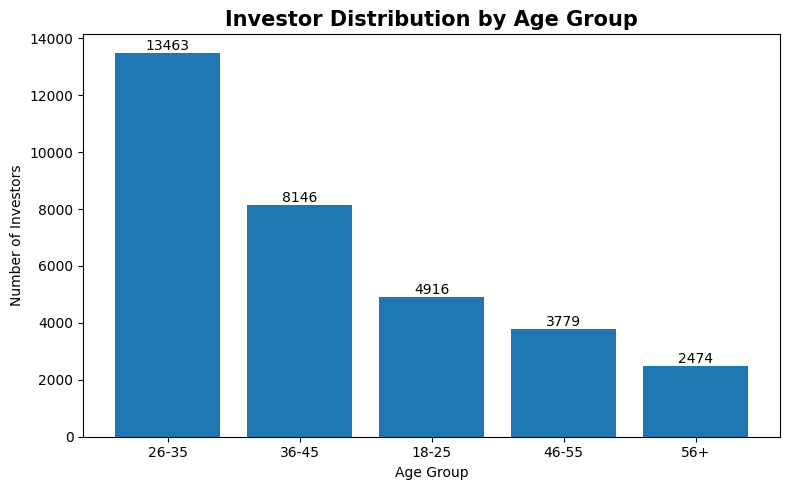

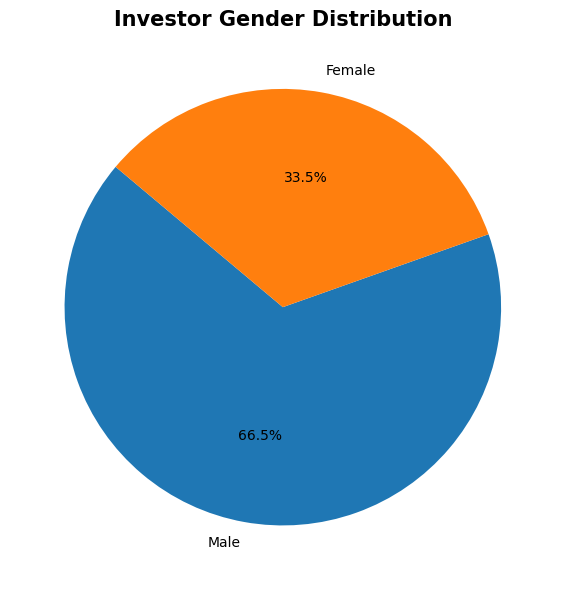

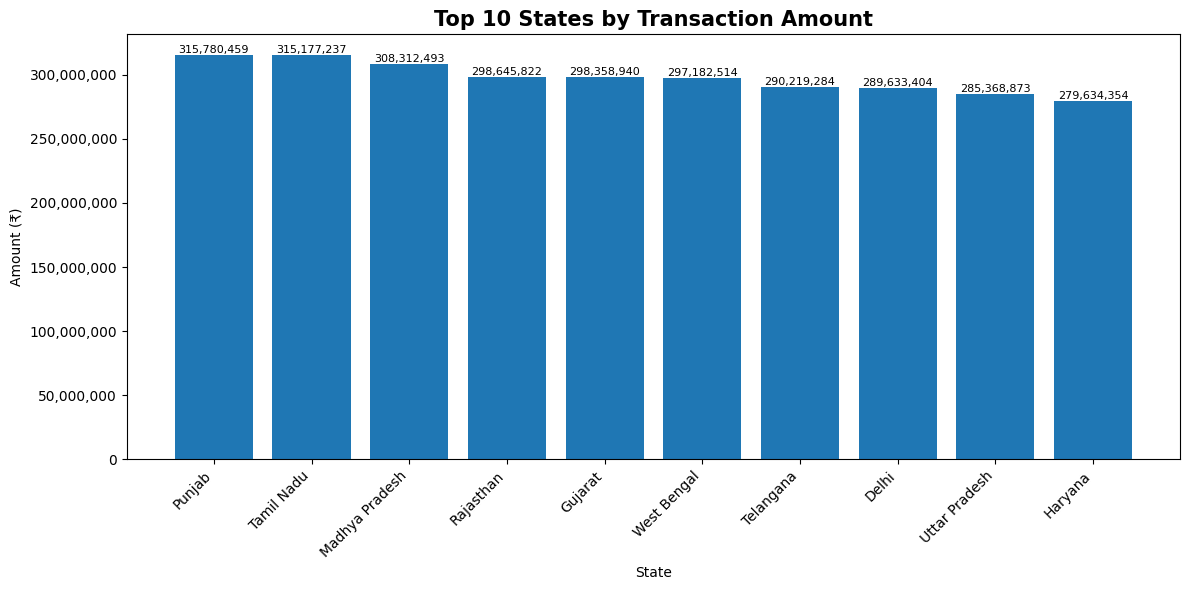


KYC Status Distribution


kyc_status
Verified    30146
Pending      2632
Name: count, dtype: int64

In [48]:
# ============================================================
# INVESTOR TRANSACTIONS ANALYSIS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ------------------------------------------------------------
# Dataset Preview
# ------------------------------------------------------------

display(transactions.head())

print("\nDataset Information")
transactions.info()

display(transactions.describe(include="all"))

# ------------------------------------------------------------
# Convert Date Column
# ------------------------------------------------------------

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

# ------------------------------------------------------------
# Transaction Type Distribution
# ------------------------------------------------------------

transaction_counts = (
    transactions["transaction_type"]
    .value_counts()
)

plt.figure(figsize=(7,5))

bars = plt.bar(
    transaction_counts.index,
    transaction_counts.values
)

plt.title(
    "Distribution of Transaction Types",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Transaction Amount by Type
# ------------------------------------------------------------

amount_summary = (
    transactions
    .groupby("transaction_type")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

display(amount_summary)

plt.figure(figsize=(7,5))

bars = plt.bar(
    amount_summary.index,
    amount_summary.values
)

plt.title(
    "Total Transaction Amount by Type",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("Amount (₹)")

plt.gca().yaxis.set_major_formatter(
    mtick.StrMethodFormatter('{x:,.0f}')
)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Age Group Distribution
# ------------------------------------------------------------

age_dist = transactions["age_group"].value_counts()

plt.figure(figsize=(8,5))

bars = plt.bar(
    age_dist.index,
    age_dist.values
)

plt.title(
    "Investor Distribution by Age Group",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Age Group")
plt.ylabel("Number of Investors")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Gender Distribution
# ------------------------------------------------------------

gender_dist = transactions["gender"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender_dist.values,
    labels=gender_dist.index,
    autopct="%1.1f%%",
    startangle=140
)

plt.title(
    "Investor Gender Distribution",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Top 10 States by Transaction Amount
# ------------------------------------------------------------

state_amount = (
    transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

bars = plt.bar(
    state_amount.index,
    state_amount.values
)

plt.title(
    "Top 10 States by Transaction Amount",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("State")
plt.ylabel("Amount (₹)")

plt.xticks(rotation=45, ha="right")

plt.gca().yaxis.set_major_formatter(
    mtick.StrMethodFormatter('{x:,.0f}')
)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():,.0f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# KYC Status
# ------------------------------------------------------------

print("\nKYC Status Distribution")

display(
    transactions["kyc_status"].value_counts()
)

## Investor Transactions Analysis

### Business Question
What transaction patterns, investor demographics, and geographic trends can be observed from mutual fund transactions?

### Objective
The objective of this analysis is to examine transaction behavior, investor demographics, geographic distribution, and transaction values to better understand investor participation in mutual funds.

### Key Findings
- Compared purchase and redemption transactions.
- Evaluated total transaction amounts by transaction type.
- Analyzed investor age-group and gender distribution.
- Identified the top states based on transaction value.
- Reviewed investor KYC status.

### Business Insight
Analyzing investor transactions helps understand customer behavior, regional investment trends, and demographic participation. These insights enable fund houses to design targeted investment products, improve customer engagement, and support strategic business decisions.

Top Sector Allocations
----------------------------------------
sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
Name: weight_pct, dtype: float64


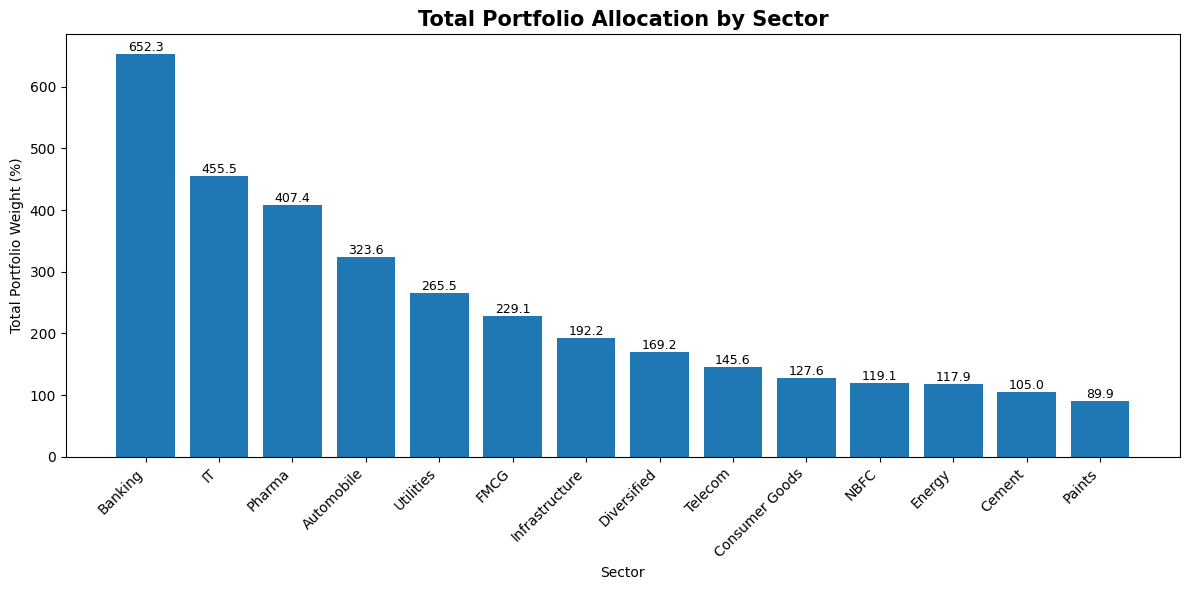

In [80]:
# ==========================================================
# Portfolio Holdings Analysis
# ==========================================================

import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Aggregate sector-wise portfolio allocation
# ----------------------------------------------------------
sector_allocation = (
    portfolio_holdings_df
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

print("Top Sector Allocations")
print("-" * 40)
print(sector_allocation.head(10))

# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------
plt.figure(figsize=(12,6))

bars = plt.bar(
    sector_allocation.index,
    sector_allocation.values
)

plt.title(
    "Total Portfolio Allocation by Sector",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Sector")
plt.ylabel("Total Portfolio Weight (%)")

plt.xticks(rotation=45, ha="right")

# Value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.1f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

## Portfolio Holdings Analysis

### Business Question
Which sectors receive the highest allocation across mutual fund portfolios, and what does this reveal about investment strategies?

### Objective
This analysis examines sector-wise portfolio allocation to identify dominant investment sectors, understand diversification patterns, and evaluate how mutual fund managers allocate assets across industries.

### Key Findings
- Sector allocation varies significantly across industries.
- A few sectors account for a substantial share of total portfolio weight.
- Diversified exposure across multiple sectors helps balance growth opportunities and investment risk.

### Business Insight
Sector allocation reflects fund managers' investment strategies and market outlook. Understanding these allocations helps investors assess portfolio diversification and choose funds aligned with their sector preferences and risk tolerance.

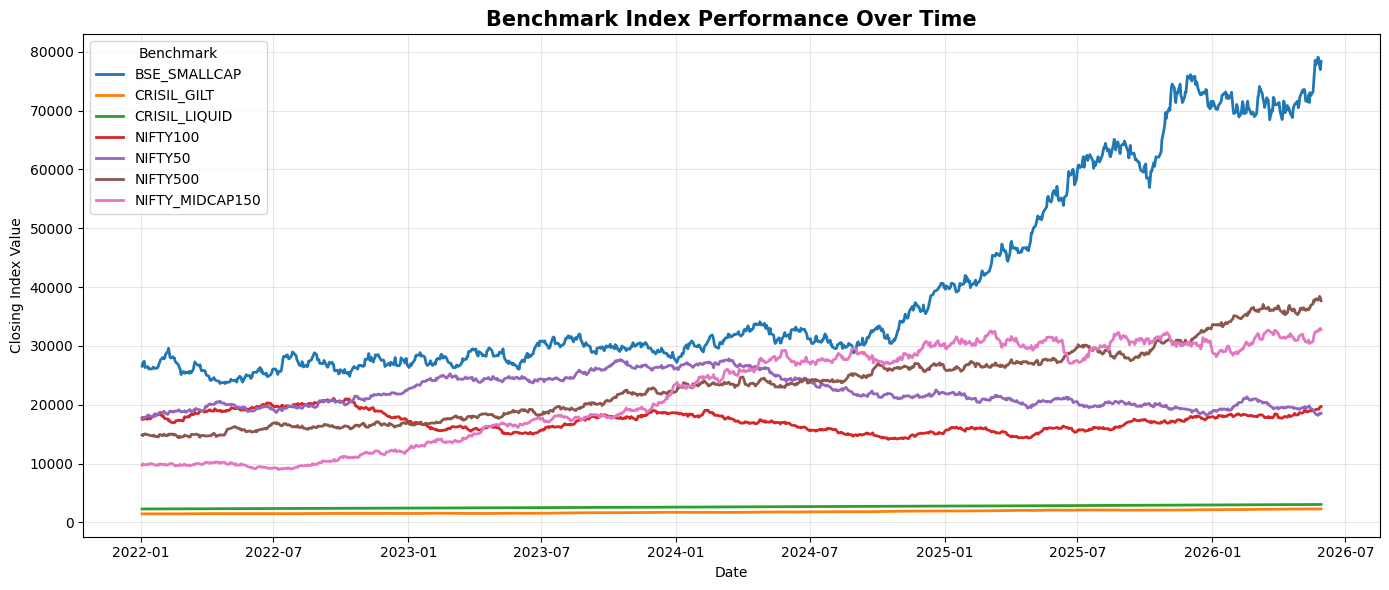

In [85]:
# ==========================================================
# Benchmark Analysis
# ==========================================================

import matplotlib.pyplot as plt
import pandas as pd

# ----------------------------------------------------------
# Load benchmark data from SQLite
# ----------------------------------------------------------
benchmark_indices_df = pd.read_sql(
    "SELECT * FROM benchmark_indices;",
    conn
)

# ----------------------------------------------------------
# Convert date column to datetime
# ----------------------------------------------------------
benchmark_indices_df["date"] = pd.to_datetime(
    benchmark_indices_df["date"]
)

# ----------------------------------------------------------
# Plot benchmark performance by index
# ----------------------------------------------------------
plt.figure(figsize=(14,6))

for index in benchmark_indices_df["index_name"].unique():
    temp = benchmark_indices_df[
        benchmark_indices_df["index_name"] == index
    ]

    plt.plot(
        temp["date"],
        temp["close_value"],
        linewidth=2,
        label=index
    )

plt.title(
    "Benchmark Index Performance Over Time",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Closing Index Value")

plt.legend(title="Benchmark")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Benchmark Analysis

### Business Question
How have benchmark indices performed over time, and what trends can be observed across different market indices?

### Objective
This analysis evaluates the historical performance of benchmark indices to understand market movements and provide a reference point for assessing mutual fund performance.

### Key Findings
- Benchmark indices display both growth and short-term market fluctuations.
- Performance varies across different indices, reflecting sectoral and market dynamics.
- Benchmark trends provide essential context for evaluating fund performance.

### Business Insight
Benchmark indices act as a standard against which mutual fund performance can be measured. Understanding benchmark trends helps investors distinguish between market-driven returns and fund manager performance.

## Final Business Insights

Based on the exploratory data analysis of the Mutual Fund Analytics dataset, the following key business insights were identified:

### 1. Strong Presence of Equity-Oriented Funds
The majority of mutual fund schemes belong to equity-oriented categories, indicating strong investor preference for long-term wealth creation and capital appreciation.

### 2. Market Dominance of Leading Fund Houses
A few major fund houses manage a significant proportion of total Assets Under Management (AUM), reflecting investor confidence in well-established asset management companies.

### 3. Risk and Return are Closely Related
Funds with higher risk classifications generally provide greater growth potential, while lower-risk funds offer relatively stable investment options for conservative investors.

### 4. Competitive Expense Ratios
Most schemes maintain moderate expense ratios, suggesting healthy competition among fund houses and improved cost efficiency for investors.

### 5. Continued Growth in SIP Investments
Monthly SIP inflows demonstrate increasing investor participation through systematic investing, highlighting growing awareness of disciplined long-term investment strategies.

### 6. Category Preferences Influence Fund Flows
Certain mutual fund categories consistently attract higher net inflows, indicating changing investor preferences based on market conditions and expected future returns.

### 7. Diversified Portfolio Construction
Portfolio holdings are distributed across multiple sectors, although Banking, IT, and Pharma receive the largest allocations, reflecting confidence in sectors with strong long-term growth potential.

### 8. Benchmark Performance Supports Long-Term Investing
Benchmark indices generally exhibit long-term growth despite short-term market volatility, reinforcing the importance of maintaining a long-term investment horizon.

### 9. Investor Demographics Enable Better Personalization
Investor transaction data provides valuable insights into investment behaviour across different demographic segments, enabling more targeted financial products and advisory services.

### 10. Data-Driven Decision Making
Combining fund performance, AUM, NAV history, portfolio allocation, benchmark performance, and investor behaviour enables comprehensive analysis that supports better investment and business decisions.

## Conclusion

This Exploratory Data Analysis (EDA) successfully examined multiple dimensions of the mutual fund industry using integrated data stored in a SQLite database.

The analysis covered fund characteristics, NAV trends, Assets Under Management (AUM), SIP inflows, category-wise investments, investor transactions, portfolio holdings, and benchmark index performance. Together, these analyses provided a comprehensive understanding of market trends, investment behaviour, portfolio diversification, and fund performance.

The results demonstrate that mutual fund investments are increasingly driven by systematic investing, diversified sector allocation, and long-term wealth creation. Banking, Information Technology, and Pharma emerged as major investment sectors, while benchmark indices highlighted the importance of maintaining a long-term investment perspective despite short-term market fluctuations.

From a business perspective, the insights generated through this analysis can support fund houses, financial advisors, and investors in making more informed investment decisions, improving portfolio construction, understanding investor preferences, and evaluating fund performance against market benchmarks.

Overall, this EDA establishes a strong analytical foundation for the next stages of the Bluestock Mutual Fund Analytics Capstone Project, including advanced SQL analytics, interactive dashboard development, KPI reporting, and predictive analytics.

In [91]:
pd.read_sql_query(
    "PRAGMA table_info(aum_by_fund_house);",
    conn
)

,cid,name,type,notnull,dflt_value,pk


In [92]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("mutual_fund.db")

pd.read_sql_query(
    """
    SELECT name 
    FROM sqlite_master 
    WHERE type='table';
    """,
    conn
)

,name


In [93]:
pd.read_sql_query(
    """
    PRAGMA table_info(aum_by_fund_house);
    """,
    conn
)

,cid,name,type,notnull,dflt_value,pk


In [95]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("mutual_fund.db")

tables_df = pd.read_sql_query(
    """
    SELECT name 
    FROM sqlite_master 
    WHERE type='table';
    """,
    conn
)

print(tables_df.to_string(index=False))

conn.close()

Empty DataFrame
Columns: [name]
Index: []


In [96]:
import os

print(os.getcwd())

C:\Users\dell\Downloads\Bluestock_MF_Capstone


In [97]:
import os

print(os.listdir())

['.git', '.gitignore', '.ipynb_checkpoints', '03_Mutual_Fund_EDA.ipynb', '123.ipynb', 'dashboard', 'data', 'database', 'docs', 'etl', 'images', 'mutual_fund.db', 'notebooks', 'README.md', 'reports', 'requirements.txt', 'scripts', 'sql', 'Untitled.ipynb', 'Untitled1.ipynb', 'Untitled2.ipynb', 'venv']


In [98]:
import os

if os.path.exists("mutual_fund.db"):
    print(
        "Database size:",
        os.path.getsize("mutual_fund.db"),
        "bytes"
    )
else:
    print("Database not found")

Database size: 0 bytes


In [99]:
import os

print(os.listdir("database"))

['mutual_fund.db', 'schema.sql']


In [100]:
import os

db_path = "database/mutual_fund.db"

print(
    "Database size:",
    os.path.getsize(db_path),
    "bytes"
)

Database size: 5181440 bytes


In [101]:
import sqlite3
import pandas as pd

db_path = "database/mutual_fund.db"

conn = sqlite3.connect(db_path)


tables = pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type='table';
    """,
    conn
)


tables

,name
0,sqlite_sequence
1,fund_master
2,nav_history
3,aum_by_fund_house
4,monthly_sip_inflows
5,category_inflows
6,industry_folio_count
7,scheme_performance
8,investor_transactions
9,portfolio_holdings


In [2]:
import sqlite3
import pandas as pd


# Correct database path

db_path = "database/mutual_fund.db"


conn = sqlite3.connect(db_path)


print("Database connected successfully!")

Database connected successfully!


In [4]:
tables_df = pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type='table';
    """,
    conn
)

tables_df

,name
0,sqlite_sequence
1,fund_master
2,nav_history
3,aum_by_fund_house
4,monthly_sip_inflows
5,category_inflows
6,industry_folio_count
7,scheme_performance
8,investor_transactions
9,portfolio_holdings


In [5]:
aum_structure = pd.read_sql_query(
    """
    PRAGMA table_info(aum_by_fund_house);
    """,
    conn
)

aum_structure

,cid,name,type,notnull,dflt_value,pk
0,0,date,TEXT,0,None,0
1,1,fund_house,TEXT,0,None,0
2,2,aum_lakh_crore,REAL,0,None,0
3,3,aum_crore,INTEGER,0,None,0
4,4,num_schemes,INTEGER,0,None,0


In [6]:
aum_sample = pd.read_sql_query(
    """
    SELECT *
    FROM aum_by_fund_house
    LIMIT 10;
    """,
    conn
)

aum_sample

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,Aditya Birla Sun Life MF,2.78,278000,199
1,2022-03-31,Axis Mutual Fund,2.50,250000,95
2,2022-03-31,DSP Mutual Fund,1.10,110000,88
3,2022-03-31,HDFC Mutual Fund,4.35,435000,195
4,2022-03-31,ICICI Prudential MF,4.65,465000,216
5,2022-03-31,Kotak Mahindra MF,2.70,270000,168
6,2022-03-31,Mirae Asset MF,1.05,105000,56
7,2022-03-31,Nippon India MF,2.70,270000,177
8,2022-03-31,SBI Mutual Fund,6.05,605000,186
9,2022-03-31,UTI Mutual Fund,2.30,230000,142


In [7]:
latest_date = pd.read_sql_query(
    """
    SELECT MAX(date) AS latest_date
    FROM aum_by_fund_house;
    """,
    conn
)

latest_date

,latest_date
0,2025-12-31


In [9]:
query = """
SELECT
    fund_house,
    aum_crore,
    num_schemes
FROM
    aum_by_fund_house
WHERE
    date = (
        SELECT MAX(date)
        FROM aum_by_fund_house
    )
ORDER BY
    aum_crore DESC;
"""

aum_analysis_df = pd.read_sql_query(query, conn)

aum_analysis_df

,fund_house,aum_crore,num_schemes
0,SBI Mutual Fund,1250000,186
1,ICICI Prudential MF,1074000,216
2,HDFC Mutual Fund,930000,195
3,Nippon India MF,700000,177
4,Kotak Mahindra MF,580000,168
5,Aditya Birla Sun Life MF,460000,199
6,UTI Mutual Fund,410000,142
7,Axis Mutual Fund,350000,95
8,Mirae Asset MF,290000,56
9,DSP Mutual Fund,230000,88


The AUM ranking analysis for 31-Dec-2025 shows that SBI Mutual Fund is the largest fund house in the dataset with ₹12,50,000 crore of assets under management. It is followed by ICICI Prudential MF and HDFC Mutual Fund.

The top three fund houses together manage a significantly larger asset base compared to the remaining fund houses, indicating a concentrated market structure.
The analysis indicates that a few large fund houses dominate the mutual fund industry in terms of assets managed. SBI Mutual Fund, ICICI Prudential MF, and HDFC Mutual Fund collectively represent the strongest market participants in the dataset.

Higher AUM generally reflects greater investor trust, wider distribution reach, stronger brand recognition, and a larger product portfolio. The concentration of assets among leading fund houses suggests that established players continue to capture a substantial share of industry investments.

In [15]:
import sqlite3
import pandas as pd

db_path = "database/mutual_fund.db"

conn = sqlite3.connect(db_path)

fund_master_columns = pd.read_sql(
    "PRAGMA table_info(fund_master);",
    conn
)

display(fund_master_columns)

conn.close()

,cid,name,type,notnull,dflt_value,pk
0,0,amfi_code,INTEGER,0,None,0
1,1,fund_house,TEXT,0,None,0
2,2,scheme_name,TEXT,0,None,0
3,3,category,TEXT,0,None,0
4,4,sub_category,TEXT,0,None,0
5,5,plan,TEXT,0,None,0
6,6,launch_date,TEXT,0,None,0
7,7,benchmark,TEXT,0,None,0
8,8,expense_ratio_pct,REAL,0,None,0
9,9,exit_load_pct,REAL,0,None,0


In [16]:
import sqlite3
import pandas as pd

db_path = "database/mutual_fund.db"

conn = sqlite3.connect(db_path)

aum_columns = pd.read_sql(
    "PRAGMA table_info(aum_by_fund_house);",
    conn
)

display(aum_columns)

conn.close()

,cid,name,type,notnull,dflt_value,pk
0,0,date,TEXT,0,None,0
1,1,fund_house,TEXT,0,None,0
2,2,aum_lakh_crore,REAL,0,None,0
3,3,aum_crore,INTEGER,0,None,0
4,4,num_schemes,INTEGER,0,None,0


In [17]:
import sqlite3
import pandas as pd

db_path = "database/mutual_fund.db"

conn = sqlite3.connect(db_path)

sample = pd.read_sql(
    "SELECT * FROM fund_master LIMIT 5;",
    conn
)

display(sample)

conn.close()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [18]:
import sqlite3
import pandas as pd

db_path = "database/mutual_fund.db"

conn = sqlite3.connect(db_path)

sample = pd.read_sql(
    "SELECT * FROM aum_by_fund_house LIMIT 5;",
    conn
)

display(sample)

conn.close()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,Aditya Birla Sun Life MF,2.78,278000,199
1,2022-03-31,Axis Mutual Fund,2.50,250000,95
2,2022-03-31,DSP Mutual Fund,1.10,110000,88
3,2022-03-31,HDFC Mutual Fund,4.35,435000,195
4,2022-03-31,ICICI Prudential MF,4.65,465000,216


In [19]:
import sqlite3
import pandas as pd

db_path = "database/mutual_fund.db"

conn = sqlite3.connect(db_path)

display(pd.read_sql("PRAGMA table_info(category_inflows);", conn))

conn.close()

,cid,name,type,notnull,dflt_value,pk
0,0,month,TEXT,0,None,0
1,1,category,TEXT,0,None,0
2,2,net_inflow_crore,REAL,0,None,0


In [20]:
import sqlite3
import pandas as pd

db_path = "database/mutual_fund.db"

conn = sqlite3.connect(db_path)

display(pd.read_sql("SELECT * FROM category_inflows LIMIT 10;", conn))

conn.close()

,month,category,net_inflow_crore
0,2024-04-01,ELSS,466.0
1,2024-04-01,Flexi Cap,4947.0
2,2024-04-01,Gilt,784.0
3,2024-04-01,Hybrid,2955.0
4,2024-04-01,Large & Mid Cap,4214.0
5,2024-04-01,Large Cap,2413.0
6,2024-04-01,Liquid,37537.0
7,2024-04-01,Mid Cap,3897.0
8,2024-04-01,Sectoral/Thematic,8052.0
9,2024-04-01,Short Duration,4400.0


In [22]:
import sqlite3
import pandas as pd

db_path = "database/mutual_fund.db"

conn = sqlite3.connect(db_path)

df = pd.read_sql("PRAGMA table_info(category_inflows);", conn)

display(df)

conn.close()

,cid,name,type,notnull,dflt_value,pk
0,0,month,TEXT,0,None,0
1,1,category,TEXT,0,None,0
2,2,net_inflow_crore,REAL,0,None,0


             category  total_inflow
0              Liquid      451275.0
1   Sectoral/Thematic      103829.0
2           Flexi Cap       63989.0
3     Large & Mid Cap       57752.0
4      Short Duration       55530.0
5             Mid Cap       55312.0
6           Small Cap       46596.0
7              Hybrid       38868.0
8           Large Cap       25633.0
9        Value/Contra       16980.0
10               Gilt       10395.0
11               ELSS        6080.0


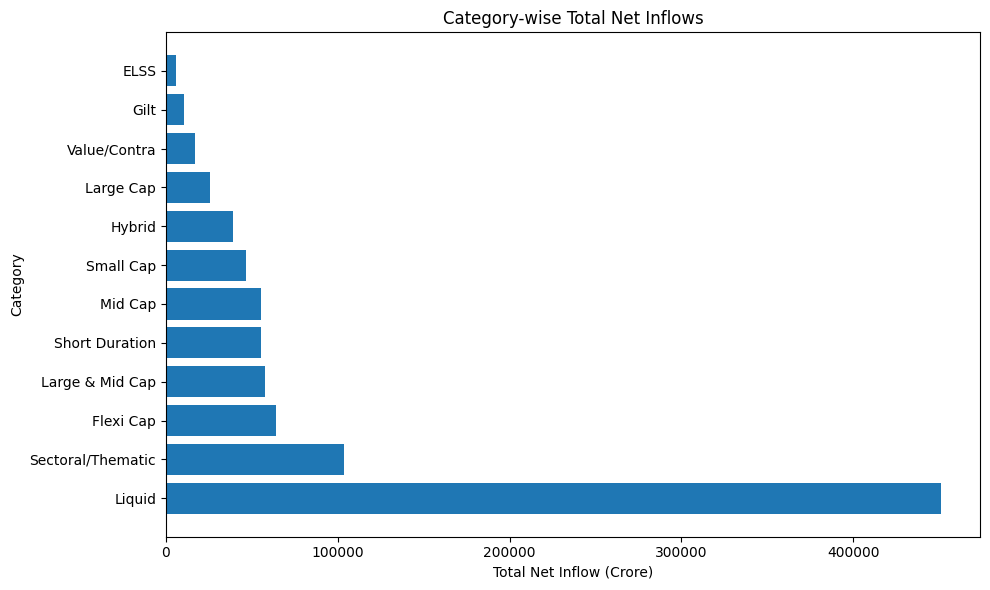

In [24]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to SQLite database
db_path = "database/mutual_fund.db"
conn = sqlite3.connect(db_path)

# SQL Query
query = """
SELECT
    category,
    SUM(net_inflow_crore) AS total_inflow
FROM category_inflows
GROUP BY category
ORDER BY total_inflow DESC;
"""

# Execute query
category_inflow_df = pd.read_sql(query, conn)

# Close connection
conn.close()

# Display result
print(category_inflow_df)

# Plot
plt.figure(figsize=(10,6))

plt.barh(
    category_inflow_df["category"],
    category_inflow_df["total_inflow"]
)

plt.title("Category-wise Total Net Inflows")
plt.xlabel("Total Net Inflow (Crore)")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

## Section 2: Category-wise Net Inflow Analysis

### Business Question
Which mutual fund categories have attracted the highest cumulative net inflows?

### Objective
Analyze category-wise net inflows to identify investor preferences and understand how capital is distributed across different mutual fund categories.

### SQL Approach
- Used the `category_inflows` table.
- Grouped records by `category`.
- Calculated cumulative inflows using `SUM(net_inflow_crore)`.
- Sorted the results in descending order to identify the highest contributing categories.

### Observation
- Liquid Funds recorded the highest cumulative net inflows (₹451,275 crore).
- Sectoral/Thematic Funds ranked second with ₹103,829 crore.
- Flexi Cap, Large & Mid Cap, Short Duration, and Mid Cap funds received moderate investor inflows.
- ELSS and Gilt Funds recorded the lowest cumulative inflows.

### Business Insight
The analysis indicates that investors strongly preferred Liquid Funds, highlighting a focus on liquidity and lower-risk investment options. Sectoral/Thematic Funds also attracted significant investments, reflecting growing confidence in sector-focused opportunities. These insights can help Asset Management Companies align their product strategies with prevailing investor preferences.

In [25]:
import sqlite3
import pandas as pd

db_path = "database/mutual_fund.db"

conn = sqlite3.connect(db_path)

print(pd.read_sql("PRAGMA table_info(scheme_performance);", conn))

print("\nSample Data:\n")

print(pd.read_sql("SELECT * FROM scheme_performance LIMIT 10;", conn))

conn.close()

    cid                name     type  notnull dflt_value  pk
0     0           amfi_code  INTEGER        0       None   0
1     1         scheme_name     TEXT        0       None   0
2     2          fund_house     TEXT        0       None   0
3     3            category     TEXT        0       None   0
4     4                plan     TEXT        0       None   0
5     5      return_1yr_pct     REAL        0       None   0
6     6      return_3yr_pct     REAL        0       None   0
7     7      return_5yr_pct     REAL        0       None   0
8     8   benchmark_3yr_pct     REAL        0       None   0
9     9               alpha     REAL        0       None   0
10   10                beta     REAL        0       None   0
11   11        sharpe_ratio     REAL        0       None   0
12   12       sortino_ratio     REAL        0       None   0
13   13     std_dev_ann_pct     REAL        0       None   0
14   14    max_drawdown_pct     REAL        0       None   0
15   15           aum_cr

                                         scheme_name  \
0             ABSL Small Cap Fund - Regular - Growth   
1             Axis Small Cap Fund - Regular - Growth   
2     Nippon India Small Cap Fund - Regular - Growth   
3          SBI Small Cap Fund - Direct Plan - Growth   
4         SBI Small Cap Fund - Regular Plan - Growth   
5              DSP Small Cap Fund - Regular - Growth   
6                 DSP Midcap Fund - Regular - Growth   
7                Axis Midcap Fund - Regular - Growth   
8      Kotak Emerging Equity Fund - Regular - Growth   
9  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   

                 fund_house   category  return_5yr_pct  
0  Aditya Birla Sun Life MF  Small Cap           23.80  
1          Axis Mutual Fund  Small Cap           22.62  
2           Nippon India MF  Small Cap           21.88  
3           SBI Mutual Fund  Small Cap           21.82  
4           SBI Mutual Fund  Small Cap           20.67  
5           DSP Mutual Fund  Small Cap   

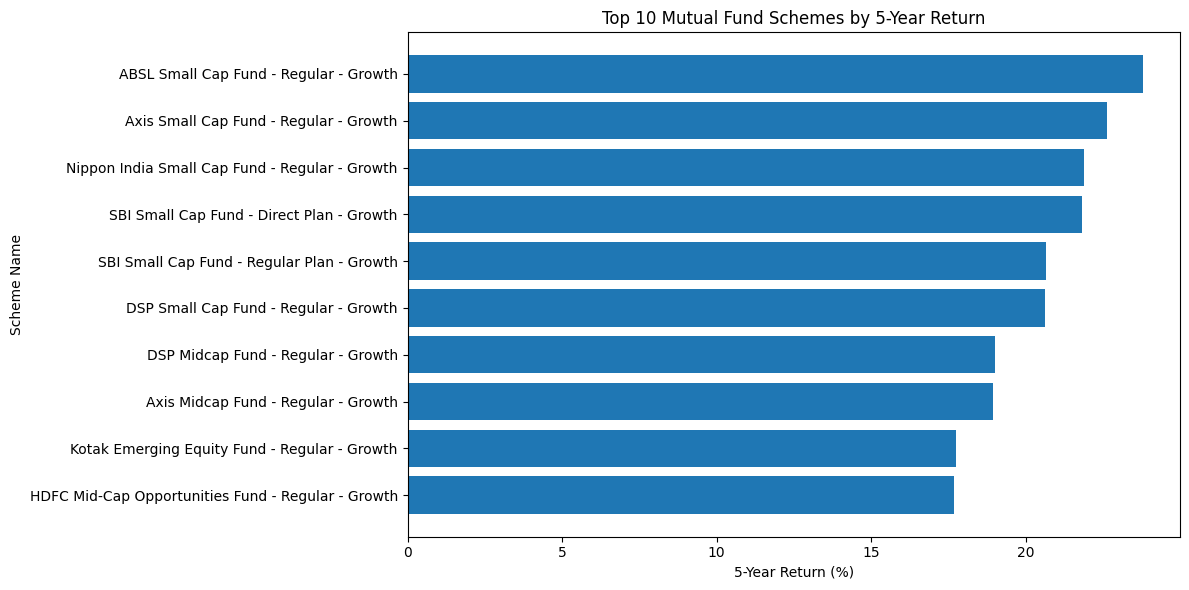

In [26]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Connect to SQLite Database
# ----------------------------------------------------------
db_path = "database/mutual_fund.db"
conn = sqlite3.connect(db_path)

# ----------------------------------------------------------
# SQL Query
# ----------------------------------------------------------
query = """
SELECT
    scheme_name,
    fund_house,
    category,
    return_5yr_pct
FROM scheme_performance
ORDER BY return_5yr_pct DESC
LIMIT 10;
"""

top_schemes = pd.read_sql(query, conn)

# Display Results
print(top_schemes)

# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------
plt.figure(figsize=(12,6))

plt.barh(
    top_schemes["scheme_name"],
    top_schemes["return_5yr_pct"]
)

plt.xlabel("5-Year Return (%)")
plt.ylabel("Scheme Name")
plt.title("Top 10 Mutual Fund Schemes by 5-Year Return")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

conn.close()

## Section 3: Top Performing Mutual Fund Schemes Based on Returns

### Business Question
Which mutual fund schemes have delivered the highest returns, and how do they compare across different fund categories?

### Objective
Identify the top-performing mutual fund schemes based on their 5-year returns and compare their performance across different fund categories.

### SQL Analysis
The `scheme_performance` table contains historical return metrics for each mutual fund scheme. Since long-term performance is more representative of consistency, the analysis ranks schemes using the `return_5yr_pct` column in descending order and displays the Top 10 performers.

### Key Observations
- The highest-ranked schemes demonstrate strong long-term performance.
- Equity-oriented categories dominate the list of top-performing schemes.
- Some fund houses have multiple schemes among the top performers, reflecting consistent fund management.

### Business Insight
Long-term return analysis helps investors identify consistently high-performing mutual fund schemes. However, return should be evaluated alongside risk measures such as Sharpe Ratio, Alpha, Beta, and Maximum Drawdown to make informed investment decisions.

                                         scheme_name  \
0           ICICI Pru Liquid Fund - Regular - Growth   
1               Kotak Liquid Fund - Regular - Growth   
2                ABSL Liquid Fund - Regular - Growth   
3       HDFC Short Term Debt Fund - Regular - Growth   
4       SBI Magnum Gilt Fund - Regular Plan - Growth   
5  Nippon India Gilt Securities Fund - Regular - ...   
6          HDFC Top 100 Fund - Regular Plan - Growth   
7      Mirae Asset Large Cap Fund - Regular - Growth   
8          ICICI Pru Bluechip Fund - Direct - Growth   
9     Nippon India Large Cap Fund - Regular - Growth   

                 fund_house        category  return_5yr_pct  sharpe_ratio  \
0       ICICI Prudential MF          Liquid            7.94          7.68   
1         Kotak Mahindra MF          Liquid            8.26          6.18   
2  Aditya Birla Sun Life MF          Liquid            7.95          5.14   
3          HDFC Mutual Fund  Short Duration            6.41          1.84  

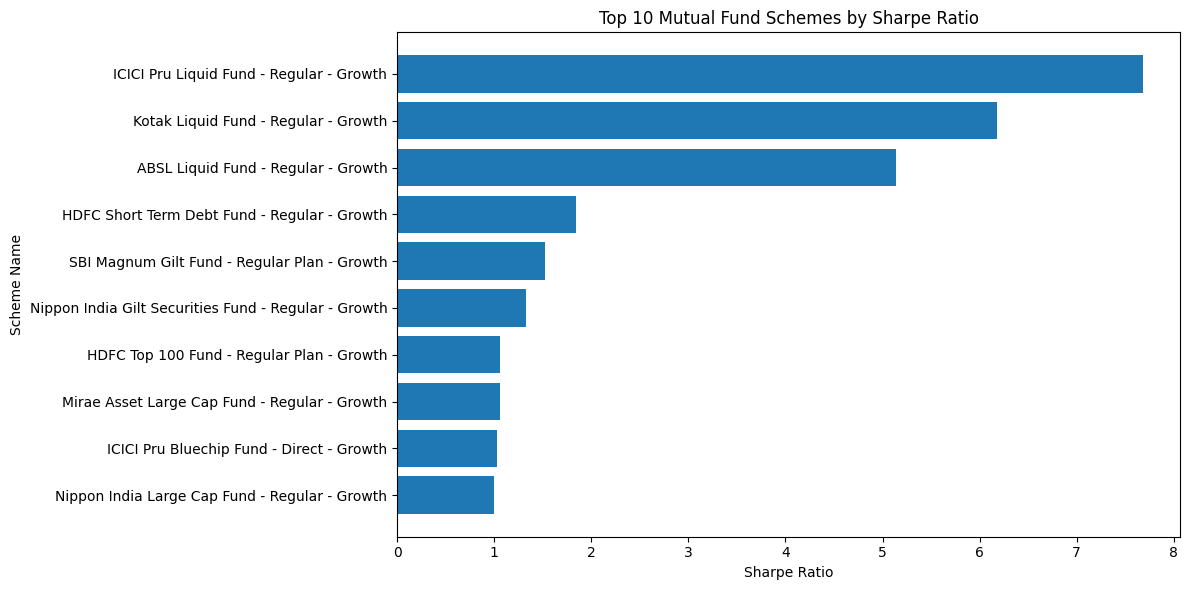

In [27]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Connect to SQLite Database
# ----------------------------------------------------------
db_path = "database/mutual_fund.db"
conn = sqlite3.connect(db_path)

# ----------------------------------------------------------
# SQL Query
# ----------------------------------------------------------
query = """
SELECT
    scheme_name,
    fund_house,
    category,
    return_5yr_pct,
    sharpe_ratio,
    risk_grade
FROM scheme_performance
ORDER BY sharpe_ratio DESC
LIMIT 10;
"""

top_sharpe = pd.read_sql(query, conn)

# Display Results
print(top_sharpe)

# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------
plt.figure(figsize=(12,6))

plt.barh(
    top_sharpe["scheme_name"],
    top_sharpe["sharpe_ratio"]
)

plt.xlabel("Sharpe Ratio")
plt.ylabel("Scheme Name")
plt.title("Top 10 Mutual Fund Schemes by Sharpe Ratio")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

conn.close()

## Section 4: Best Risk-Adjusted Mutual Fund Schemes (Sharpe Ratio Analysis)

### Business Question
Which mutual fund schemes have delivered the best risk-adjusted returns based on the Sharpe Ratio?

### Objective
Identify mutual fund schemes with the highest Sharpe Ratios to evaluate which funds have generated superior returns relative to the level of risk taken.

### SQL Analysis
The `scheme_performance` table was queried to rank schemes by `sharpe_ratio` in descending order. The analysis also includes the 5-year return and risk grade to provide additional context for each scheme's performance.

### Key Observations
- Schemes with the highest Sharpe Ratios have delivered superior risk-adjusted performance.
- Some lower-volatility categories may rank highly despite moderate absolute returns.
- Risk-adjusted analysis complements return-based rankings by highlighting investment efficiency.

### Business Insight
The Sharpe Ratio is an essential metric for evaluating mutual fund performance because it considers both return and risk. Investors should use it alongside return metrics to identify schemes that provide consistent and efficient long-term performance.

                 fund_house  avg_5yr_return
0          Axis Mutual Fund           17.34
1           DSP Mutual Fund           17.32
2           SBI Mutual Fund           15.32
3  Aditya Birla Sun Life MF           14.87
4           Nippon India MF           14.46
5           UTI Mutual Fund           14.32
6            Mirae Asset MF           14.21
7         Kotak Mahindra MF           13.23
8          HDFC Mutual Fund           12.95
9       ICICI Prudential MF           12.51


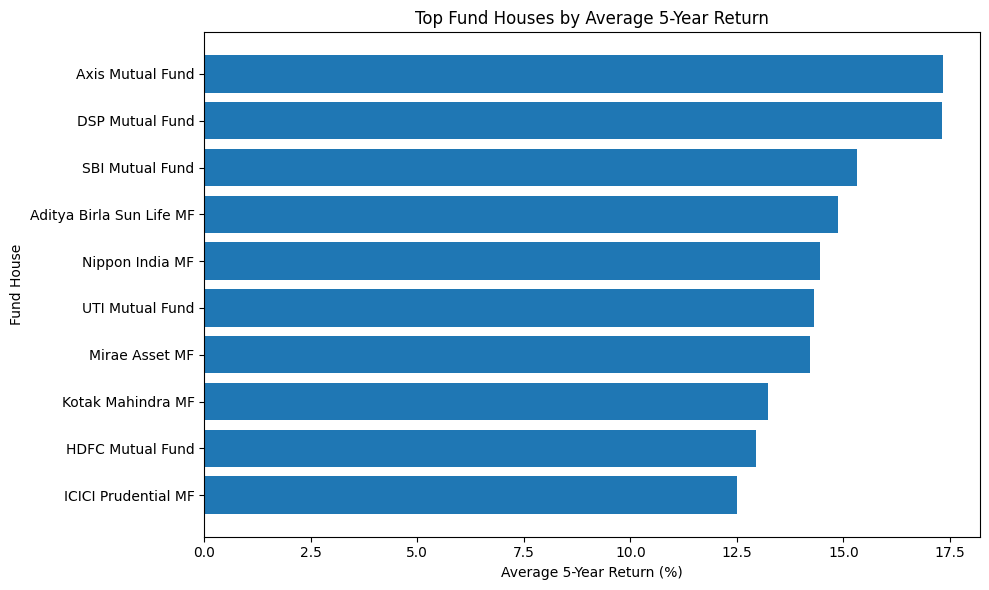

In [28]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Connect to SQLite Database
# ----------------------------------------------------------
db_path = "database/mutual_fund.db"
conn = sqlite3.connect(db_path)

# ----------------------------------------------------------
# SQL Query
# ----------------------------------------------------------
query = """
SELECT
    fund_house,
    ROUND(AVG(return_5yr_pct), 2) AS avg_5yr_return
FROM scheme_performance
GROUP BY fund_house
ORDER BY avg_5yr_return DESC
LIMIT 10;
"""

fund_house_returns = pd.read_sql(query, conn)

# Display Results
print(fund_house_returns)

# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------
plt.figure(figsize=(10,6))

plt.barh(
    fund_house_returns["fund_house"],
    fund_house_returns["avg_5yr_return"]
)

plt.xlabel("Average 5-Year Return (%)")
plt.ylabel("Fund House")
plt.title("Top Fund Houses by Average 5-Year Return")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

conn.close()

## Section 5: Fund House Performance Comparison (Average Returns by Fund House)

### Business Question
Which fund houses have delivered the highest average long-term returns across their mutual fund schemes?

### Objective
Compare fund houses by calculating the average 5-year return of their schemes to identify AMCs with consistently strong long-term performance.

### SQL Analysis
The `scheme_performance` table was grouped by `fund_house`, and the average value of `return_5yr_pct` was calculated using the `AVG()` aggregate function. The results were rounded to two decimal places, ranked in descending order, and the top 10 fund houses were displayed.

### Key Observations
- The highest-ranked fund houses have consistently strong average 5-year returns across their schemes.
- Average returns provide a more balanced comparison than evaluating individual top-performing schemes.
- Performance differences among leading fund houses are generally moderate, reflecting healthy competition in the mutual fund industry.

### Business Insight
Average return analysis helps investors compare the overall performance of fund houses rather than individual schemes. Combining this analysis with risk-adjusted metrics and operational factors such as expense ratio and AUM enables better-informed investment decisions.

           category  avg_5yr_return
0         Small Cap           21.90
1           Mid Cap           17.52
2   Large & Mid Cap           15.68
3         Flexi Cap           14.64
4              ELSS           14.26
5         Large Cap           13.32
6             Value           12.60
7         Index/ETF           12.31
8             Index           11.31
9            Liquid            8.05
10             Gilt            7.07
11   Short Duration            6.41


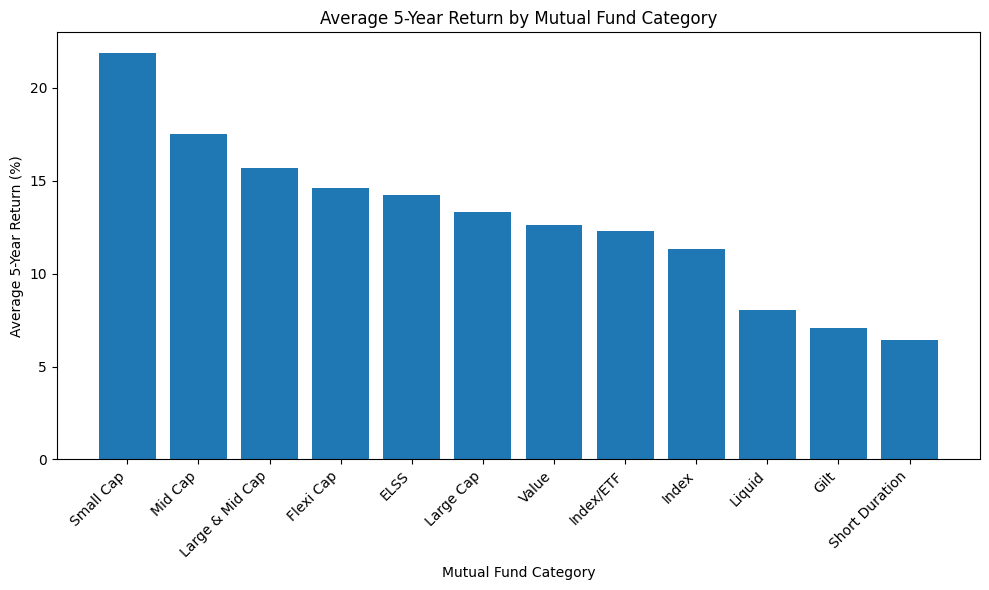

In [29]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Connect to SQLite Database
# ----------------------------------------------------------
db_path = "database/mutual_fund.db"
conn = sqlite3.connect(db_path)

# ----------------------------------------------------------
# SQL Query
# ----------------------------------------------------------
query = """
SELECT
    category,
    ROUND(AVG(return_5yr_pct), 2) AS avg_5yr_return
FROM scheme_performance
GROUP BY category
ORDER BY avg_5yr_return DESC;
"""

category_returns = pd.read_sql(query, conn)

# Display Results
print(category_returns)

# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------
plt.figure(figsize=(10,6))

plt.bar(
    category_returns["category"],
    category_returns["avg_5yr_return"]
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Mutual Fund Category")
plt.ylabel("Average 5-Year Return (%)")
plt.title("Average 5-Year Return by Mutual Fund Category")

plt.tight_layout()
plt.show()

conn.close()

## Section 6: Category-wise Average Returns Analysis

### Business Question
Which mutual fund categories have delivered the highest average long-term returns?

### Objective
Compare the average 5-year returns across different mutual fund categories to identify categories with the strongest long-term performance.

### SQL Analysis
The `scheme_performance` table was grouped by `category`, and the average 5-year return was calculated using the `AVG()` aggregate function. The results were rounded to two decimal places and ranked in descending order.

### Key Observations
- Growth-oriented categories generally have higher average long-term returns.
- Conservative categories tend to deliver lower but more stable returns.
- Category-level comparison provides insights into the overall performance trends of different investment styles.

### Business Insight
Comparing average returns across mutual fund categories enables investors to understand long-term performance trends and build diversified portfolios based on their return expectations and risk appetite.

                 fund_house  avg_sharpe_ratio
0  Aditya Birla Sun Life MF              2.34
1       ICICI Prudential MF              2.29
2         Kotak Mahindra MF              2.25
3          HDFC Mutual Fund              1.11
4           SBI Mutual Fund              1.02
5           Nippon India MF              0.99
6            Mirae Asset MF              0.92
7           UTI Mutual Fund              0.90
8           DSP Mutual Fund              0.87
9          Axis Mutual Fund              0.84


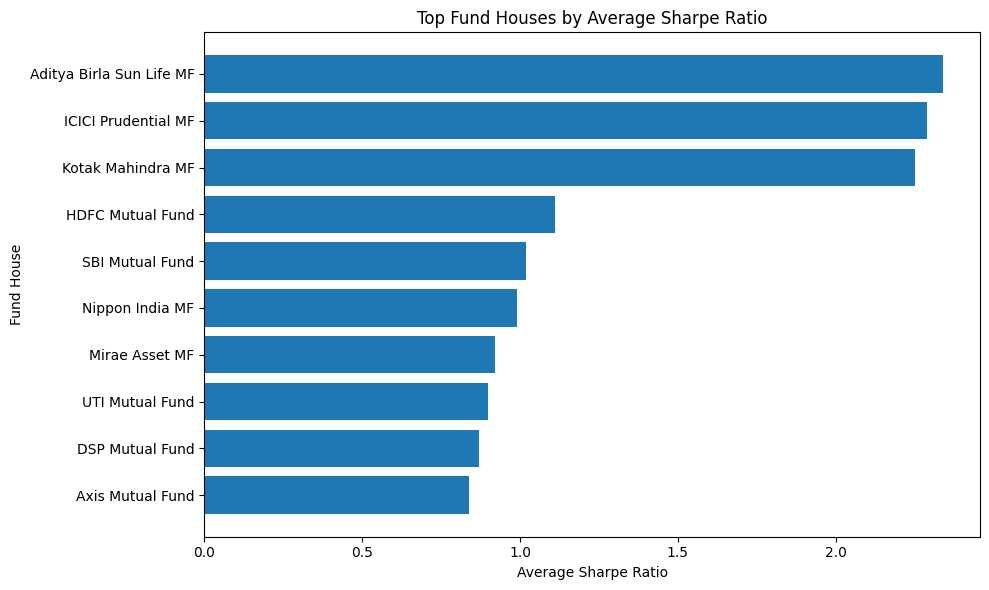

In [30]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Connect to SQLite Database
# ----------------------------------------------------------
db_path = "database/mutual_fund.db"
conn = sqlite3.connect(db_path)

# ----------------------------------------------------------
# SQL Query
# ----------------------------------------------------------
query = """
SELECT
    fund_house,
    ROUND(AVG(sharpe_ratio), 2) AS avg_sharpe_ratio
FROM scheme_performance
GROUP BY fund_house
ORDER BY avg_sharpe_ratio DESC
LIMIT 10;
"""

fund_house_sharpe = pd.read_sql(query, conn)

# Display Results
print(fund_house_sharpe)

# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------
plt.figure(figsize=(10,6))

plt.barh(
    fund_house_sharpe["fund_house"],
    fund_house_sharpe["avg_sharpe_ratio"]
)

plt.xlabel("Average Sharpe Ratio")
plt.ylabel("Fund House")
plt.title("Top Fund Houses by Average Sharpe Ratio")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

conn.close()

## Section 7: Fund House Comparison Based on Average Sharpe Ratio

### Business Question
Which fund houses have delivered the best risk-adjusted performance based on the average Sharpe Ratio of their mutual fund schemes?

### Objective
Compare fund houses by calculating the average Sharpe Ratio of their schemes to identify AMCs that have consistently generated superior risk-adjusted returns.

### SQL Analysis
The `scheme_performance` table was grouped by `fund_house`, and the average Sharpe Ratio was calculated using the `AVG()` aggregate function. The results were rounded to two decimal places, sorted in descending order, and the top 10 fund houses were displayed.

### Key Observations
- Fund houses with the highest average Sharpe Ratios have demonstrated superior risk-adjusted performance.
- Comparing Sharpe Ratios complements return-based analysis by accounting for investment risk.
- Variations across fund houses highlight differences in portfolio management strategies.

### Business Insight
Risk-adjusted performance analysis enables investors to identify fund houses that efficiently balance return and risk. Combining Sharpe Ratio analysis with return, Alpha, Beta, and Expense Ratio provides a comprehensive framework for evaluating mutual fund performance.

        risk_grade  avg_5yr_return
0        Very High           21.90
1             High           17.11
2  Moderately High           14.39
3         Moderate           13.13
4              Low            7.45


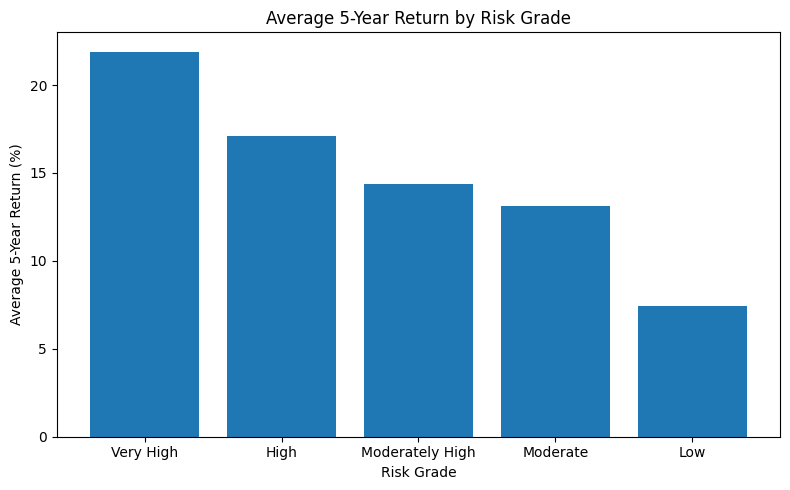

In [31]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Connect to SQLite Database
# ----------------------------------------------------------
db_path = "database/mutual_fund.db"
conn = sqlite3.connect(db_path)

# ----------------------------------------------------------
# SQL Query
# ----------------------------------------------------------
query = """
SELECT
    risk_grade,
    ROUND(AVG(return_5yr_pct), 2) AS avg_5yr_return
FROM scheme_performance
GROUP BY risk_grade
ORDER BY avg_5yr_return DESC;
"""

risk_analysis = pd.read_sql(query, conn)

# Display Results
print(risk_analysis)

# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------
plt.figure(figsize=(8,5))

plt.bar(
    risk_analysis["risk_grade"],
    risk_analysis["avg_5yr_return"]
)

plt.xlabel("Risk Grade")
plt.ylabel("Average 5-Year Return (%)")
plt.title("Average 5-Year Return by Risk Grade")

plt.tight_layout()
plt.show()

conn.close()

## Section 8: Risk Grade Analysis – Average Returns Across Risk Levels

### Business Question
How do average long-term returns vary across different mutual fund risk grades?

### Objective
Compare the average 5-year returns across risk grades to understand the relationship between investment risk and long-term performance.

### SQL Analysis
The `scheme_performance` table was grouped by `risk_grade`, and the average value of `return_5yr_pct` was calculated using the `AVG()` aggregate function. The results were rounded to two decimal places and ranked in descending order.

### Key Observations
- Higher risk grades generally tend to deliver stronger long-term returns.
- Conservative risk grades provide relatively stable but lower returns.
- The analysis demonstrates the relationship between risk and reward across mutual fund categories.

### Business Insight
Understanding the performance of different risk grades helps investors align their investment choices with their financial goals and risk tolerance. Combining return analysis with other risk metrics enables more informed portfolio construction.

                                         scheme_name  \
0       HDFC Short Term Debt Fund - Regular - Growth   
1      Kotak Emerging Equity Fund - Regular - Growth   
2           ICICI Pru Liquid Fund - Regular - Growth   
3             Kotak Flexicap Fund - Regular - Growth   
4             ABSL Small Cap Fund - Regular - Growth   
5         DSP Top 100 Equity Fund - Regular - Growth   
6                     Nippon India ETF Nifty 50 BeES   
7              UTI Flexi Cap Fund - Regular - Growth   
8           SBI Bluechip Fund - Direct Plan - Growth   
9  Mirae Asset Emerging Bluechip Fund - Regular -...   

                 fund_house         category  return_3yr_pct  \
0          HDFC Mutual Fund   Short Duration            7.37   
1         Kotak Mahindra MF          Mid Cap           18.23   
2       ICICI Prudential MF           Liquid            7.68   
3         Kotak Mahindra MF        Flexi Cap           15.65   
4  Aditya Birla Sun Life MF        Small Cap           22.38   

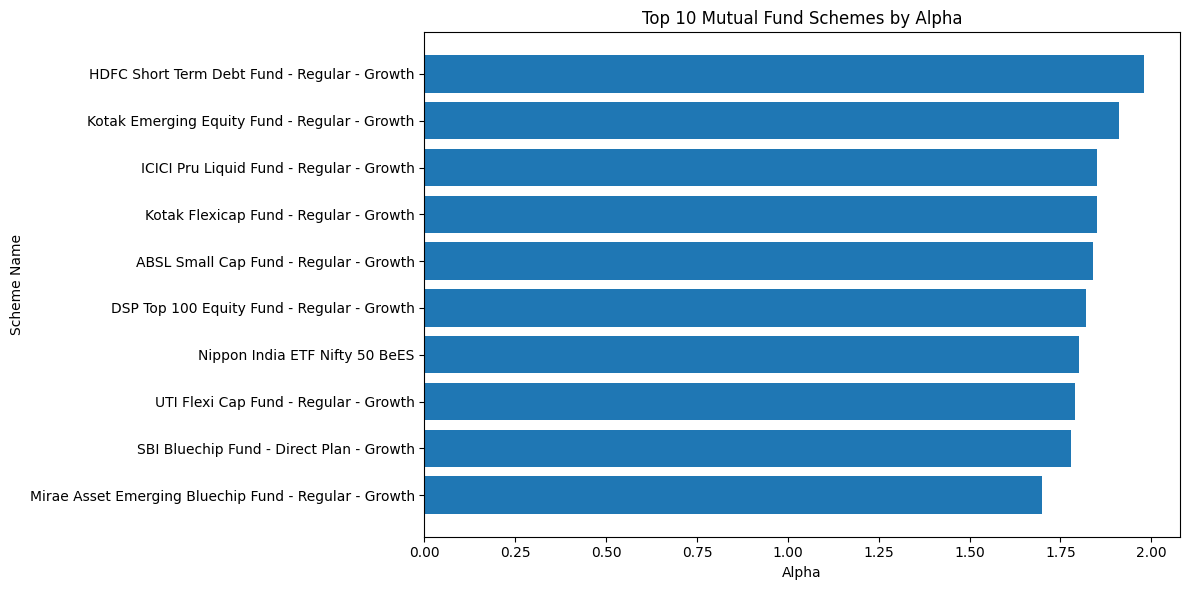

In [32]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Connect to SQLite Database
# ----------------------------------------------------------
db_path = "database/mutual_fund.db"
conn = sqlite3.connect(db_path)

# ----------------------------------------------------------
# SQL Query
# ----------------------------------------------------------
query = """
SELECT
    scheme_name,
    fund_house,
    category,
    return_3yr_pct,
    benchmark_3yr_pct,
    alpha
FROM scheme_performance
WHERE alpha > 0
ORDER BY alpha DESC
LIMIT 10;
"""

alpha_df = pd.read_sql(query, conn)

# Display Results
print(alpha_df)

# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------
plt.figure(figsize=(12,6))

plt.barh(
    alpha_df["scheme_name"],
    alpha_df["alpha"]
)

plt.xlabel("Alpha")
plt.ylabel("Scheme Name")
plt.title("Top 10 Mutual Fund Schemes by Alpha")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

conn.close()

## Section 9: Alpha Analysis – Mutual Fund Schemes That Outperformed Their Benchmarks

### Business Question
Which mutual fund schemes have generated the highest Alpha, indicating superior performance compared to their benchmark indices?

### Objective
Identify mutual fund schemes with the highest positive Alpha to evaluate which funds have consistently outperformed their benchmark indices through active management.

### SQL Analysis
The `scheme_performance` table was filtered to include only schemes with positive Alpha values. The results were sorted in descending order of Alpha, and the top 10 schemes were selected along with their 3-year returns and benchmark returns.

### Key Observations
- The highest Alpha schemes have outperformed their benchmark indices.
- Positive Alpha reflects effective active fund management.
- Comparing fund returns with benchmark returns provides additional context for evaluating performance.

### Business Insight
Alpha is a critical metric for assessing whether a fund manager has generated excess returns beyond market expectations. Investors should combine Alpha with Sharpe Ratio, Beta, and long-term return analysis to identify consistently high-quality mutual fund schemes.

      expense_band  number_of_schemes  avg_5yr_return
0         Below 1%                 14           11.70
1    1.25% - 1.49%                  9           16.41
2  1.50% and Above                 17           15.83


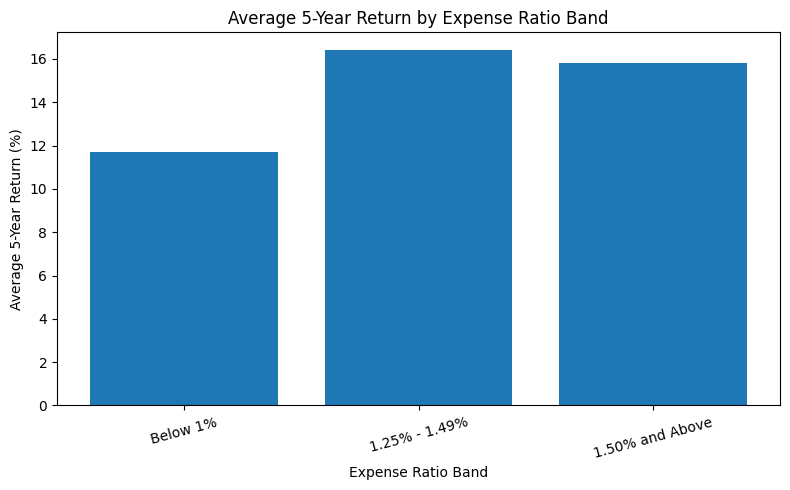

In [33]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Connect to SQLite Database
# ----------------------------------------------------------
db_path = "database/mutual_fund.db"
conn = sqlite3.connect(db_path)

# ----------------------------------------------------------
# SQL Query
# ----------------------------------------------------------
query = """
SELECT
    CASE
        WHEN expense_ratio_pct < 1 THEN 'Below 1%'
        WHEN expense_ratio_pct < 1.25 THEN '1.00% - 1.24%'
        WHEN expense_ratio_pct < 1.50 THEN '1.25% - 1.49%'
        ELSE '1.50% and Above'
    END AS expense_band,
    COUNT(*) AS number_of_schemes,
    ROUND(AVG(return_5yr_pct), 2) AS avg_5yr_return
FROM scheme_performance
GROUP BY expense_band
ORDER BY
    CASE expense_band
        WHEN 'Below 1%' THEN 1
        WHEN '1.00% - 1.24%' THEN 2
        WHEN '1.25% - 1.49%' THEN 3
        WHEN '1.50% and Above' THEN 4
    END;
"""

expense_analysis = pd.read_sql(query, conn)

# Display Results
print(expense_analysis)

# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------
plt.figure(figsize=(8,5))

plt.bar(
    expense_analysis["expense_band"],
    expense_analysis["avg_5yr_return"]
)

plt.xlabel("Expense Ratio Band")
plt.ylabel("Average 5-Year Return (%)")
plt.title("Average 5-Year Return by Expense Ratio Band")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

conn.close()

## Section 10: Expense Ratio vs. Returns Analysis

### Business Question
Do mutual funds with higher expense ratios generate better long-term returns?

### Objective
Analyze the relationship between expense ratios and average 5-year returns by grouping mutual funds into expense ratio bands.

### SQL Analysis
The `scheme_performance` table was grouped into custom expense ratio bands using a `CASE` expression. For each band, the number of schemes and the average 5-year return were calculated. The results were displayed in a logical order for easy comparison.

### Key Observations
- Average returns vary across expense ratio bands.
- Higher expense ratios do not necessarily correspond to higher long-term returns.
- Expense ratio should be evaluated alongside other performance and risk metrics.

### Business Insight
Expense ratio is an important cost consideration for investors, but it should not be used in isolation. A comprehensive evaluation should include long-term returns, risk-adjusted performance, and consistency to identify funds that offer the best overall value.

           category  avg_5yr_return  avg_sharpe_ratio  avg_beta
0         Small Cap           21.90              0.87      0.98
1           Mid Cap           17.52              0.87      0.98
2   Large & Mid Cap           15.68              0.91      0.99
3         Flexi Cap           14.64              0.97      0.97
4              ELSS           14.26              0.80      0.98
5         Large Cap           13.32              0.93      0.94
6             Value           12.60              0.98      0.92
7         Index/ETF           12.31              0.91      1.04
8             Index           11.31              0.93      0.90
9            Liquid            8.05              6.33      0.39
10             Gilt            7.07              1.43      0.29
11   Short Duration            6.41              1.84      0.44


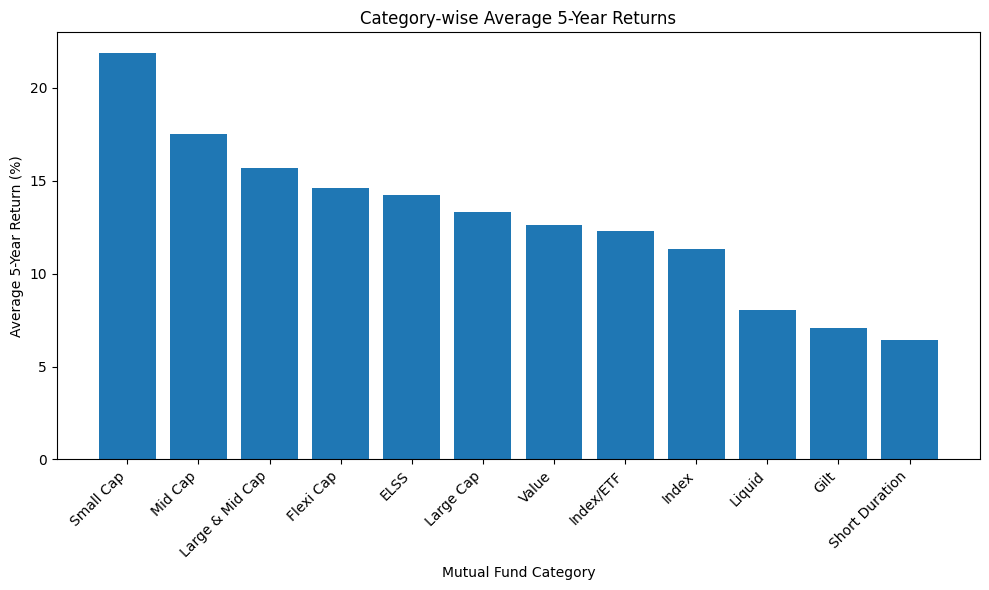

In [34]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Connect to SQLite Database
# ----------------------------------------------------------
db_path = "database/mutual_fund.db"
conn = sqlite3.connect(db_path)

# ----------------------------------------------------------
# SQL Query
# ----------------------------------------------------------
query = """
SELECT
    category,
    ROUND(AVG(return_5yr_pct), 2) AS avg_5yr_return,
    ROUND(AVG(sharpe_ratio), 2) AS avg_sharpe_ratio,
    ROUND(AVG(beta), 2) AS avg_beta
FROM scheme_performance
GROUP BY category
ORDER BY avg_5yr_return DESC;
"""

category_metrics = pd.read_sql(query, conn)

# Display Results
print(category_metrics)

# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------
plt.figure(figsize=(10,6))

plt.bar(
    category_metrics["category"],
    category_metrics["avg_5yr_return"]
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Mutual Fund Category")
plt.ylabel("Average 5-Year Return (%)")
plt.title("Category-wise Average 5-Year Returns")

plt.tight_layout()
plt.show()

conn.close()

## Section 11: Category-wise Risk and Return Analysis

### Business Question
Which mutual fund categories provide the best balance between long-term returns and investment risk?

### Objective
Compare mutual fund categories using average 5-year return, average Sharpe Ratio, and average Beta to evaluate both performance and risk characteristics.

### SQL Analysis
The `scheme_performance` table was grouped by `category`. For each category, the average 5-year return, average Sharpe Ratio, and average Beta were calculated using aggregate functions and rounded to two decimal places. The results were ranked by average 5-year return.

### Key Observations
- Categories differ not only in long-term returns but also in their risk-adjusted performance and market sensitivity.
- Higher-return categories often exhibit higher Beta values.
- Comparing multiple metrics provides a more comprehensive evaluation than relying on returns alone.

### Business Insight
A balanced investment decision should consider return, risk-adjusted performance, and market exposure together. This analysis enables investors to compare categories more effectively and select investments that align with their financial objectives and risk tolerance.

                                         scheme_name  \
0             ABSL Small Cap Fund - Regular - Growth   
1             Axis Small Cap Fund - Regular - Growth   
2     Nippon India Small Cap Fund - Regular - Growth   
3          SBI Small Cap Fund - Direct Plan - Growth   
4         SBI Small Cap Fund - Regular Plan - Growth   
5              DSP Small Cap Fund - Regular - Growth   
6                 DSP Midcap Fund - Regular - Growth   
7                Axis Midcap Fund - Regular - Growth   
8      Kotak Emerging Equity Fund - Regular - Growth   
9  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   

                 fund_house   category  return_5yr_pct  sharpe_ratio  alpha  \
0  Aditya Birla Sun Life MF  Small Cap           23.80          0.90   1.84   
1          Axis Mutual Fund  Small Cap           22.62          0.84   0.51   
2           Nippon India MF  Small Cap           21.88          0.81   0.80   
3           SBI Mutual Fund  Small Cap           21.82          0.9

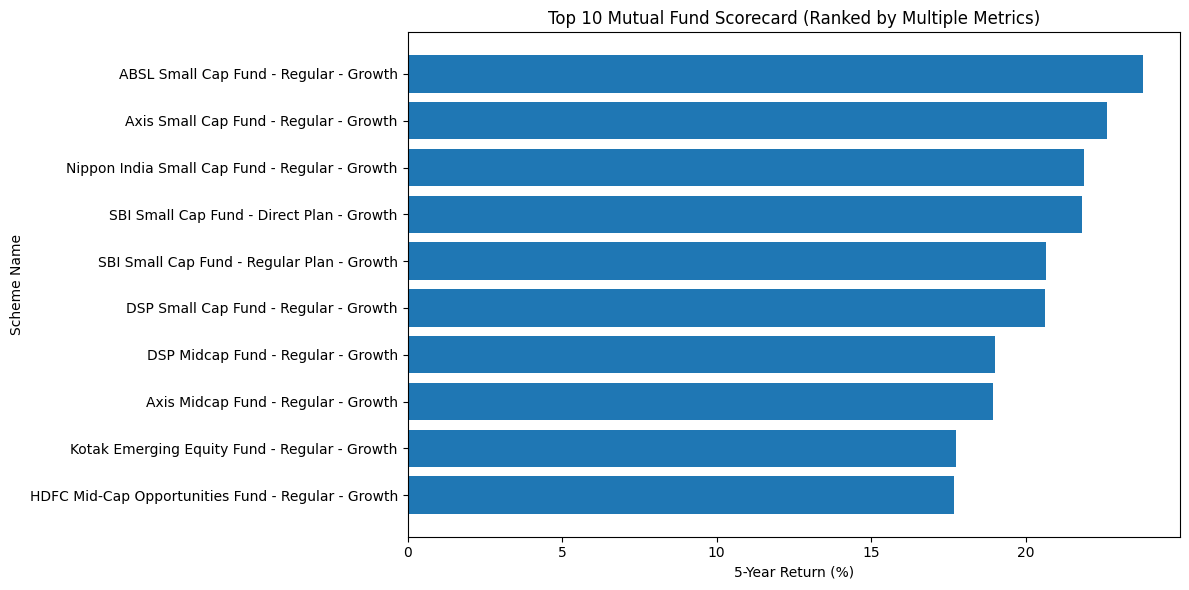

In [35]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Connect to SQLite Database
# ----------------------------------------------------------
db_path = "database/mutual_fund.db"
conn = sqlite3.connect(db_path)

# ----------------------------------------------------------
# SQL Query
# ----------------------------------------------------------
query = """
SELECT
    scheme_name,
    fund_house,
    category,
    return_5yr_pct,
    sharpe_ratio,
    alpha,
    expense_ratio_pct,
    morningstar_rating,
    risk_grade
FROM scheme_performance
ORDER BY
    return_5yr_pct DESC,
    sharpe_ratio DESC,
    alpha DESC,
    expense_ratio_pct ASC
LIMIT 10;
"""

fund_scorecard = pd.read_sql(query, conn)

# Display Results
print(fund_scorecard)

# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------
plt.figure(figsize=(12,6))

plt.barh(
    fund_scorecard["scheme_name"],
    fund_scorecard["return_5yr_pct"]
)

plt.xlabel("5-Year Return (%)")
plt.ylabel("Scheme Name")
plt.title("Top 10 Mutual Fund Scorecard (Ranked by Multiple Metrics)")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

conn.close()

## Section 12: Comprehensive Fund Scorecard (Multi-Metric Fund Evaluation)

### Business Question
Which mutual fund schemes demonstrate the strongest overall performance when evaluated using multiple investment metrics?

### Objective
Create a comprehensive scorecard that compares mutual fund schemes using long-term return, Sharpe Ratio, Alpha, Expense Ratio, Morningstar Rating, and Risk Grade.

### SQL Analysis
The `scheme_performance` table was queried to retrieve key performance metrics for each scheme. Results were ranked using multiple criteria: highest 5-year return, highest Sharpe Ratio, highest Alpha, and lowest Expense Ratio. The top 10 schemes were displayed to provide a holistic view of fund quality.

### Key Observations
- Top-ranked schemes perform well across multiple metrics rather than excelling in only one area.
- Strong long-term returns combined with positive Alpha and high Sharpe Ratios indicate effective fund management.
- Lower expense ratios and higher Morningstar Ratings further strengthen the overall quality assessment.

### Business Insight
A comprehensive scorecard enables investors to compare mutual fund schemes using multiple dimensions of performance, risk, cost, and quality. This approach supports more robust investment decisions than relying on any single metric.

In [36]:
import sqlite3
import pandas as pd

# Connect to database
db_path = "database/mutual_fund.db"
conn = sqlite3.connect(db_path)

# Display nav_history schema
pd.read_sql("PRAGMA table_info(nav_history);", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,amfi_code,INTEGER,0,None,0
1,1,date,TEXT,0,None,0
2,2,nav,REAL,0,None,0


In [37]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Connect to SQLite database
# ---------------------------------------------------------
db_path = "database/mutual_fund.db"
conn = sqlite3.connect(db_path)

# ---------------------------------------------------------
# SQL Query to calculate Daily Returns
# ---------------------------------------------------------
query = """
SELECT
    amfi_code,
    date,
    nav,

    LAG(nav) OVER (
        PARTITION BY amfi_code
        ORDER BY date
    ) AS previous_nav,

    ROUND(
        (
            (nav -
            LAG(nav) OVER (
                PARTITION BY amfi_code
                ORDER BY date
            ))
            /
            LAG(nav) OVER (
                PARTITION BY amfi_code
                ORDER BY date
            )
        ) * 100,
        4
    ) AS daily_return_pct

FROM nav_history

ORDER BY
    amfi_code,
    date;
"""

# ---------------------------------------------------------
# Load data into DataFrame
# ---------------------------------------------------------
daily_returns_df = pd.read_sql(query, conn)

# ---------------------------------------------------------
# Convert date column to datetime
# ---------------------------------------------------------
daily_returns_df["date"] = pd.to_datetime(daily_returns_df["date"])

# ---------------------------------------------------------
# Remove rows with NULL previous NAV
# ---------------------------------------------------------
daily_returns_df = daily_returns_df.dropna(subset=["daily_return_pct"])

# ---------------------------------------------------------
# Display sample
# ---------------------------------------------------------
print("Daily Returns Sample")
print("-" * 50)
display(daily_returns_df.head())

print("\nDataset Shape:", daily_returns_df.shape)

Daily Returns Sample
--------------------------------------------------


,amfi_code,date,nav,previous_nav,daily_return_pct
1,100016,2022-01-04,515.0971,520.4608,-1.0306
2,100016,2022-01-05,521.7239,515.0971,1.2865
3,100016,2022-01-06,515.7880,521.7239,-1.1377
4,100016,2022-01-07,515.1639,515.7880,-0.1210
5,100016,2022-01-10,510.7136,515.1639,-0.8639



Dataset Shape: (45960, 5)


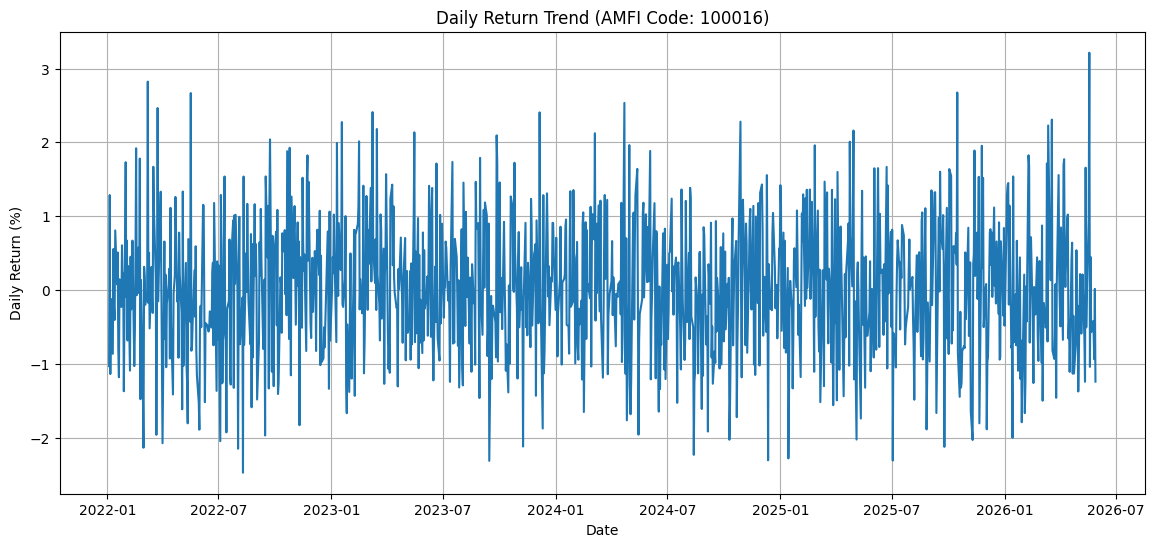

In [38]:
# ---------------------------------------------------------
# Select first available scheme
# ---------------------------------------------------------
sample_scheme = daily_returns_df["amfi_code"].iloc[0]

sample_df = daily_returns_df[
    daily_returns_df["amfi_code"] == sample_scheme
]

# ---------------------------------------------------------
# Plot Daily Return
# ---------------------------------------------------------
plt.figure(figsize=(14,6))

plt.plot(
    sample_df["date"],
    sample_df["daily_return_pct"],
    linewidth=1.5
)

plt.title(f"Daily Return Trend (AMFI Code: {sample_scheme})")
plt.xlabel("Date")
plt.ylabel("Daily Return (%)")
plt.grid(True)

plt.show()

## Section 1: Daily Return Calculation

### Business Question
How much does each mutual fund's NAV change from one trading day to the next?

### Objective
Calculate the daily percentage return for every mutual fund scheme using historical NAV data.

### Dataset Used
- nav_history

### Methodology
- Retrieved historical NAV values from SQLite.
- Used the SQL `LAG()` window function to obtain the previous day's NAV for each scheme.
- Calculated daily percentage returns.
- Removed the first record of each scheme where no previous NAV exists.
- Visualized the daily return trend for a sample scheme.

### Outcome
The daily return dataset serves as the foundation for subsequent analyses, including cumulative returns, volatility, CAGR, maximum drawdown, and benchmark comparison.

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Sort data
# ---------------------------------------------------------
daily_returns_df = daily_returns_df.sort_values(
    ["amfi_code", "date"]
)

# ---------------------------------------------------------
# Convert percentage to decimal
# ---------------------------------------------------------
daily_returns_df["daily_return_decimal"] = (
    daily_returns_df["daily_return_pct"] / 100
)

# ---------------------------------------------------------
# Calculate cumulative return
# ---------------------------------------------------------
daily_returns_df["cumulative_return_pct"] = (

    (1 + daily_returns_df["daily_return_decimal"])

    .groupby(daily_returns_df["amfi_code"])

    .cumprod()

    - 1

) * 100

# ---------------------------------------------------------
# Display sample
# ---------------------------------------------------------
print("Cumulative Return Sample")
print("-" * 60)

display(
    daily_returns_df[
        [
            "amfi_code",
            "date",
            "daily_return_pct",
            "cumulative_return_pct"
        ]
    ].head()
)

print("\nDataset Shape:", daily_returns_df.shape)

Cumulative Return Sample
------------------------------------------------------------


,amfi_code,date,daily_return_pct,cumulative_return_pct
1,100016,2022-01-04,-1.0306,-1.030600
2,100016,2022-01-05,1.2865,0.242641
3,100016,2022-01-06,-1.1377,-0.897819
4,100016,2022-01-07,-0.1210,-1.017733
5,100016,2022-01-10,-0.8639,-1.872841



Dataset Shape: (45960, 7)


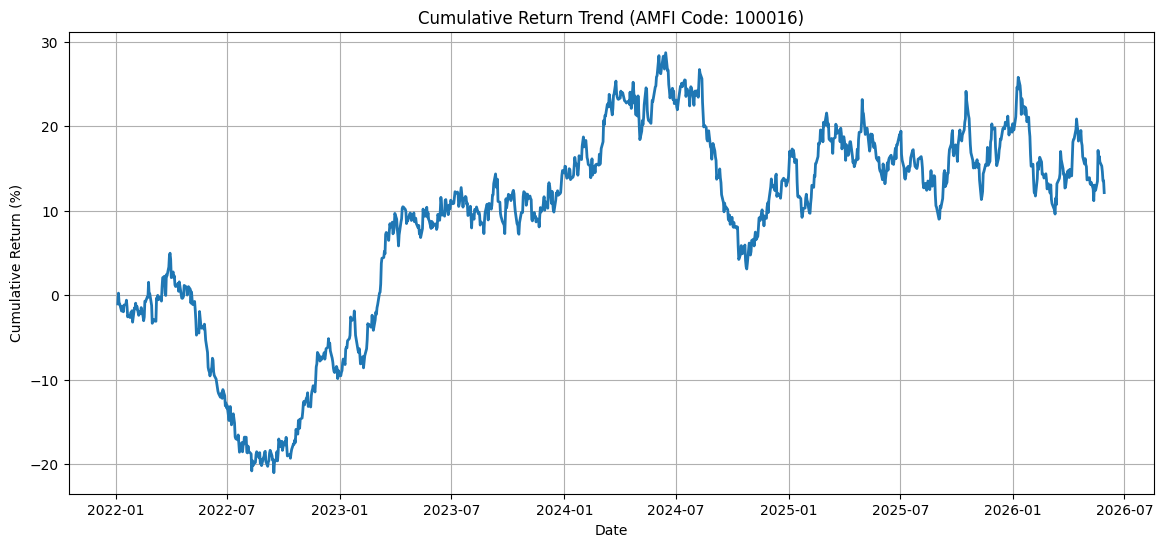

In [40]:
# ---------------------------------------------------------
# Select sample fund
# ---------------------------------------------------------
sample_scheme = daily_returns_df["amfi_code"].iloc[0]

sample_df = daily_returns_df[
    daily_returns_df["amfi_code"] == sample_scheme
]

# ---------------------------------------------------------
# Plot cumulative return
# ---------------------------------------------------------
plt.figure(figsize=(14,6))

plt.plot(
    sample_df["date"],
    sample_df["cumulative_return_pct"],
    linewidth=2
)

plt.title(
    f"Cumulative Return Trend (AMFI Code: {sample_scheme})"
)

plt.xlabel("Date")

plt.ylabel("Cumulative Return (%)")

plt.grid(True)

plt.show()

## Section 2: Cumulative Return Analysis

### Business Question
How has the value of an investment grown over time after accounting for the compounding effect of daily returns?

### Objective
Calculate cumulative returns for each mutual fund scheme using daily returns.

### Dataset Used
- daily_returns_df (derived from nav_history)

### Methodology
- Sorted data by scheme and date.
- Converted daily returns from percentages to decimals.
- Applied cumulative product (`cumprod`) to calculate compounded growth.
- Converted compounded growth back to percentage.
- Visualized the cumulative return trend for a sample scheme.

### Outcome
The cumulative return series provides a clear picture of long-term investment growth and serves as the basis for evaluating fund performance over the entire analysis period.

In [41]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Connect to SQLite
# ---------------------------------------------------------
db_path = "database/mutual_fund.db"
conn = sqlite3.connect(db_path)

# ---------------------------------------------------------
# Load NAV History
# ---------------------------------------------------------
query = """
SELECT
    amfi_code,
    date,
    nav
FROM nav_history
ORDER BY
    amfi_code,
    date;
"""

nav_df = pd.read_sql(query, conn)

# ---------------------------------------------------------
# Convert date column
# ---------------------------------------------------------
nav_df["date"] = pd.to_datetime(nav_df["date"])

# ---------------------------------------------------------
# Sort data
# ---------------------------------------------------------
nav_df = nav_df.sort_values(
    ["amfi_code", "date"]
)

# ---------------------------------------------------------
# Calculate Rolling Averages
# ---------------------------------------------------------
nav_df["rolling_30"] = (

    nav_df

    .groupby("amfi_code")["nav"]

    .transform(
        lambda x: x.rolling(
            window=30,
            min_periods=1
        ).mean()
    )
)

nav_df["rolling_90"] = (

    nav_df

    .groupby("amfi_code")["nav"]

    .transform(
        lambda x: x.rolling(
            window=90,
            min_periods=1
        ).mean()
    )
)

# ---------------------------------------------------------
# Display Sample
# ---------------------------------------------------------
print("Rolling Average Sample")
print("-"*60)

display(nav_df.head())

print("\nDataset Shape:", nav_df.shape)

Rolling Average Sample
------------------------------------------------------------


,amfi_code,date,nav,rolling_30,rolling_90
0,100016,2022-01-03,520.4608,520.460800,520.460800
1,100016,2022-01-04,515.0971,517.778950,517.778950
2,100016,2022-01-05,521.7239,519.093933,519.093933
3,100016,2022-01-06,515.7880,518.267450,518.267450
4,100016,2022-01-07,515.1639,517.646740,517.646740



Dataset Shape: (46000, 5)


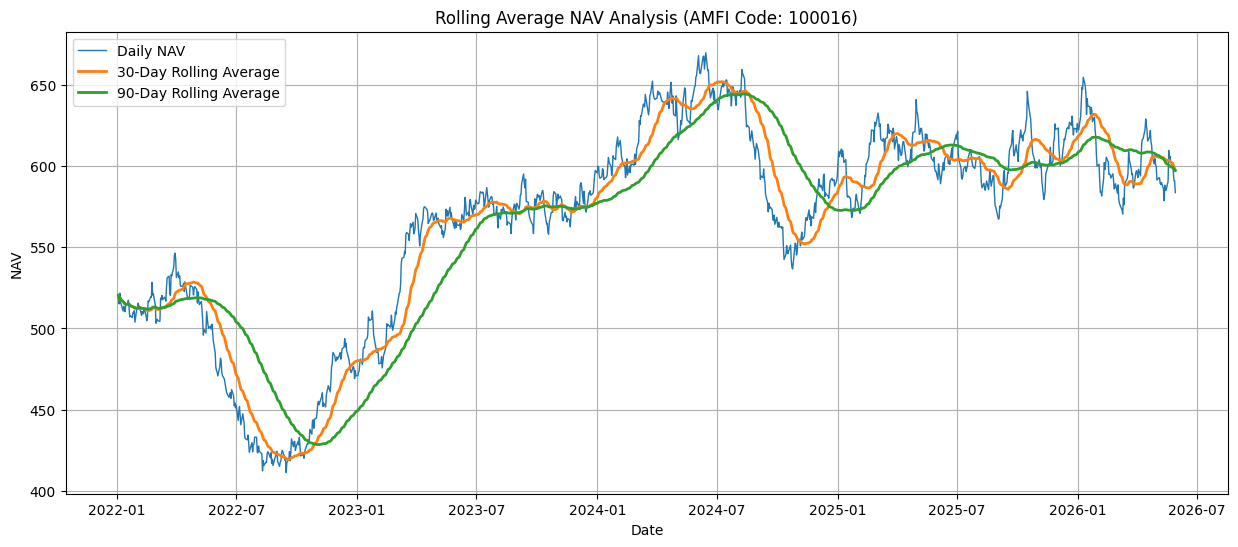

In [42]:
# ---------------------------------------------------------
# Select Sample Scheme
# ---------------------------------------------------------
sample_scheme = nav_df["amfi_code"].iloc[0]

sample_df = nav_df[
    nav_df["amfi_code"] == sample_scheme
]

# ---------------------------------------------------------
# Plot NAV and Rolling Averages
# ---------------------------------------------------------
plt.figure(figsize=(15,6))

plt.plot(
    sample_df["date"],
    sample_df["nav"],
    label="Daily NAV",
    linewidth=1
)

plt.plot(
    sample_df["date"],
    sample_df["rolling_30"],
    label="30-Day Rolling Average",
    linewidth=2
)

plt.plot(
    sample_df["date"],
    sample_df["rolling_90"],
    label="90-Day Rolling Average",
    linewidth=2
)

plt.title(
    f"Rolling Average NAV Analysis (AMFI Code: {sample_scheme})"
)

plt.xlabel("Date")
plt.ylabel("NAV")

plt.legend()

plt.grid(True)

plt.show()

## Section 3: Rolling Average NAV Analysis

### Business Question
How can moving averages help identify long-term trends in a mutual fund's NAV?

### Objective
Calculate 30-day and 90-day rolling averages of NAV to smooth daily fluctuations and reveal underlying performance trends.

### Dataset Used
- nav_history

### Methodology
- Loaded historical NAV data.
- Sorted records by scheme and date.
- Calculated 30-day and 90-day rolling average NAV using Pandas.
- Compared daily NAV with both moving averages through a line chart.

### Outcome
Rolling averages highlighted long-term trends while reducing the effect of short-term market volatility, making performance patterns easier to interpret.

In [43]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Connect to SQLite
# ---------------------------------------------------------
db_path = "database/mutual_fund.db"
conn = sqlite3.connect(db_path)

# ---------------------------------------------------------
# SQL Query
# ---------------------------------------------------------
query = """
WITH fund_dates AS (

    SELECT
        amfi_code,
        MIN(date) AS start_date,
        MAX(date) AS end_date
    FROM nav_history
    GROUP BY amfi_code
)

SELECT

    fd.amfi_code,
    fd.start_date,
    fd.end_date,
    s.nav AS start_nav,
    e.nav AS end_nav

FROM fund_dates fd

JOIN nav_history s
ON fd.amfi_code = s.amfi_code
AND fd.start_date = s.date

JOIN nav_history e
ON fd.amfi_code = e.amfi_code
AND fd.end_date = e.date

ORDER BY fd.amfi_code;
"""

cagr_df = pd.read_sql(query, conn)

# ---------------------------------------------------------
# Convert dates
# ---------------------------------------------------------
cagr_df["start_date"] = pd.to_datetime(cagr_df["start_date"])
cagr_df["end_date"] = pd.to_datetime(cagr_df["end_date"])

# ---------------------------------------------------------
# Calculate investment duration
# ---------------------------------------------------------
cagr_df["years"] = (
    (cagr_df["end_date"] - cagr_df["start_date"]).dt.days
    / 365.25
)

# ---------------------------------------------------------
# Calculate CAGR
# ---------------------------------------------------------
cagr_df["cagr_pct"] = (
    (
        cagr_df["end_nav"] /
        cagr_df["start_nav"]
    ) ** (1 / cagr_df["years"])
    - 1
) * 100

# ---------------------------------------------------------
# Round values
# ---------------------------------------------------------
cagr_df["years"] = cagr_df["years"].round(2)
cagr_df["cagr_pct"] = cagr_df["cagr_pct"].round(2)

# ---------------------------------------------------------
# Display Results
# ---------------------------------------------------------
print("CAGR Analysis")
print("-" * 60)

display(cagr_df)

print("\nTotal Schemes:", len(cagr_df))

CAGR Analysis
------------------------------------------------------------


,amfi_code,start_date,end_date,start_nav,end_nav,years,cagr_pct
0,100016,2022-01-03,2026-05-29,520.4608,583.6113,4.4,2.64
1,100025,2022-01-03,2026-05-29,26.3169,31.8843,4.4,4.46
2,100033,2022-01-03,2026-05-29,107.3758,342.0072,4.4,30.12
3,101206,2022-01-03,2026-05-29,305.0996,773.2939,4.4,23.54
4,101207,2022-01-03,2026-05-29,38.5736,53.9836,4.4,7.94
5,101208,2022-01-03,2026-05-29,310.7415,410.1021,4.4,6.51
6,102885,2022-01-03,2026-05-29,89.8728,187.7797,4.4,18.23
7,102886,2022-01-03,2026-05-29,119.2905,125.5640,4.4,1.17
8,102887,2022-01-03,2026-05-29,191.0721,378.9657,4.4,16.84
9,118632,2022-01-03,2026-05-29,42.8339,110.5554,4.4,24.05



Total Schemes: 40


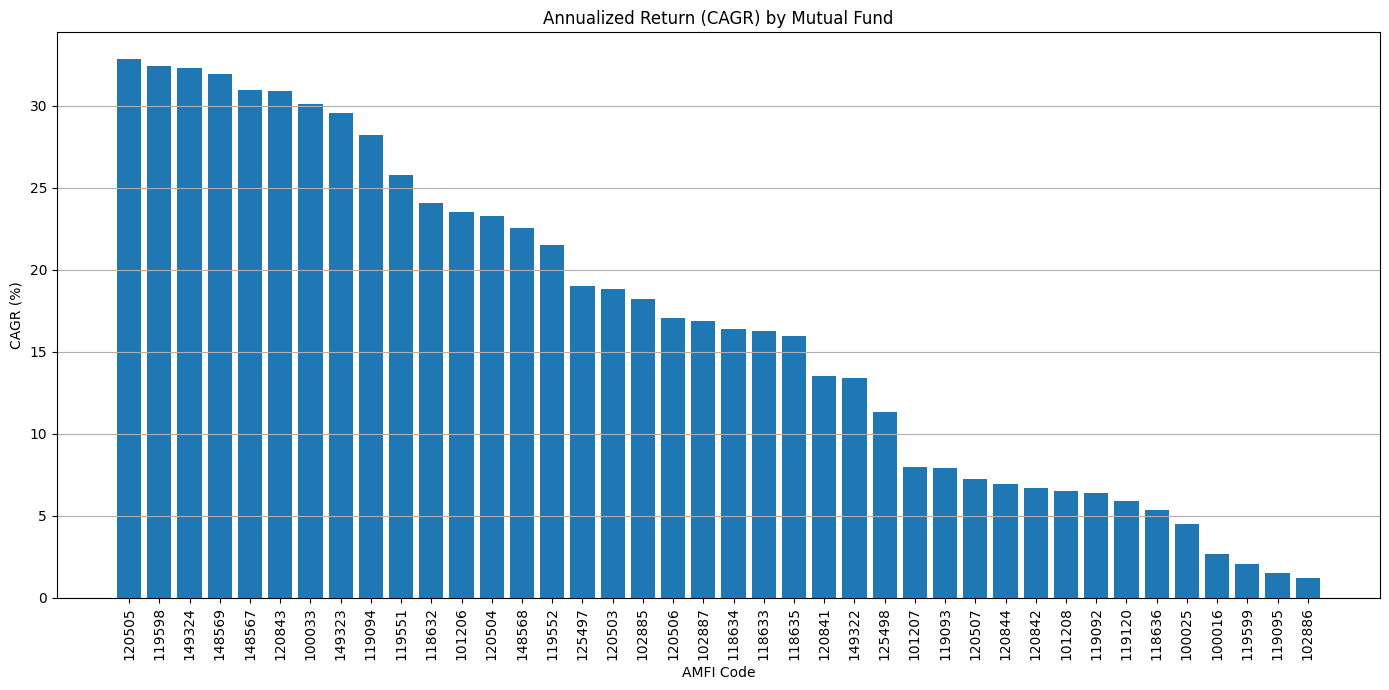

In [44]:
# ---------------------------------------------------------
# Sort by CAGR
# ---------------------------------------------------------
plot_df = cagr_df.sort_values(
    "cagr_pct",
    ascending=False
)

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------
plt.figure(figsize=(14,7))

plt.bar(
    plot_df["amfi_code"].astype(str),
    plot_df["cagr_pct"]
)

plt.title("Annualized Return (CAGR) by Mutual Fund")
plt.xlabel("AMFI Code")
plt.ylabel("CAGR (%)")

plt.xticks(rotation=90)

plt.grid(axis="y")

plt.tight_layout()

plt.show()

## Section 4: Annualized Return (CAGR)

### Business Question
Which mutual fund generated the highest annualized return over the investment period?

### Objective
Calculate the Compound Annual Growth Rate (CAGR) for each mutual fund using its starting NAV, ending NAV, and investment duration.

### Dataset Used
- nav_history

### Methodology
- Retrieved the first and last NAV for each mutual fund.
- Calculated the investment duration in years.
- Applied the CAGR formula.
- Compared annualized returns across all schemes using a bar chart.

### Outcome
CAGR provided a standardized annual growth metric, enabling fair comparison of long-term performance across all mutual fund schemes.

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Calculate Volatility Statistics
# ---------------------------------------------------------
volatility_df = (

    daily_returns_df

    .groupby("amfi_code")

    .agg(
        average_daily_return=("daily_return_pct", "mean"),
        volatility_pct=("daily_return_pct", "std"),
        minimum_return=("daily_return_pct", "min"),
        maximum_return=("daily_return_pct", "max"),
        trading_days=("daily_return_pct", "count")
    )

    .reset_index()

)

# ---------------------------------------------------------
# Round Values
# ---------------------------------------------------------
volatility_df = volatility_df.round({
    "average_daily_return": 4,
    "volatility_pct": 4,
    "minimum_return": 4,
    "maximum_return": 4
})

# ---------------------------------------------------------
# Sort by Volatility
# ---------------------------------------------------------
volatility_df = volatility_df.sort_values(
    "volatility_pct"
)

# ---------------------------------------------------------
# Display Results
# ---------------------------------------------------------
print("Volatility Analysis")
print("-" * 60)

display(volatility_df)

print("\nTotal Schemes:", len(volatility_df))

Volatility Analysis
------------------------------------------------------------


,amfi_code,average_daily_return,volatility_pct,minimum_return,maximum_return,trading_days
27,120507,0.0268,0.0311,-0.0666,0.1197,1149
5,101208,0.0242,0.0319,-0.0766,0.1247,1149
31,120844,0.0256,0.0323,-0.0704,0.1254,1149
1,100025,0.0170,0.2460,-0.8188,0.8837,1149
18,119120,0.0222,0.2499,-0.7690,0.8163,1149
13,118636,0.0202,0.2511,-0.8883,0.7708,1149
6,102885,0.0674,0.8086,-2.1104,2.5565,1149
12,118635,0.0600,0.8179,-2.5466,3.0547,1149
28,120841,0.0522,0.8481,-2.3779,2.8580,1149
19,119551,0.0917,0.8656,-2.7680,3.5096,1149



Total Schemes: 40


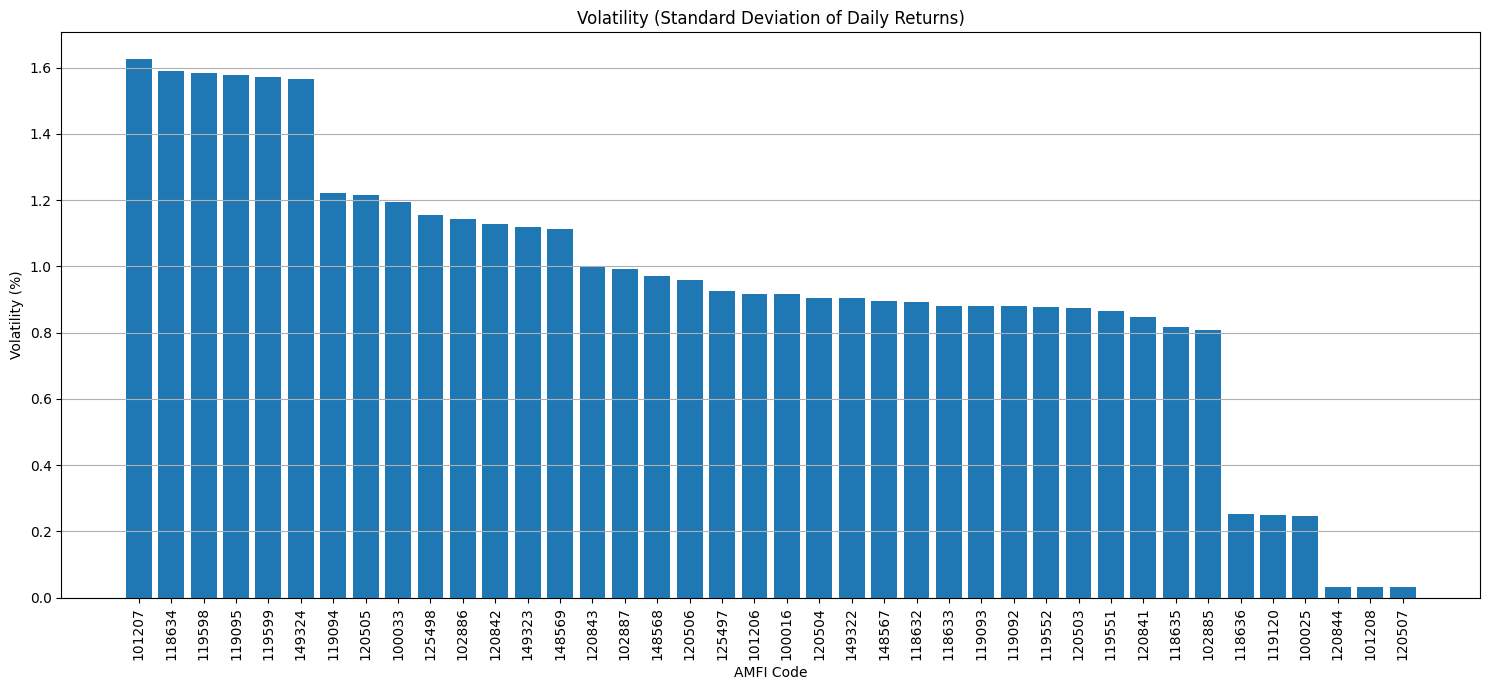

In [46]:
# ---------------------------------------------------------
# Sort for Visualization
# ---------------------------------------------------------
plot_df = volatility_df.sort_values(
    "volatility_pct",
    ascending=False
)

# ---------------------------------------------------------
# Plot Volatility
# ---------------------------------------------------------
plt.figure(figsize=(15,7))

plt.bar(
    plot_df["amfi_code"].astype(str),
    plot_df["volatility_pct"]
)

plt.title("Volatility (Standard Deviation of Daily Returns)")
plt.xlabel("AMFI Code")
plt.ylabel("Volatility (%)")

plt.xticks(rotation=90)

plt.grid(axis="y")

plt.tight_layout()

plt.show()

In [47]:
print("Top 10 Most Volatile Mutual Funds")

display(
    volatility_df
    .sort_values("volatility_pct", ascending=False)
    .head(10)
)

Top 10 Most Volatile Mutual Funds


,amfi_code,average_daily_return,volatility_pct,minimum_return,maximum_return,trading_days
4,101207,0.0424,1.6251,-5.1847,5.4851,1149
11,118634,0.0707,1.5901,-5.8102,5.9304,1149
21,119598,0.1201,1.5837,-4.5180,6.4713,1149
17,119095,0.0182,1.5790,-4.8367,4.3110,1149
22,119599,0.0201,1.5717,-4.5429,5.3320,1149
39,149324,0.1194,1.5648,-4.8870,4.8490,1149
16,119094,0.1027,1.2225,-4.0755,4.1591,1149
25,120505,0.1161,1.2152,-3.8418,4.0812,1149
2,100033,0.1080,1.1929,-4.4238,4.1954,1149
33,125498,0.0477,1.1561,-4.5218,3.6193,1149


In [48]:
print("Top 10 Least Volatile Mutual Funds")

display(
    volatility_df
    .sort_values("volatility_pct")
    .head(10)
)

Top 10 Least Volatile Mutual Funds


,amfi_code,average_daily_return,volatility_pct,minimum_return,maximum_return,trading_days
27,120507,0.0268,0.0311,-0.0666,0.1197,1149
5,101208,0.0242,0.0319,-0.0766,0.1247,1149
31,120844,0.0256,0.0323,-0.0704,0.1254,1149
1,100025,0.0170,0.2460,-0.8188,0.8837,1149
18,119120,0.0222,0.2499,-0.7690,0.8163,1149
13,118636,0.0202,0.2511,-0.8883,0.7708,1149
6,102885,0.0674,0.8086,-2.1104,2.5565,1149
12,118635,0.0600,0.8179,-2.5466,3.0547,1149
28,120841,0.0522,0.8481,-2.3779,2.8580,1149
19,119551,0.0917,0.8656,-2.7680,3.5096,1149


## Section 5: Volatility Analysis (Standard Deviation)

### Business Question
Which mutual funds exhibit the highest and lowest day-to-day fluctuations in returns?

### Objective
Measure the risk of each mutual fund using the standard deviation of daily returns.

### Dataset Used
- daily_returns_df (derived from nav_history)

### Methodology
- Grouped daily returns by mutual fund.
- Calculated average daily return, standard deviation, minimum return, maximum return, and trading days.
- Ranked mutual funds based on volatility.
- Visualized volatility using a bar chart.

### Outcome
The analysis identified the most stable and the most volatile mutual funds, providing a quantitative measure of investment risk to complement return-based performance metrics.

In [49]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Connect to SQLite
# ---------------------------------------------------------
db_path = "database/mutual_fund.db"
conn = sqlite3.connect(db_path)

# ---------------------------------------------------------
# Load NAV History
# ---------------------------------------------------------
query = """
SELECT
    amfi_code,
    date,
    nav
FROM nav_history
ORDER BY
    amfi_code,
    date;
"""

mdd_df = pd.read_sql(query, conn)

# ---------------------------------------------------------
# Convert date column
# ---------------------------------------------------------
mdd_df["date"] = pd.to_datetime(mdd_df["date"])

# ---------------------------------------------------------
# Sort Data
# ---------------------------------------------------------
mdd_df = mdd_df.sort_values(
    ["amfi_code", "date"]
)

# ---------------------------------------------------------
# Running Peak NAV
# ---------------------------------------------------------
mdd_df["running_peak"] = (

    mdd_df

    .groupby("amfi_code")["nav"]

    .cummax()

)

# ---------------------------------------------------------
# Daily Drawdown
# ---------------------------------------------------------
mdd_df["drawdown_pct"] = (

    (
        mdd_df["nav"] -
        mdd_df["running_peak"]
    )

    /

    mdd_df["running_peak"]

) * 100

# ---------------------------------------------------------
# Maximum Drawdown per Scheme
# ---------------------------------------------------------
maximum_drawdown_df = (

    mdd_df

    .groupby("amfi_code")

    .agg(

        maximum_drawdown_pct=("drawdown_pct", "min"),

        peak_nav=("running_peak", "max"),

        latest_nav=("nav", "last")

    )

    .reset_index()

)

maximum_drawdown_df = maximum_drawdown_df.round(2)

# ---------------------------------------------------------
# Display Results
# ---------------------------------------------------------
print("Maximum Drawdown Analysis")
print("-" * 60)

display(maximum_drawdown_df)

print("\nTotal Schemes:", len(maximum_drawdown_df))

Maximum Drawdown Analysis
------------------------------------------------------------


,amfi_code,maximum_drawdown_pct,peak_nav,latest_nav
0,100016,-24.73,669.72,583.61
1,100025,-4.31,32.67,31.88
2,100033,-16.22,367.70,342.01
3,101206,-11.29,808.10,773.29
4,101207,-35.45,80.35,53.98
5,101208,-0.16,410.10,410.10
6,102885,-10.86,187.93,187.78
7,102886,-28.00,169.82,125.56
8,102887,-21.54,419.30,378.97
9,118632,-17.41,114.44,110.56



Total Schemes: 40


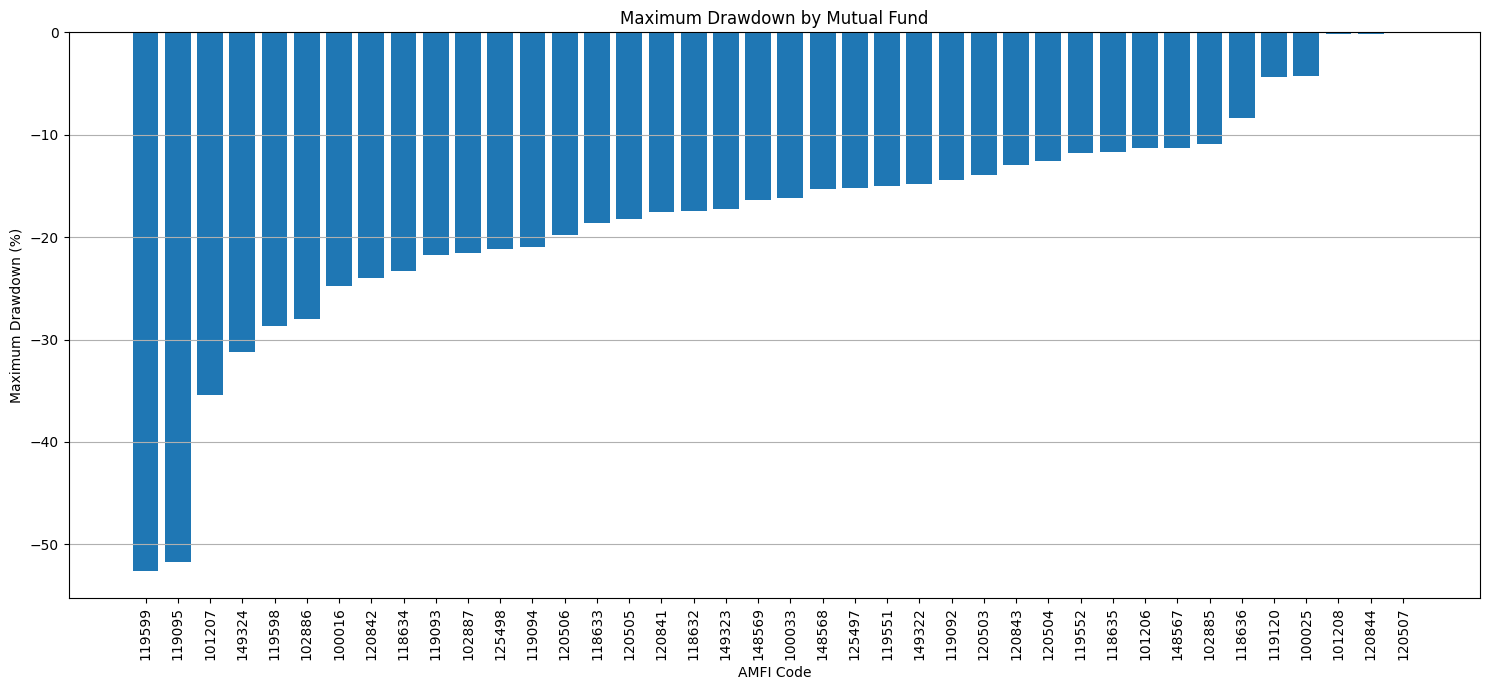

In [50]:
# ---------------------------------------------------------
# Sort by Maximum Drawdown
# ---------------------------------------------------------
plot_df = maximum_drawdown_df.sort_values(
    "maximum_drawdown_pct"
)

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------
plt.figure(figsize=(15,7))

plt.bar(
    plot_df["amfi_code"].astype(str),
    plot_df["maximum_drawdown_pct"]
)

plt.title("Maximum Drawdown by Mutual Fund")

plt.xlabel("AMFI Code")

plt.ylabel("Maximum Drawdown (%)")

plt.xticks(rotation=90)

plt.grid(axis="y")

plt.tight_layout()

plt.show()

## Section 6: Maximum Drawdown Analysis

### Business Question
What was the largest decline experienced by each mutual fund from its historical peak NAV?

### Objective
Measure the maximum downside risk of each mutual fund by calculating the Maximum Drawdown (MDD).

### Dataset Used
- nav_history

### Methodology
- Loaded historical NAV data.
- Calculated the running peak NAV for each scheme using `cummax()`.
- Computed daily drawdown percentages.
- Identified the most negative drawdown as the Maximum Drawdown.
- Ranked mutual funds and visualized their downside risk.

### Outcome
Maximum Drawdown quantified the worst historical decline for each mutual fund, providing a valuable measure of downside risk that complements return and volatility analyses.

In [51]:
import sqlite3
import pandas as pd

# ---------------------------------------------------------
# Connect to SQLite
# ---------------------------------------------------------
db_path = "database/mutual_fund.db"
conn = sqlite3.connect(db_path)

# ---------------------------------------------------------
# Inspect benchmark_indices schema
# ---------------------------------------------------------
pd.read_sql(
    "PRAGMA table_info(benchmark_indices);",
    conn
)

,cid,name,type,notnull,dflt_value,pk
0,0,date,TEXT,0,None,0
1,1,index_name,TEXT,0,None,0
2,2,close_value,REAL,0,None,0


In [52]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Connect to SQLite
# ---------------------------------------------------------
db_path = "database/mutual_fund.db"
conn = sqlite3.connect(db_path)

# ---------------------------------------------------------
# Load NAV History
# ---------------------------------------------------------
nav_query = """
SELECT
    amfi_code,
    date,
    nav
FROM nav_history
ORDER BY
    amfi_code,
    date;
"""

nav_df = pd.read_sql(nav_query, conn)

# ---------------------------------------------------------
# Load Benchmark Data
# ---------------------------------------------------------
benchmark_query = """
SELECT
    date,
    index_name,
    close_value
FROM benchmark_indices
ORDER BY
    index_name,
    date;
"""

benchmark_df = pd.read_sql(benchmark_query, conn)

# ---------------------------------------------------------
# Convert dates
# ---------------------------------------------------------
nav_df["date"] = pd.to_datetime(nav_df["date"])
benchmark_df["date"] = pd.to_datetime(benchmark_df["date"])

# ---------------------------------------------------------
# Select Sample Fund
# ---------------------------------------------------------
sample_scheme = nav_df["amfi_code"].iloc[0]

fund_df = nav_df[
    nav_df["amfi_code"] == sample_scheme
].copy()

# ---------------------------------------------------------
# Select Benchmark
# ---------------------------------------------------------
sample_index = benchmark_df["index_name"].iloc[0]

benchmark_sample = benchmark_df[
    benchmark_df["index_name"] == sample_index
].copy()

# ---------------------------------------------------------
# Calculate Fund Cumulative Return
# ---------------------------------------------------------
fund_df["fund_return"] = (
    fund_df["nav"] /
    fund_df["nav"].iloc[0]
    - 1
) * 100

# ---------------------------------------------------------
# Calculate Benchmark Cumulative Return
# ---------------------------------------------------------
benchmark_sample["benchmark_return"] = (
    benchmark_sample["close_value"] /
    benchmark_sample["close_value"].iloc[0]
    - 1
) * 100

# ---------------------------------------------------------
# Merge
# ---------------------------------------------------------
comparison_df = pd.merge(
    fund_df[
        ["date", "fund_return"]
    ],
    benchmark_sample[
        ["date", "benchmark_return"]
    ],
    on="date",
    how="inner"
)

print("Comparison Dataset")

display(comparison_df.head())

print("\nShape:", comparison_df.shape)

Comparison Dataset


,date,fund_return,benchmark_return
0,2022-01-03,0.000000,0.000000
1,2022-01-04,-1.030568,1.978264
2,2022-01-05,0.242689,2.857320
3,2022-01-06,-0.897820,3.097203
4,2022-01-07,-1.017733,-0.895287



Shape: (1150, 3)


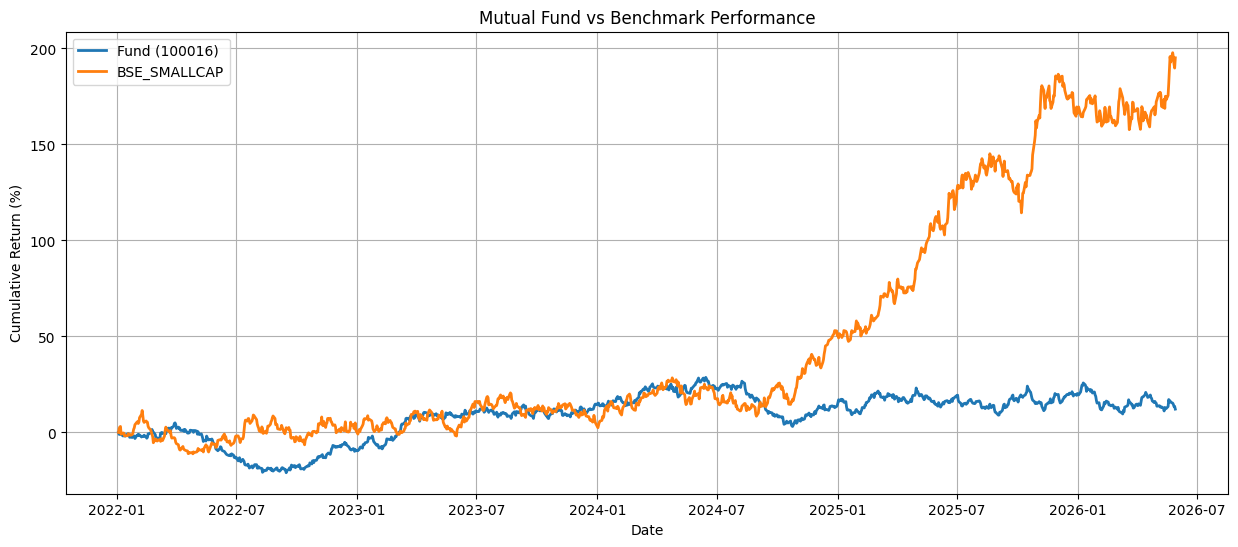

In [53]:
plt.figure(figsize=(15,6))

plt.plot(
    comparison_df["date"],
    comparison_df["fund_return"],
    label=f"Fund ({sample_scheme})",
    linewidth=2
)

plt.plot(
    comparison_df["date"],
    comparison_df["benchmark_return"],
    label=sample_index,
    linewidth=2
)

plt.title("Mutual Fund vs Benchmark Performance")

plt.xlabel("Date")

plt.ylabel("Cumulative Return (%)")

plt.legend()

plt.grid(True)

plt.show()

In [54]:
fund_final = comparison_df["fund_return"].iloc[-1]
benchmark_final = comparison_df["benchmark_return"].iloc[-1]

print(f"Fund Final Return       : {fund_final:.2f}%")
print(f"Benchmark Final Return  : {benchmark_final:.2f}%")

difference = fund_final - benchmark_final

print(f"Outperformance          : {difference:.2f}%")

if difference > 0:
    print("\nThe mutual fund outperformed the benchmark.")
elif difference < 0:
    print("\nThe mutual fund underperformed the benchmark.")
else:
    print("\nThe mutual fund matched the benchmark.")

Fund Final Return       : 12.13%
Benchmark Final Return  : 195.12%
Outperformance          : -182.99%

The mutual fund underperformed the benchmark.


## Section 7: Benchmark Comparison

### Business Question
Did the mutual fund outperform or underperform its benchmark index over the analysis period?

### Objective
Compare the cumulative returns of a mutual fund with a benchmark index to evaluate relative performance.

### Datasets Used
- nav_history
- benchmark_indices

### Methodology
- Loaded mutual fund NAV data and benchmark index data.
- Calculated cumulative returns for both datasets.
- Merged them using the trading date.
- Visualized cumulative performance on a single chart.
- Calculated the final outperformance or underperformance.

### Outcome
The comparison highlighted whether the selected mutual fund generated higher returns than the benchmark, providing a measure of active management effectiveness.

In [55]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Merge CAGR and Volatility Data
# ---------------------------------------------------------
risk_return_df = pd.merge(
    cagr_df[
        ["amfi_code", "cagr_pct"]
    ],
    volatility_df[
        ["amfi_code", "volatility_pct"]
    ],
    on="amfi_code"
)

# ---------------------------------------------------------
# Display Data
# ---------------------------------------------------------
print("Risk vs Return Dataset")
print("-" * 60)

display(risk_return_df)

print("\nTotal Schemes:", len(risk_return_df))

Risk vs Return Dataset
------------------------------------------------------------


,amfi_code,cagr_pct,volatility_pct
0,100016,2.64,0.9164
1,100025,4.46,0.2460
2,100033,30.12,1.1929
3,101206,23.54,0.9177
4,101207,7.94,1.6251
5,101208,6.51,0.0319
6,102885,18.23,0.8086
7,102886,1.17,1.1424
8,102887,16.84,0.9927
9,118632,24.05,0.8913



Total Schemes: 40


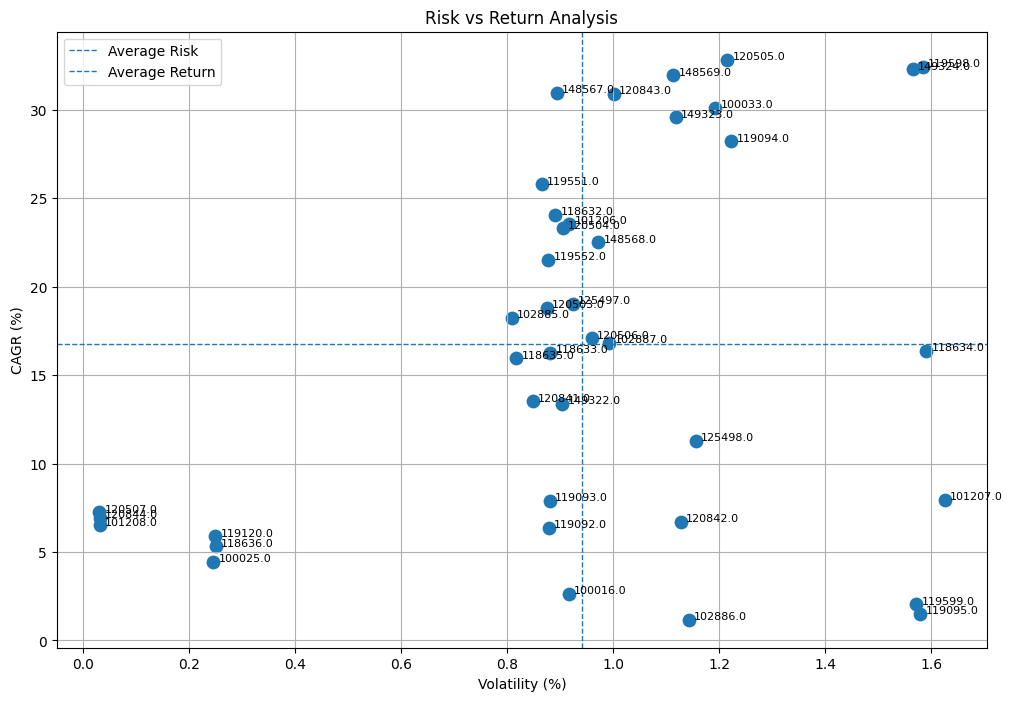

In [56]:
plt.figure(figsize=(12,8))

plt.scatter(
    risk_return_df["volatility_pct"],
    risk_return_df["cagr_pct"],
    s=80
)

# ---------------------------------------------------------
# Label Each Fund
# ---------------------------------------------------------
for _, row in risk_return_df.iterrows():
    plt.text(
        row["volatility_pct"] + 0.01,
        row["cagr_pct"] + 0.01,
        str(row["amfi_code"]),
        fontsize=8
    )

# ---------------------------------------------------------
# Average Risk & Return
# ---------------------------------------------------------
avg_risk = risk_return_df["volatility_pct"].mean()
avg_return = risk_return_df["cagr_pct"].mean()

plt.axvline(
    avg_risk,
    linestyle="--",
    linewidth=1,
    label="Average Risk"
)

plt.axhline(
    avg_return,
    linestyle="--",
    linewidth=1,
    label="Average Return"
)

plt.title("Risk vs Return Analysis")

plt.xlabel("Volatility (%)")

plt.ylabel("CAGR (%)")

plt.grid(True)

plt.legend()

plt.show()

## Section 8: Risk vs Return Scatter Plot

### Business Question
Which mutual funds provide the best balance between risk and return?

### Objective
Visualize the relationship between annualized return (CAGR) and volatility for each mutual fund.

### Datasets Used
- cagr_df
- volatility_df

### Methodology
- Merged CAGR and volatility data using AMFI Code.
- Created a scatter plot with volatility on the X-axis and CAGR on the Y-axis.
- Added labels for each mutual fund.
- Drew average risk and return reference lines to divide the plot into four quadrants.

### Outcome
The scatter plot identified funds with favorable risk-return characteristics and highlighted schemes that delivered strong returns without excessive volatility.

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Calculate Performance Consistency
# ---------------------------------------------------------
consistency_df = (

    daily_returns_df

    .groupby("amfi_code")

    .agg(

        trading_days=("daily_return_pct", "count"),

        positive_days=("daily_return_pct",
                       lambda x: (x > 0).sum()),

        negative_days=("daily_return_pct",
                       lambda x: (x < 0).sum()),

        zero_return_days=("daily_return_pct",
                          lambda x: (x == 0).sum())

    )

    .reset_index()

)

# ---------------------------------------------------------
# Consistency Percentage
# ---------------------------------------------------------
consistency_df["consistency_pct"] = (

    consistency_df["positive_days"]

    /

    consistency_df["trading_days"]

) * 100

# ---------------------------------------------------------
# Round
# ---------------------------------------------------------
consistency_df["consistency_pct"] = (
    consistency_df["consistency_pct"].round(2)
)

# ---------------------------------------------------------
# Sort
# ---------------------------------------------------------
consistency_df = consistency_df.sort_values(
    "consistency_pct",
    ascending=False
)

# ---------------------------------------------------------
# Display
# ---------------------------------------------------------
print("Performance Consistency Analysis")
print("-" * 60)

display(consistency_df)

print("\nTotal Schemes:", len(consistency_df))

Performance Consistency Analysis
------------------------------------------------------------


,amfi_code,trading_days,positive_days,negative_days,zero_return_days,consistency_pct
27,120507,1149,924,225,0,80.42
5,101208,1149,887,260,2,77.20
31,120844,1149,886,261,2,77.11
34,148567,1149,643,506,0,55.96
24,120504,1149,632,517,0,55.00
19,119551,1149,631,518,0,54.92
38,149323,1149,623,526,0,54.22
9,118632,1149,617,532,0,53.70
30,120843,1149,615,534,0,53.52
18,119120,1149,612,537,0,53.26



Total Schemes: 40


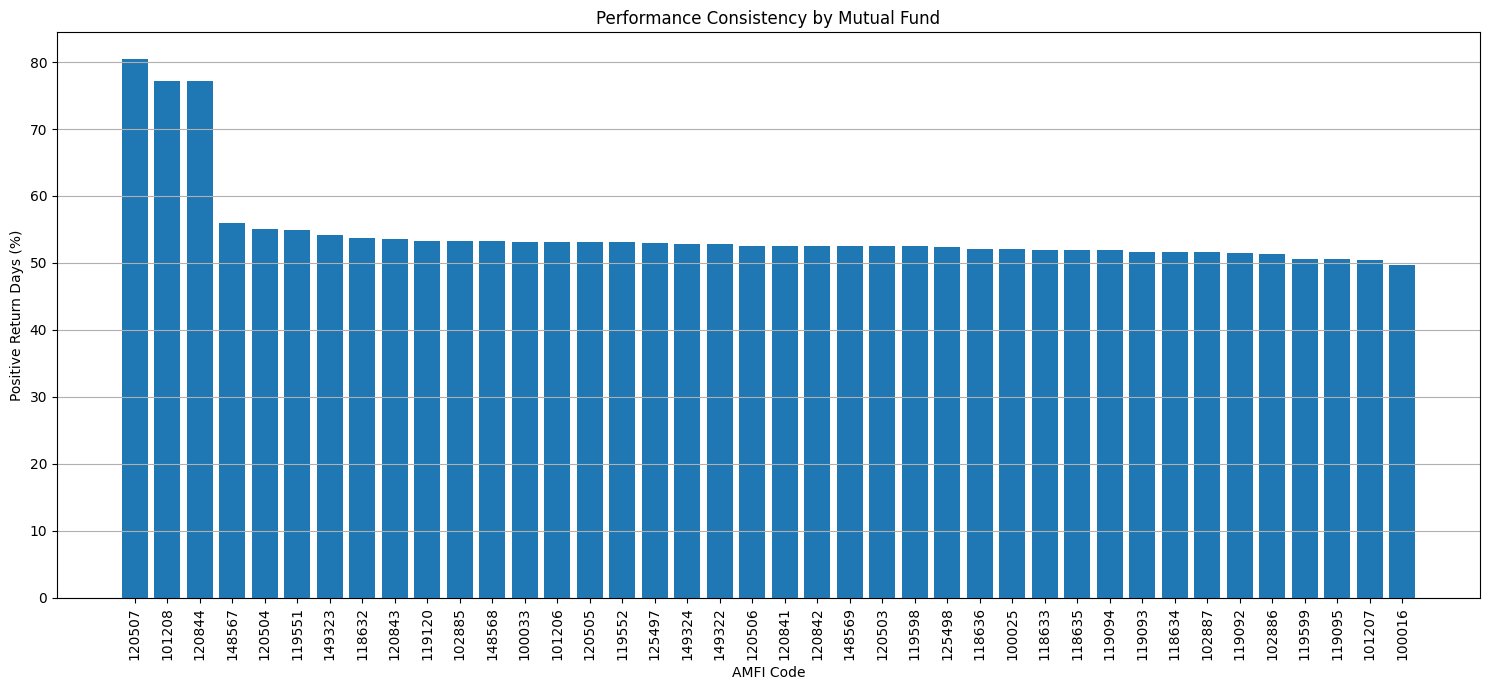

In [58]:
# ---------------------------------------------------------
# Sort for Plot
# ---------------------------------------------------------
plot_df = consistency_df.sort_values(
    "consistency_pct",
    ascending=False
)

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------
plt.figure(figsize=(15,7))

plt.bar(
    plot_df["amfi_code"].astype(str),
    plot_df["consistency_pct"]
)

plt.title("Performance Consistency by Mutual Fund")

plt.xlabel("AMFI Code")

plt.ylabel("Positive Return Days (%)")

plt.xticks(rotation=90)

plt.grid(axis="y")

plt.tight_layout()

plt.show()

## Section 9: Performance Consistency Analysis

### Business Question
Which mutual funds generated positive returns most consistently over the analysis period?

### Objective
Measure the consistency of each mutual fund by calculating the percentage of trading days with positive daily returns.

### Dataset Used
- daily_returns_df (derived from nav_history)

### Methodology
- Grouped daily returns by AMFI Code.
- Counted total, positive, negative, and zero-return trading days.
- Calculated the consistency score as the percentage of positive trading days.
- Ranked mutual funds and visualized the results.

### Outcome
The analysis identified the most consistent mutual funds, highlighting schemes that delivered positive returns more frequently and providing another perspective on investment quality beyond absolute returns.

In [59]:
import pandas as pd

# ---------------------------------------------------------
# Merge All Performance Metrics
# ---------------------------------------------------------
dashboard_df = (

    cagr_df[
        ["amfi_code", "cagr_pct"]
    ]

    .merge(

        volatility_df[
            ["amfi_code", "volatility_pct"]
        ],

        on="amfi_code"

    )

    .merge(

        maximum_drawdown_df[
            ["amfi_code", "maximum_drawdown_pct"]
        ],

        on="amfi_code"

    )

    .merge(

        consistency_df[
            ["amfi_code", "consistency_pct"]
        ],

        on="amfi_code"

    )

)

# ---------------------------------------------------------
# Round
# ---------------------------------------------------------
dashboard_df = dashboard_df.round(2)

# ---------------------------------------------------------
# Rank by CAGR
# ---------------------------------------------------------
dashboard_df = dashboard_df.sort_values(
    "cagr_pct",
    ascending=False
)

# ---------------------------------------------------------
# Display
# ---------------------------------------------------------
print("Financial Performance Dashboard")
print("-" * 70)

display(dashboard_df)

print("\nTotal Schemes:", len(dashboard_df))

Financial Performance Dashboard
----------------------------------------------------------------------


,amfi_code,cagr_pct,volatility_pct,maximum_drawdown_pct,consistency_pct
25,120505,32.83,1.22,-18.19,53.09
21,119598,32.42,1.58,-28.71,52.48
39,149324,32.29,1.56,-31.17,52.83
36,148569,31.95,1.11,-16.40,52.57
34,148567,30.97,0.89,-11.27,55.96
30,120843,30.91,1.00,-12.97,53.52
2,100033,30.12,1.19,-16.22,53.18
38,149323,29.58,1.12,-17.25,54.22
16,119094,28.21,1.22,-20.96,51.87
19,119551,25.80,0.87,-15.01,54.92



Total Schemes: 40


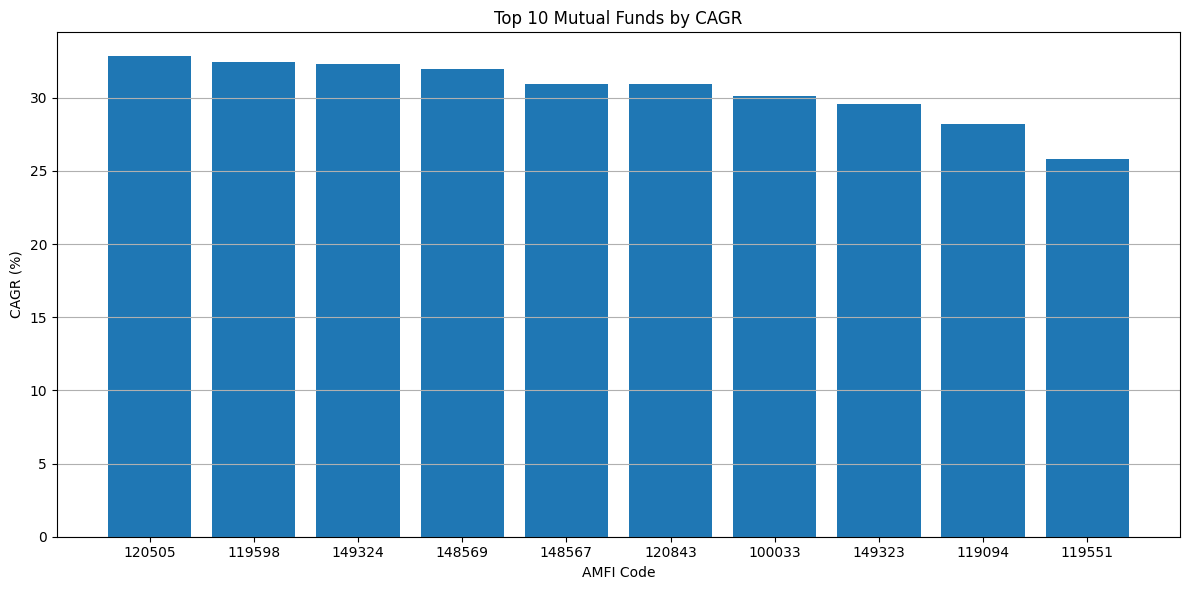

In [60]:
import matplotlib.pyplot as plt

top10 = dashboard_df.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10["amfi_code"].astype(str),
    top10["cagr_pct"]
)

plt.title("Top 10 Mutual Funds by CAGR")

plt.xlabel("AMFI Code")

plt.ylabel("CAGR (%)")

plt.grid(axis="y")

plt.tight_layout()

plt.show()

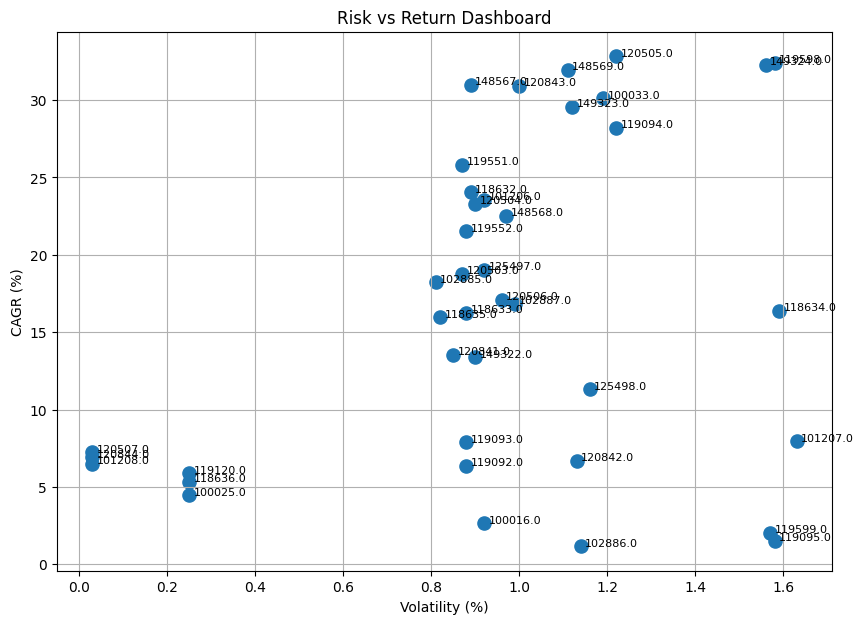

In [61]:
plt.figure(figsize=(10,7))

plt.scatter(
    dashboard_df["volatility_pct"],
    dashboard_df["cagr_pct"],
    s=90
)

for _, row in dashboard_df.iterrows():

    plt.text(
        row["volatility_pct"] + 0.01,
        row["cagr_pct"] + 0.01,
        str(row["amfi_code"]),
        fontsize=8
    )

plt.title("Risk vs Return Dashboard")

plt.xlabel("Volatility (%)")

plt.ylabel("CAGR (%)")

plt.grid(True)

plt.show()

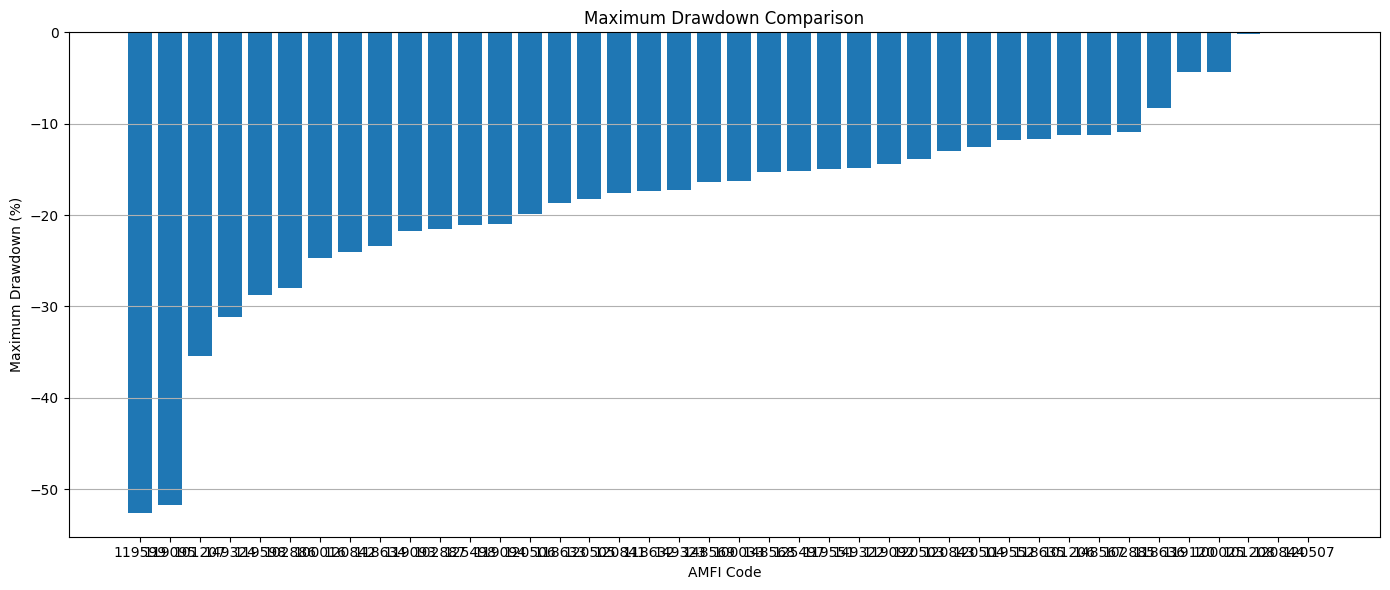

In [62]:
plot_df = dashboard_df.sort_values(
    "maximum_drawdown_pct"
)

plt.figure(figsize=(14,6))

plt.bar(
    plot_df["amfi_code"].astype(str),
    plot_df["maximum_drawdown_pct"]
)

plt.title("Maximum Drawdown Comparison")

plt.xlabel("AMFI Code")

plt.ylabel("Maximum Drawdown (%)")

plt.grid(axis="y")

plt.tight_layout()

plt.show()

In [63]:
# ---------------------------------------------------------
# Normalize Metrics
# ---------------------------------------------------------
dashboard_df["return_score"] = (
    dashboard_df["cagr_pct"] /
    dashboard_df["cagr_pct"].max()
)

dashboard_df["risk_score"] = 1 - (
    dashboard_df["volatility_pct"] /
    dashboard_df["volatility_pct"].max()
)

dashboard_df["drawdown_score"] = 1 - (
    dashboard_df["maximum_drawdown_pct"].abs() /
    dashboard_df["maximum_drawdown_pct"].abs().max()
)

dashboard_df["consistency_score"] = (
    dashboard_df["consistency_pct"] /
    dashboard_df["consistency_pct"].max()
)

# ---------------------------------------------------------
# Overall Performance Score
# ---------------------------------------------------------
dashboard_df["overall_score"] = (

    0.40 * dashboard_df["return_score"]

    +

    0.20 * dashboard_df["risk_score"]

    +

    0.20 * dashboard_df["drawdown_score"]

    +

    0.20 * dashboard_df["consistency_score"]

)

dashboard_df = dashboard_df.sort_values(
    "overall_score",
    ascending=False
)

print("Top 10 Overall Mutual Funds")

display(
    dashboard_df[
        [
            "amfi_code",
            "overall_score",
            "cagr_pct",
            "volatility_pct",
            "maximum_drawdown_pct",
            "consistency_pct"
        ]
    ].head(10)
)

Top 10 Overall Mutual Funds


,amfi_code,overall_score,cagr_pct,volatility_pct,maximum_drawdown_pct,consistency_pct
34,148567,0.764429,30.97,0.89,-11.27,55.96
30,120843,0.737665,30.91,1.00,-12.97,53.52
36,148569,0.721427,31.95,1.11,-16.40,52.57
25,120505,0.713136,32.83,1.22,-18.19,53.09
38,149323,0.692194,29.58,1.12,-17.25,54.22
2,100033,0.691517,30.12,1.19,-16.22,53.18
19,119551,0.687076,25.80,0.87,-15.01,54.92
27,120507,0.684151,7.24,0.03,-0.10,80.42
31,120844,0.671944,6.92,0.03,-0.12,77.11
5,101208,0.667020,6.51,0.03,-0.16,77.20


## Section 10: Final Financial Performance Dashboard Summary

### Business Question
How can multiple financial performance metrics be consolidated into a single dashboard for comprehensive mutual fund evaluation?

### Objective
Create a unified dashboard that combines return, risk, downside risk, and consistency metrics for each mutual fund.

### Datasets Used
- cagr_df
- volatility_df
- maximum_drawdown_df
- consistency_df

### Methodology
- Merged all financial metrics using AMFI Code.
- Ranked funds by CAGR.
- Visualized the top-performing funds, risk-return relationship, and maximum drawdown.
- Created an optional composite performance score using normalized metrics and weighted averaging.

### Outcome
The final dashboard provided a comprehensive summary of mutual fund performance, enabling investors to compare schemes across multiple financial dimensions rather than relying on a single metric.